# Univariate Exploration der abhängigen Variable `price`

Ziel: Erste Untersuchung des Listing-Preises als Zielvariable für ein Preisvorhersagemodell.

In diesem Notebook werden drei mögliche Verteilungsannahmen visuell und anhand empirischer Momente geprüft:

1. nicht transformierter Preis mit Normalverteilung,
2. logarithmierter Preis mit Normalverteilung,
3. nicht transformierter Preis mit Gammaverteilung.

Die Verteilungsparameter werden jeweils aus den Daten geschätzt, also über empirische Momente beziehungsweise Maximum-Likelihood-Schätzung.

## 1. Imports

In [101]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
import torch

### 1.1 Rechenger?t: GPU verwenden, wenn verf?gbar

Wie in den vorherigen Practicals wird CUDA automatisch aktiviert, sofern PyTorch eine kompatible NVIDIA-GPU erkennt. Das eigene Group-wise Component Boosting verwendet dann `cuda:0`.

Alle CatBoost-Varianten in diesem Notebook werden ausschlie?lich auf der GPU trainiert. Dazu geh?ren das strukturierte Basismodell sowie die beiden erweiterten Textmodelle. Die konkreten scikit-learn-Implementierungen `LinearRegression`, `HistGradientBoostingRegressor`, `TfidfVectorizer` und `TruncatedSVD` besitzen hier kein CUDA-Backend und laufen auf der CPU; das anschlie?ende CatBoost-Training l?uft auf der GPU.

CatBoost weist darauf hin, dass GPU-Training wegen nichtdeterministischer Gleitkomma-Summationen trotz gleichem Seed geringf?gig unterschiedliche Ergebnisse liefern kann: [CatBoost ? Training on GPU](https://catboost.ai/docs/en/features/training-on-gpu).

In [102]:
# GPU-Konvention analog zu den vorherigen Practicals.
use_cuda = torch.cuda.is_available()
device = torch.device("cuda:0" if use_cuda else "cpu")

if use_cuda:
    torch.set_float32_matmul_precision("high")
    device_name = torch.cuda.get_device_name(device)
else:
    device_name = "CPU"

print(f"Verwendetes Rechenger?t: {device} ({device_name})")
pd.DataFrame({
    "Modell": [
        "Lineare Regression (scikit-learn)",
        "Group-wise Component Boosting (eigene Implementierung)",
        "Histogram Gradient Boosting (scikit-learn)",
        "CatBoost ? strukturierte Features",
        "CatBoost ? native Textfeatures",
        "CatBoost ? TF-IDF/SVD",
    ],
    "Training auf": [
        "CPU ? Implementierung ohne CUDA-Backend",
        "GPU" if use_cuda else "CPU-Fallback",
        "CPU ? Implementierung ohne CUDA-Backend",
        "GPU",
        "GPU",
        "GPU (TF-IDF/SVD-Vorverarbeitung auf CPU)",
    ],
})

Verwendetes Rechenger?t: cuda:0 (NVIDIA GeForce RTX 3050 Ti Laptop GPU)


,Modell,Training auf
0,Lineare Regression (scikit-learn),CPU ? Implementierung ohne CUDA-Backend
1,Group-wise Component Boosting (eigene Implemen...,GPU
2,Histogram Gradient Boosting (scikit-learn),CPU ? Implementierung ohne CUDA-Backend
3,CatBoost ? strukturierte Features,GPU
4,CatBoost ? native Textfeatures,GPU
5,CatBoost ? TF-IDF/SVD,GPU (TF-IDF/SVD-Vorverarbeitung auf CPU)


## 2. Datenimport

Für die Preisvorhersage ist `listings.csv.gz` der wichtigste Datensatz, weil dort pro Listing ein `price`-Wert enthalten ist. Die Kalenderdatei enthält in diesem Projekt keine nutzbaren Tagespreise.

In [103]:
DATA_DIR = Path("data")
LISTINGS_PATH = DATA_DIR / "listings.csv.gz"

listings = pd.read_csv(LISTINGS_PATH, low_memory=False)

print(f"Datensatz: {LISTINGS_PATH}")
print(f"Zeilen: {listings.shape[0]:,}")
print(f"Spalten: {listings.shape[1]:,}")
listings.head()

Datensatz: data\listings.csv.gz
Zeilen: 27,945
Spalten: 79


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,197677,https://www.airbnb.com/rooms/197677,20250929042135,2025-09-30,city scrape,Oshiage Holiday Apartment,NaN,NaN,https://a0.muscache.com/pictures/38437056/d27f...,964081,...,4.84,4.58,4.80,M130003350,f,1,1,0,0,1.11
1,776070,https://www.airbnb.com/rooms/776070,20250929042135,2025-09-29,city scrape,Kero-kero room 1F,We have been in airbnb since 2011 and it has g...,We love Nishinippori because is nearer to Toky...,https://a0.muscache.com/pictures/efd9f039-dbd2...,801494,...,4.98,4.85,4.92,M130000243,f,1,0,1,0,1.74
2,905944,https://www.airbnb.com/rooms/905944,20250929042135,2025-09-29,city scrape,4F Spacious Apartment in Shinjuku / Shibuya Tokyo,NEWLY RENOVATED property entirely for you & yo...,Hatagaya is a great neighborhood located 4 min...,https://a0.muscache.com/pictures/hosting/Hosti...,4847803,...,4.93,4.81,4.81,Hotels and Inns Business Act | 渋谷区保健所長 | 31渋健生...,t,9,9,0,0,1.85
3,1016831,https://www.airbnb.com/rooms/1016831,20250929042135,2025-09-29,city scrape,5 mins Shibuya Cat modern sunny Shimokita,"Hi there, I am Wakana and I live with my two f...",The location is walkable distance to famous Sh...,https://a0.muscache.com/pictures/airflow/Hosti...,5596383,...,4.98,4.93,4.89,M130001107,f,1,0,1,0,1.87
4,1196177,https://www.airbnb.com/rooms/1196177,20250929042135,2025-09-29,city scrape,Homestay at Host's House - Senju-Ohashi Station,Our accommodation offers: <br /><br />1. **Gr...,There are shopping mall near Senjuohashi stati...,https://a0.muscache.com/pictures/72890882/05ec...,5686404,...,4.91,4.75,4.83,M130007760,f,1,0,1,0,1.01


## 3. Zielvariable `price` vorbereiten

`price` ist im Rohdatensatz als String mit Währungssymbol und Tausendertrennzeichen gespeichert, z.B. `$12,600.00`. Für die Analyse wird daraus eine numerische Variable `price_numeric` erzeugt.

Wichtig: Für Verteilungsannahmen wie Log-Normal oder Gamma brauchen wir positive Preise. Fehlende und nicht-positive Werte werden deshalb für die univariate Verteilungsanalyse ausgeschlossen.

In [104]:
def parse_price(series: pd.Series) -> pd.Series:
    """Convert price strings such as '$12,600.00' to numeric values."""
    return pd.to_numeric(
        series.astype(str)
        .str.replace("$", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.strip(),
        errors="coerce",
    )

listings["price_numeric"] = parse_price(listings["price"])

price_raw = listings["price_numeric"]
price = price_raw.dropna()
price_positive = price[price > 0].copy()
log_price = np.log(price_positive)

price_overview = pd.DataFrame(
    {
        "Kennzahl": [
            "Listings insgesamt",
            "Preis nicht fehlend",
            "Preis fehlend",
            "Preis <= 0",
            "Preis > 0 für Analyse",
        ],
        "Wert": [
            len(price_raw),
            price_raw.notna().sum(),
            price_raw.isna().sum(),
            (price <= 0).sum(),
            len(price_positive),
        ],
    }
)

price_overview

,Kennzahl,Wert
0,Listings insgesamt,27945
1,Preis nicht fehlend,25480
2,Preis fehlend,2465
3,Preis <= 0,0
4,Preis > 0 für Analyse,25480


## 4. Empirische Momente und Quantile

Die folgenden Kennzahlen beschreiben die empirische Preisverteilung. Besonders wichtig sind Schiefe, Kurtosis und hohe Quantile, weil Airbnb-Preise typischerweise stark rechtsschief sind.

In [105]:
def empirical_summary(x: pd.Series, name: str) -> pd.DataFrame:
    x = pd.Series(x).dropna()
    summary = {
        "Variable": name,
        "n": len(x),
        "Mean": x.mean(),
        "Std": x.std(ddof=1),
        "Variance": x.var(ddof=1),
        "Skewness": x.skew(),
        "Kurtosis_excess": x.kurtosis(),
        "Min": x.min(),
        "P01": x.quantile(0.01),
        "P05": x.quantile(0.05),
        "P25": x.quantile(0.25),
        "Median": x.median(),
        "P75": x.quantile(0.75),
        "P95": x.quantile(0.95),
        "P99": x.quantile(0.99),
        "Max": x.max(),
    }
    return pd.DataFrame([summary])

summary_price = empirical_summary(price_positive, "price")
summary_log_price = empirical_summary(log_price, "log(price)")

summary = pd.concat([summary_price, summary_log_price], ignore_index=True)
summary.T

,0,1
Variable,price,log(price)
n,25480,25480
Mean,24781.880926,9.765066
Std,77865.751231,0.67607
Variance,6063075214.838523,0.457071
Skewness,85.069151,1.095535
Kurtosis_excess,10597.137507,4.1968
Min,1500.0,7.31322
P01,4256.95,8.356308
P05,7029.85,8.857921


## 5. Erste Rohverteilung des Preises

Zuerst betrachten wir den Preis direkt. Der linke Plot zeigt alle positiven Preise. Der rechte Plot begrenzt die x-Achse auf das 99%-Quantil, damit der Hauptbereich der Verteilung lesbar bleibt.

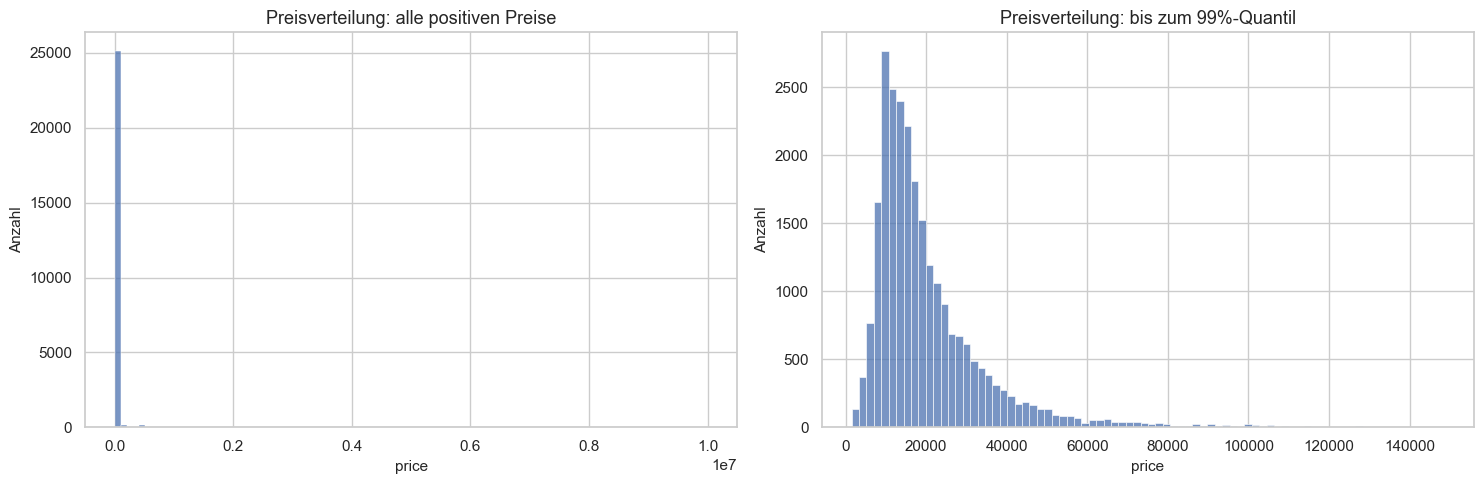

99%-Quantil: 148,912.96


In [106]:
p99 = price_positive.quantile(0.99)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(price_positive, bins=100, kde=False, ax=axes[0])
axes[0].set_title("Preisverteilung: alle positiven Preise")
axes[0].set_xlabel("price")
axes[0].set_ylabel("Anzahl")

sns.histplot(price_positive[price_positive <= p99], bins=80, kde=False, ax=axes[1])
axes[1].set_title("Preisverteilung: bis zum 99%-Quantil")
axes[1].set_xlabel("price")
axes[1].set_ylabel("Anzahl")

plt.tight_layout()
plt.show()

print(f"99%-Quantil: {p99:,.2f}")

## 6. Hilfsfunktionen für theoretische Verteilungen

Für jede Annahme werden zwei Dinge geplottet:

- Histogramm der empirischen Daten mit theoretischer Dichte,
- Q-Q-Scatterplot: empirische Quantile gegen theoretische Quantile.

Wenn die Verteilungsannahme gut passt, sollten die Punkte im Q-Q-Plot ungefähr auf der 45-Grad-Linie liegen.

In [107]:
def plot_hist_with_pdf(x, pdf_func, x_grid, title, xlabel, bins=80, xlim=None):
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.histplot(x, bins=bins, stat="density", color="steelblue", alpha=0.35, ax=ax)
    ax.plot(x_grid, pdf_func(x_grid), color="darkred", linewidth=2.5, label="theoretische Dichte")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Dichte")
    if xlim is not None:
        ax.set_xlim(xlim)
    ax.legend()
    plt.tight_layout()
    plt.show()


def qq_scatter(x, ppf_func, title, xlabel="Theoretische Quantile", ylabel="Empirische Quantile"):
    x = np.sort(np.asarray(pd.Series(x).dropna()))
    n = len(x)
    probs = (np.arange(1, n + 1) - 0.5) / n
    theoretical = ppf_func(probs)
    empirical = x

    finite_mask = np.isfinite(theoretical) & np.isfinite(empirical)
    theoretical = theoretical[finite_mask]
    empirical = empirical[finite_mask]

    low = min(theoretical.min(), empirical.min())
    high = max(theoretical.max(), empirical.max())

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(theoretical, empirical, s=10, alpha=0.35)
    ax.plot([low, high], [low, high], color="darkred", linewidth=2, label="45-Grad-Linie")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend()
    plt.tight_layout()
    plt.show()

## 7. Annahme A: Nicht transformierter Preis mit Normalverteilung

Annahme:

$$price \sim \mathcal{N}(\mu, \sigma^2)$$

Die Parameter werden aus den empirischen Momenten geschätzt:

$$\hat{\mu} = \bar{x}, \quad \hat{\sigma} = s$$

Diese Annahme ist bei Preisen oft problematisch, weil die Normalverteilung symmetrisch ist und auch negative Werte zulässt.

In [108]:
mu_price = price_positive.mean()
sd_price = price_positive.std(ddof=1)

normal_price_params = pd.DataFrame(
    {
        "Verteilung": ["Normal auf price"],
        "mu": [mu_price],
        "sigma": [sd_price],
        "Varianz": [sd_price**2],
    }
)
normal_price_params

,Verteilung,mu,sigma,Varianz
0,Normal auf price,24781.880926,77865.751231,6.063075e+09


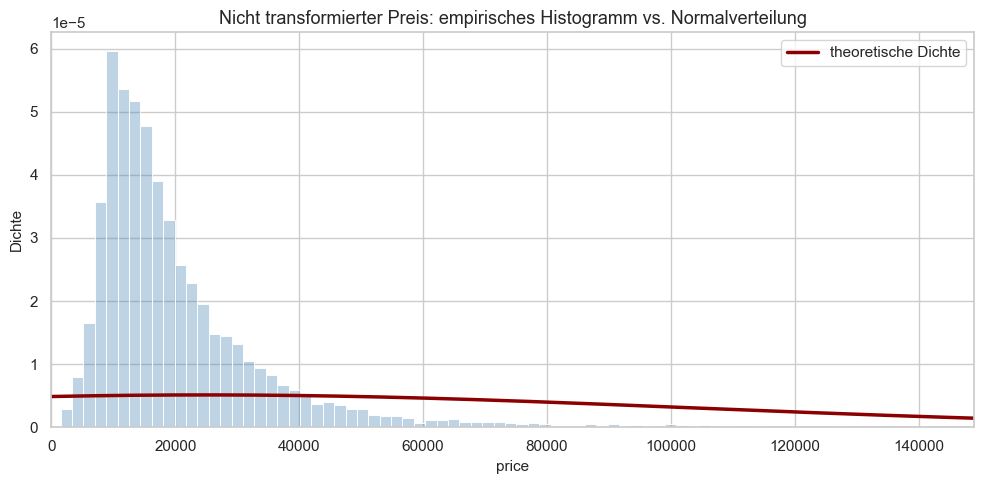

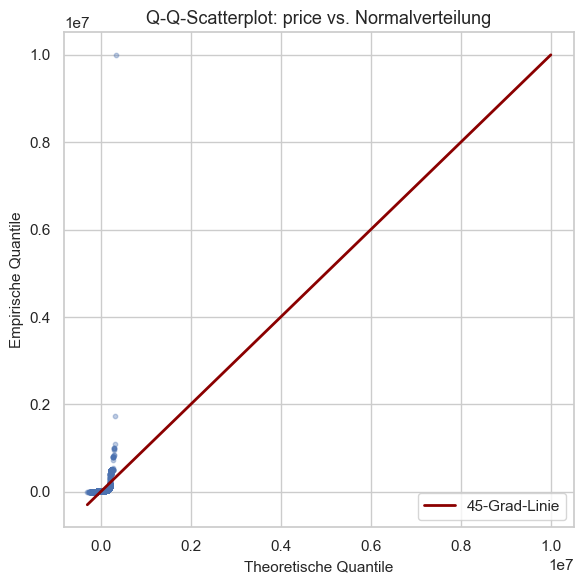

In [109]:
# Plot wird für Lesbarkeit auf das 99%-Quantil begrenzt.
x_grid_price = np.linspace(0, p99, 500)
normal_price_pdf = lambda x: stats.norm.pdf(x, loc=mu_price, scale=sd_price)

plot_hist_with_pdf(
    price_positive[price_positive <= p99],
    normal_price_pdf,
    x_grid_price,
    "Nicht transformierter Preis: empirisches Histogramm vs. Normalverteilung",
    "price",
    bins=80,
    xlim=(0, p99),
)

qq_scatter(
    price_positive,
    lambda p: stats.norm.ppf(p, loc=mu_price, scale=sd_price),
    "Q-Q-Scatterplot: price vs. Normalverteilung",
)

## 8. Annahme B: Logarithmierter Preis mit Normalverteilung

Annahme:

$$\log(price) \sim \mathcal{N}(\mu_{log}, \sigma_{log}^2)$$

Das entspricht einer Log-Normalverteilung des ursprünglichen Preises. Diese Annahme ist bei Preisen häufig plausibler, weil sie positive, rechtsschiefe Werte erzeugt.

Die Parameter werden aus den empirischen Momenten von `log(price)` geschätzt:

$$\hat{\mu}_{log} = \overline{\log(x)}, \quad \hat{\sigma}_{log} = s_{log(x)}$$

In [110]:
mu_log = log_price.mean()
sd_log = log_price.std(ddof=1)

log_normal_params = pd.DataFrame(
    {
        "Verteilung": ["Normal auf log(price)", "entspricht Lognormal auf price"],
        "mu": [mu_log, np.exp(mu_log + 0.5 * sd_log**2)],
        "sigma": [sd_log, np.nan],
        "Interpretation": ["Mittelwert von log(price)", "erwarteter Preis unter Lognormal-Annahme"],
    }
)
log_normal_params

,Verteilung,mu,sigma,Interpretation
0,Normal auf log(price),9.765066,0.67607,Mittelwert von log(price)
1,entspricht Lognormal auf price,21885.983972,NaN,erwarteter Preis unter Lognormal-Annahme


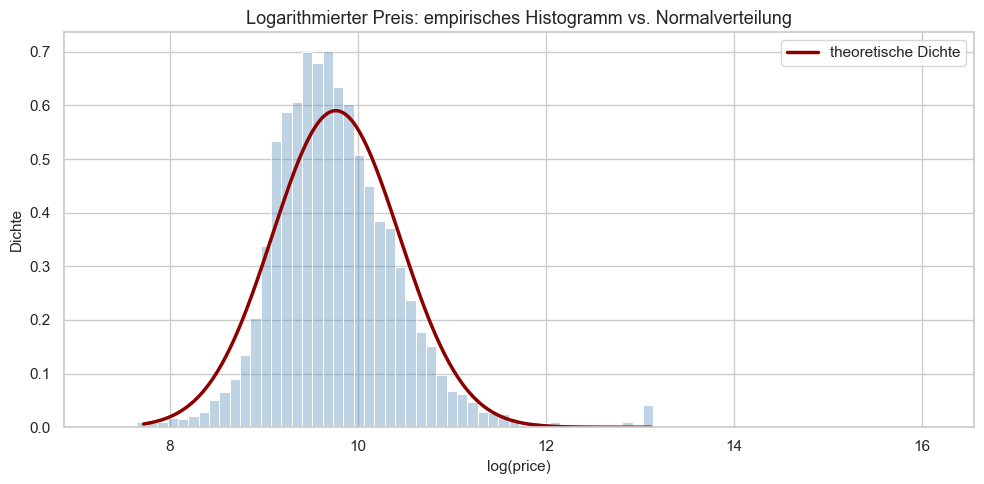

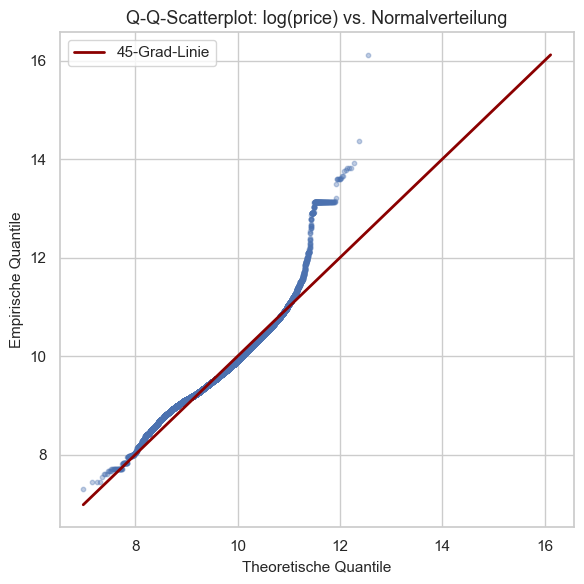

In [111]:
x_grid_log = np.linspace(log_price.quantile(0.001), log_price.quantile(0.999), 500)
normal_log_pdf = lambda x: stats.norm.pdf(x, loc=mu_log, scale=sd_log)

plot_hist_with_pdf(
    log_price,
    normal_log_pdf,
    x_grid_log,
    "Logarithmierter Preis: empirisches Histogramm vs. Normalverteilung",
    "log(price)",
    bins=80,
)

qq_scatter(
    log_price,
    lambda p: stats.norm.ppf(p, loc=mu_log, scale=sd_log),
    "Q-Q-Scatterplot: log(price) vs. Normalverteilung",
)

## 9. Annahme C: Nicht transformierter Preis mit Gammaverteilung

Annahme:

$$price \sim Gamma(\alpha, \theta)$$

Die Gammaverteilung ist nur für positive Werte definiert und kann Rechtsschiefe abbilden. Deshalb ist sie für Preise grundsätzlich plausibler als eine Normalverteilung auf der Originalskala.

Zwei Parameterschätzungen sind nützlich:

- Momentenmethode: $\hat{\alpha} = \bar{x}^2 / s^2$, $\hat{\theta} = s^2 / \bar{x}$
- Maximum Likelihood mit `scipy.stats.gamma.fit`, wobei `loc=0` fixiert wird, weil Preise positiv sind.

In [112]:
# Momentenmethode
var_price = price_positive.var(ddof=1)
gamma_shape_mom = mu_price**2 / var_price
gamma_scale_mom = var_price / mu_price

# Maximum Likelihood, loc auf 0 fixiert
gamma_shape_mle, gamma_loc_mle, gamma_scale_mle = stats.gamma.fit(price_positive, floc=0)

gamma_params = pd.DataFrame(
    {
        "Methode": ["Momentenmethode", "Maximum Likelihood"],
        "shape_alpha": [gamma_shape_mom, gamma_shape_mle],
        "loc": [0, gamma_loc_mle],
        "scale_theta": [gamma_scale_mom, gamma_scale_mle],
        "implizierter Mittelwert": [gamma_shape_mom * gamma_scale_mom, gamma_shape_mle * gamma_scale_mle],
        "implizierte Varianz": [gamma_shape_mom * gamma_scale_mom**2, gamma_shape_mle * gamma_scale_mle**2],
    }
)
gamma_params

,Methode,shape_alpha,loc,scale_theta,implizierter Mittelwert,implizierte Varianz
0,Momentenmethode,0.101292,0,244657.588054,24781.880926,6.063075e+09
1,Maximum Likelihood,1.563045,0,15854.875702,24781.880926,3.929136e+08


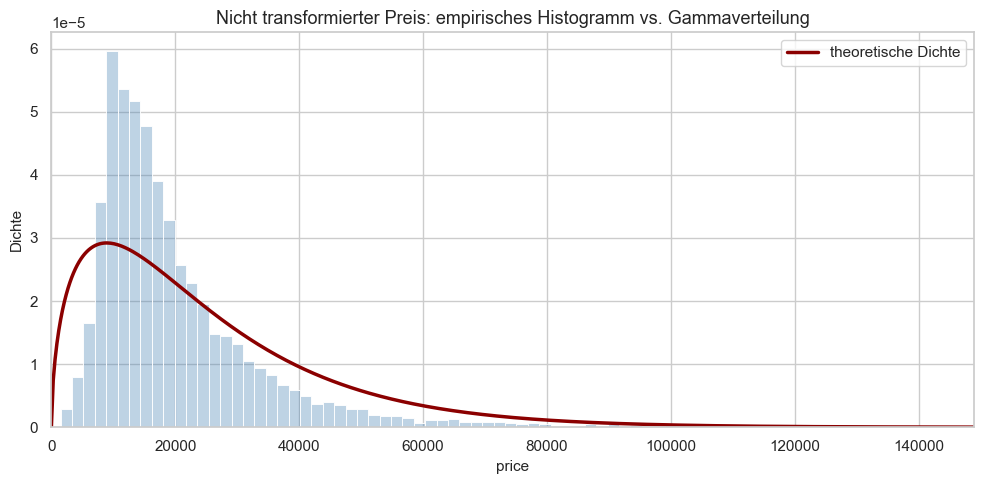

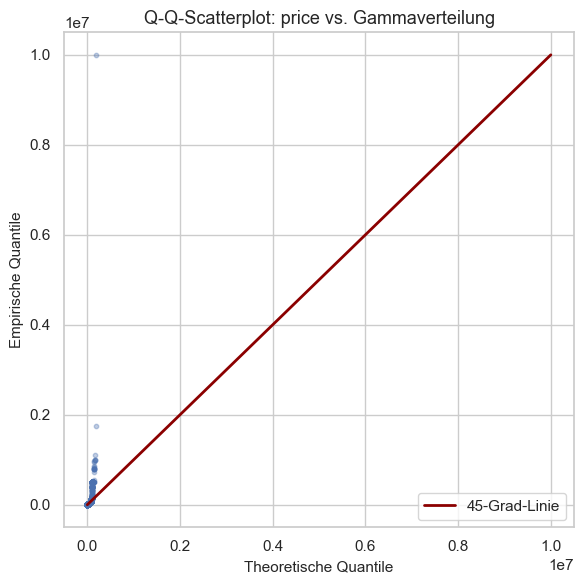

In [113]:
# Für die Visualisierung verwenden wir die MLE-Schätzung.
gamma_pdf_mle = lambda x: stats.gamma.pdf(x, a=gamma_shape_mle, loc=0, scale=gamma_scale_mle)

plot_hist_with_pdf(
    price_positive[price_positive <= p99],
    gamma_pdf_mle,
    x_grid_price,
    "Nicht transformierter Preis: empirisches Histogramm vs. Gammaverteilung",
    "price",
    bins=80,
    xlim=(0, p99),
)

qq_scatter(
    price_positive,
    lambda p: stats.gamma.ppf(p, a=gamma_shape_mle, loc=0, scale=gamma_scale_mle),
    "Q-Q-Scatterplot: price vs. Gammaverteilung",
)

## 10. Vergleich der drei Annahmen über Log-Likelihood, AIC und KS-Statistik

Die Plots sind wichtiger als eine einzelne Kennzahl, aber ein kompakter numerischer Vergleich hilft bei der Einordnung.

- Höhere Log-Likelihood ist besser.
- Niedrigeres AIC ist besser.
- Niedrigere KS-Statistik ist besser.

Achtung: Bei großen Stichproben werden formale Tests fast immer signifikant. Deshalb die Kennzahlen bitte als Diagnose, nicht als endgültige Wahrheit interpretieren.

In [114]:
x = price_positive.to_numpy()
z = log_price.to_numpy()

# Normal auf price
ll_norm_price = stats.norm.logpdf(x, loc=mu_price, scale=sd_price).sum()
aic_norm_price = 2 * 2 - 2 * ll_norm_price
ks_norm_price = stats.kstest(x, "norm", args=(mu_price, sd_price)).statistic

# Normal auf log(price)
ll_norm_log = stats.norm.logpdf(z, loc=mu_log, scale=sd_log).sum()
aic_norm_log = 2 * 2 - 2 * ll_norm_log
ks_norm_log = stats.kstest(z, "norm", args=(mu_log, sd_log)).statistic

# Gamma auf price
ll_gamma = stats.gamma.logpdf(x, a=gamma_shape_mle, loc=0, scale=gamma_scale_mle).sum()
aic_gamma = 2 * 2 - 2 * ll_gamma
ks_gamma = stats.kstest(x, "gamma", args=(gamma_shape_mle, 0, gamma_scale_mle)).statistic

comparison = pd.DataFrame(
    {
        "Annahme": [
            "price ~ Normal",
            "log(price) ~ Normal",
            "price ~ Gamma",
        ],
        "Skala": ["Originalpreis", "Log-Preis", "Originalpreis"],
        "Log-Likelihood": [ll_norm_price, ll_norm_log, ll_gamma],
        "AIC": [aic_norm_price, aic_norm_log, aic_gamma],
        "KS-Statistik": [ks_norm_price, ks_norm_log, ks_gamma],
        "Anzahl Parameter": [2, 2, 2],
    }
)

comparison

,Annahme,Skala,Log-Likelihood,AIC,KS-Statistik,Anzahl Parameter
0,price ~ Normal,Originalpreis,-323128.706858,646261.413715,0.386781,2
1,log(price) ~ Normal,Log-Preis,-26179.692246,52363.384492,0.056563,2
2,price ~ Gamma,Originalpreis,-281930.765876,563865.531751,0.140897,2


## 11. Kurze Interpretation für das Modellieren

Aus typischer Preislogik und aus den obigen Diagnosen ist meist zu erwarten:

- Eine Normalverteilung auf `price` passt schlecht, weil die Preise positiv, rechtsschief und ausreißeranfällig sind.
- Eine Normalverteilung auf `log(price)` ist oft eine gute Arbeitsannahme für Regressionsmodelle.
- Eine Gammaverteilung auf `price` ist ebenfalls plausibel, vor allem für GLMs mit Log-Link.

Praktische Empfehlung für die nächste Modellierungsstufe:

1. Als robusten Start `log(price)` oder `log1p(price)` modellieren.
2. Sehr hohe Preise gesondert prüfen, z.B. ab dem 99%-Quantil oder bei auffälligen Schwellenwerten.
3. Für lineare Modelle Residuen auf Log-Skala untersuchen.
4. Als Alternative ein Gamma-GLM mit Log-Link testen.

Für Machine-Learning-Modelle wie Gradient Boosting ist die Verteilungsannahme weniger strikt, aber die Log-Transformation der Zielvariable kann trotzdem die Stabilität und Prognosegüte verbessern.

## 12. Ausreißeranalyse: Welche Listings treiben die hohen Preise?

Auf der Originalskala gibt es relativ viele auffällige hohe Preise. Das ist bei Preisen nicht ungewöhnlich, weil Preisverteilungen meist stark rechtsschief sind. Wichtig ist deshalb nicht nur die Anzahl der Ausreißer, sondern auch, ob sie inhaltlich plausibel sind.

Wir betrachten mehrere Definitionen:

- `raw_iqr_outlier`: klassischer IQR-Fence auf dem Originalpreis, also `price > Q3 + 1.5 * IQR`.
- `log_iqr_outlier`: IQR-Fence auf `log(price)`, danach zurückgerechnet auf die Preisskala. Diese Definition ist robuster bei rechtsschiefen Preisen.
- `top_1_percent`: die teuersten ca. 1% der Listings.
- `price_ge_500k`: sehr hohe Preise ab 500,000. Diese Gruppe ist besonders interessant, weil sehr viele Listings exakt `500000` als Preis haben können.


In [115]:
listings_price = listings.loc[
    listings["price_numeric"].notna() & (listings["price_numeric"] > 0)
].copy()

price = listings_price["price_numeric"]
log_price = np.log(price)

q1 = price.quantile(0.25)
q3 = price.quantile(0.75)
iqr = q3 - q1
raw_iqr_upper = q3 + 1.5 * iqr

log_q1 = log_price.quantile(0.25)
log_q3 = log_price.quantile(0.75)
log_iqr = log_q3 - log_q1
log_iqr_upper = np.exp(log_q3 + 1.5 * log_iqr)

p95 = price.quantile(0.95)
p99 = price.quantile(0.99)

listings_price["raw_iqr_outlier"] = listings_price["price_numeric"] > raw_iqr_upper
listings_price["log_iqr_outlier"] = listings_price["price_numeric"] > log_iqr_upper
listings_price["top_1_percent"] = listings_price["price_numeric"] >= p99
listings_price["price_ge_500k"] = listings_price["price_numeric"] >= 500_000

outlier_thresholds = pd.DataFrame(
    {
        "Definition": [
            "Q1",
            "Q3",
            "IQR",
            "IQR upper fence auf price",
            "IQR upper fence auf log(price), zurückgerechnet",
            "95%-Quantil",
            "99%-Quantil",
            "sehr hohe Schwelle",
        ],
        "Wert": [q1, q3, iqr, raw_iqr_upper, log_iqr_upper, p95, p99, 500_000],
    }
)

outlier_thresholds

,Definition,Wert
0,Q1,11201.500000
1,Q3,25045.000000
2,IQR,13843.500000
3,IQR upper fence auf price,45810.250000
4,"IQR upper fence auf log(price), zurückgerechnet",83731.391146
5,95%-Quantil,51612.200000
6,99%-Quantil,148912.960000
7,sehr hohe Schwelle,500000.000000


### 12.1 Wie viele Ausreißer gibt es?

Der klassische IQR-Fence auf `price` markiert viele Listings als Ausreißer, weil die Originalverteilung stark rechtsschief ist. Die Log-IQR-Definition und die Top-1%-Definition sind strenger und eignen sich besser, um wirklich extreme Preise zu untersuchen.

In [116]:
outlier_flags = ["raw_iqr_outlier", "log_iqr_outlier", "top_1_percent", "price_ge_500k"]

outlier_counts = pd.DataFrame(
    {
        "Definition": outlier_flags,
        "Anzahl Listings": [listings_price[col].sum() for col in outlier_flags],
        "Anteil in %": [100 * listings_price[col].mean() for col in outlier_flags],
        "Schwelle": [raw_iqr_upper, log_iqr_upper, p99, 500_000],
    }
)

outlier_counts

,Definition,Anzahl Listings,Anteil in %,Schwelle
0,raw_iqr_outlier,1715,6.730769,45810.250000
1,log_iqr_outlier,499,1.958399,83731.391146
2,top_1_percent,255,1.000785,148912.960000
3,price_ge_500k,130,0.510204,500000.000000


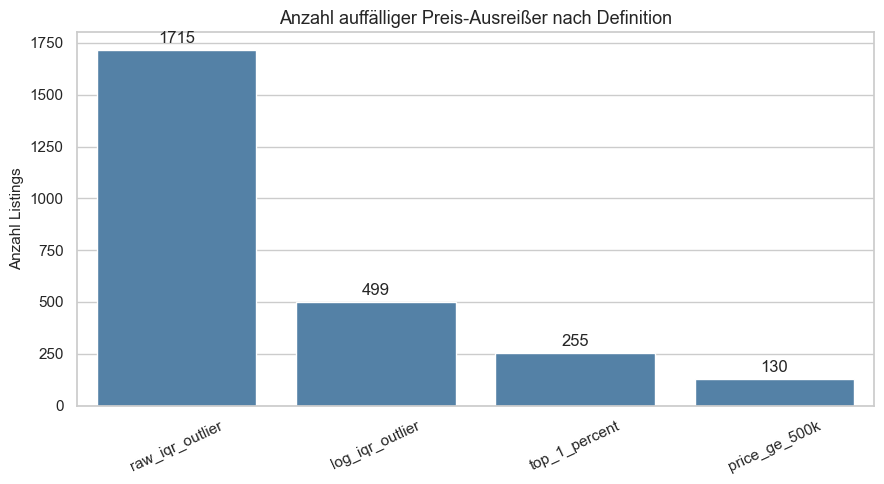

In [117]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=outlier_counts, x="Definition", y="Anzahl Listings", ax=ax, color="steelblue")
ax.set_title("Anzahl auffälliger Preis-Ausreißer nach Definition")
ax.set_xlabel("")
ax.set_ylabel("Anzahl Listings")
ax.tick_params(axis="x", rotation=25)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

plt.tight_layout()
plt.show()

### 12.2 Häufige Extrempreise und mögliche Datenartefakte

Wenn sehr hohe Preise ungewöhnlich oft exakt gleich auftreten, kann das ein Hinweis auf eine künstliche Obergrenze, einen Platzhalter, Rundung oder eine besondere Eingabepraxis sein. Deshalb schauen wir uns die häufigsten Preiswerte oberhalb von 100,000 separat an.

In [118]:
high_price_frequency = (
    listings_price.loc[listings_price["price_numeric"] >= 100_000, "price_numeric"]
    .value_counts()
    .rename_axis("price")
    .reset_index(name="Anzahl")
    .sort_values(["Anzahl", "price"], ascending=[False, False])
    .head(20)
)

high_price_frequency

,price,Anzahl
0,500000.0,108
1,400000.0,20
2,100000.0,10
6,799999.0,6
4,460000.0,6
3,150000.0,6
5,114286.0,6
7,179983.0,5
9,180949.0,4
8,155429.0,4


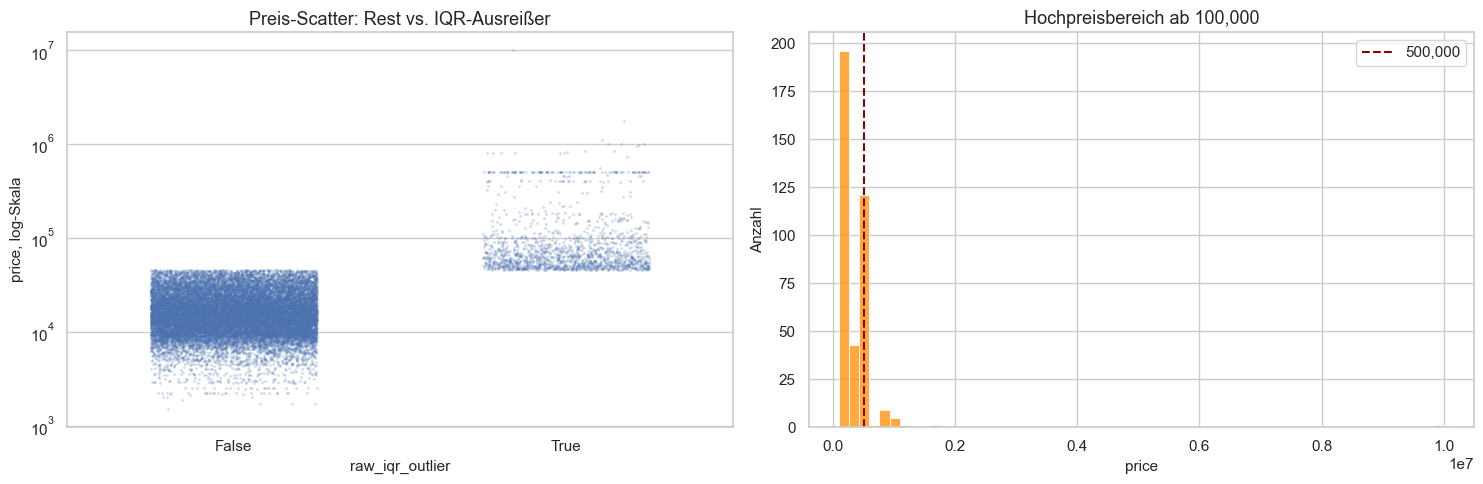

In [119]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.stripplot(
    data=listings_price,
    x="raw_iqr_outlier",
    y="price_numeric",
    jitter=0.25,
    alpha=0.25,
    size=2,
    ax=axes[0],
)
axes[0].set_yscale("log")
axes[0].set_title("Preis-Scatter: Rest vs. IQR-Ausreißer")
axes[0].set_xlabel("raw_iqr_outlier")
axes[0].set_ylabel("price, log-Skala")

sns.histplot(
    data=listings_price[listings_price["price_numeric"] >= 100_000],
    x="price_numeric",
    bins=60,
    ax=axes[1],
    color="darkorange",
)
axes[1].axvline(500_000, color="darkred", linestyle="--", label="500,000")
axes[1].set_title("Hochpreisbereich ab 100,000")
axes[1].set_xlabel("price")
axes[1].set_ylabel("Anzahl")
axes[1].legend()

plt.tight_layout()
plt.show()

### 12.3 Numerisches Profil: Ausreißer vs. übrige Listings

Hier vergleichen wir zentrale metrische Variablen. Wenn Ausreißer z.B. deutlich mehr Personen aufnehmen, mehr Schlafzimmer oder mehr Betten haben, sind hohe Preise teilweise inhaltlich plausibel.

In [120]:
main_outlier_flag = "raw_iqr_outlier"

numeric_profile_cols = [
    "price_numeric",
    "accommodates",
    "bedrooms",
    "beds",
    "bathrooms",
    "minimum_nights",
    "availability_365",
    "number_of_reviews",
    "review_scores_rating",
    "reviews_per_month",
    "calculated_host_listings_count",
]
numeric_profile_cols = [col for col in numeric_profile_cols if col in listings_price.columns]

numeric_profile = []
for col in numeric_profile_cols:
    rest = listings_price.loc[~listings_price[main_outlier_flag], col]
    out = listings_price.loc[listings_price[main_outlier_flag], col]
    numeric_profile.append(
        {
            "Variable": col,
            "Median Rest": rest.median(),
            "Median Ausreißer": out.median(),
            "Mean Rest": rest.mean(),
            "Mean Ausreißer": out.mean(),
            "Missing Rest %": 100 * rest.isna().mean(),
            "Missing Ausreißer %": 100 * out.isna().mean(),
        }
    )

numeric_profile = pd.DataFrame(numeric_profile)
numeric_profile

,Variable,Median Rest,Median Ausreißer,Mean Rest,Mean Ausreißer,Missing Rest %,Missing Ausreißer %
0,price_numeric,15470.00,63020.00,17711.768483,122753.439067,0.000000,0.000000
1,accommodates,4.00,8.00,4.258910,8.135860,0.000000,0.000000
2,bedrooms,1.00,2.00,1.344362,2.581341,0.033663,0.000000
3,beds,2.00,5.00,2.785952,5.397085,0.016831,0.000000
4,bathrooms,1.00,1.00,1.130383,1.565306,0.033663,0.000000
5,minimum_nights,2.00,2.00,5.067410,5.604665,0.000000,0.000000
6,availability_365,164.00,203.00,176.980097,200.534694,0.000000,0.000000
7,number_of_reviews,17.00,13.00,37.073469,34.742274,0.000000,0.000000
8,review_scores_rating,4.81,4.91,4.734335,4.839720,13.057017,22.973761
9,reviews_per_month,1.39,1.73,1.712481,1.918827,13.057017,22.973761


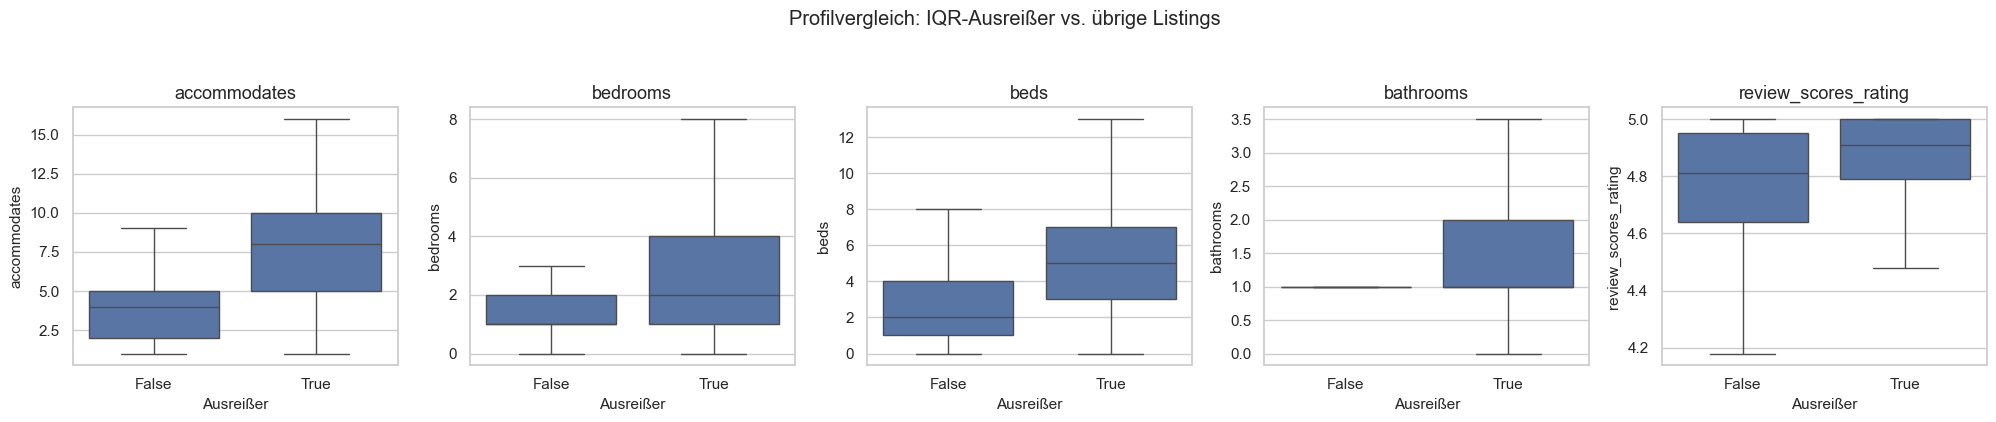

In [121]:
plot_cols = ["accommodates", "bedrooms", "beds", "bathrooms", "review_scores_rating"]
plot_cols = [col for col in plot_cols if col in listings_price.columns]

fig, axes = plt.subplots(1, len(plot_cols), figsize=(4 * len(plot_cols), 4))
if len(plot_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, plot_cols):
    sns.boxplot(data=listings_price, x=main_outlier_flag, y=col, showfliers=False, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("Ausreißer")

plt.suptitle("Profilvergleich: IQR-Ausreißer vs. übrige Listings", y=1.05)
plt.tight_layout()
plt.show()

### 12.4 Kategoriales Profil: Was haben die Ausreißer gemeinsam?

Für kategoriale Variablen vergleichen wir die Anteile innerhalb der Ausreißergruppe mit den Anteilen im Rest der Daten. Positive Werte bei `Differenz in Prozentpunkten` bedeuten: Diese Kategorie ist unter den Ausreißern überrepräsentiert.

In [122]:
def categorical_share_difference(df, column, flag_col=main_outlier_flag, top_n=12):
    out_share = df.loc[df[flag_col], column].value_counts(normalize=True, dropna=False)
    rest_share = df.loc[~df[flag_col], column].value_counts(normalize=True, dropna=False)
    result = pd.DataFrame(
        {
            "Anteil Ausreißer": out_share,
            "Anteil Rest": rest_share,
        }
    ).fillna(0)
    result["Differenz in Prozentpunkten"] = 100 * (result["Anteil Ausreißer"] - result["Anteil Rest"])
    result["Anteil Ausreißer"] *= 100
    result["Anteil Rest"] *= 100
    return result.sort_values("Differenz in Prozentpunkten", ascending=False).head(top_n)

categorical_cols = [
    "room_type",
    "property_type",
    "neighbourhood_cleansed",
    "host_is_superhost",
    "instant_bookable",
]

for col in categorical_cols:
    if col in listings_price.columns:
        print(f"\n=== {col} ===")
        display(categorical_share_difference(listings_price, col))


=== room_type ===


,Anteil Ausreißer,Anteil Rest,Differenz in Prozentpunkten
room_type,,,
Entire home/apt,91.428571,86.316011,5.112560
Hotel room,0.116618,0.361877,-0.245259
Shared room,0.000000,1.068799,-1.068799
Private room,8.454810,12.253314,-3.798503



=== property_type ===


,Anteil Ausreißer,Anteil Rest,Differenz in Prozentpunkten
property_type,,,
Entire home,32.186589,12.985483,19.201106
Room in aparthotel,4.897959,1.312855,3.585104
Entire villa,3.381924,0.551231,2.830693
Room in hotel,4.489796,2.524721,1.965075
Entire condo,3.556851,2.474227,1.082625
Entire serviced apartment,2.215743,1.405428,0.810315
Room in boutique hotel,1.224490,0.715338,0.509152
Entire townhouse,0.524781,0.138860,0.385922
Hut,0.349854,0.117820,0.232034



=== neighbourhood_cleansed ===


,Anteil Ausreißer,Anteil Rest,Differenz in Prozentpunkten
neighbourhood_cleansed,,,
Shinjuku Ku,25.947522,17.311172,8.636350
Shibuya Ku,14.810496,6.320219,8.490277
Minato Ku,8.163265,4.014307,4.148959
Taito Ku,13.994169,9.985272,4.008897
Chuo Ku,3.148688,1.051967,2.096721
Setagaya Ku,3.790087,3.433621,0.356467
Akiruno Shi,0.408163,0.096781,0.311382
Meguro Ku,0.758017,0.450242,0.307776
Chiyoda Ku,0.874636,0.723753,0.150882



=== host_is_superhost ===


,Anteil Ausreißer,Anteil Rest,Differenz in Prozentpunkten
host_is_superhost,,,
t,51.895044,40.963602,10.931442
NaN,7.988338,7.195456,0.792883
f,40.116618,51.840943,-11.724324



=== instant_bookable ===


,Anteil Ausreißer,Anteil Rest,Differenz in Prozentpunkten
instant_bookable,,,
f,24.664723,21.573743,3.09098
t,75.335277,78.426257,-3.09098


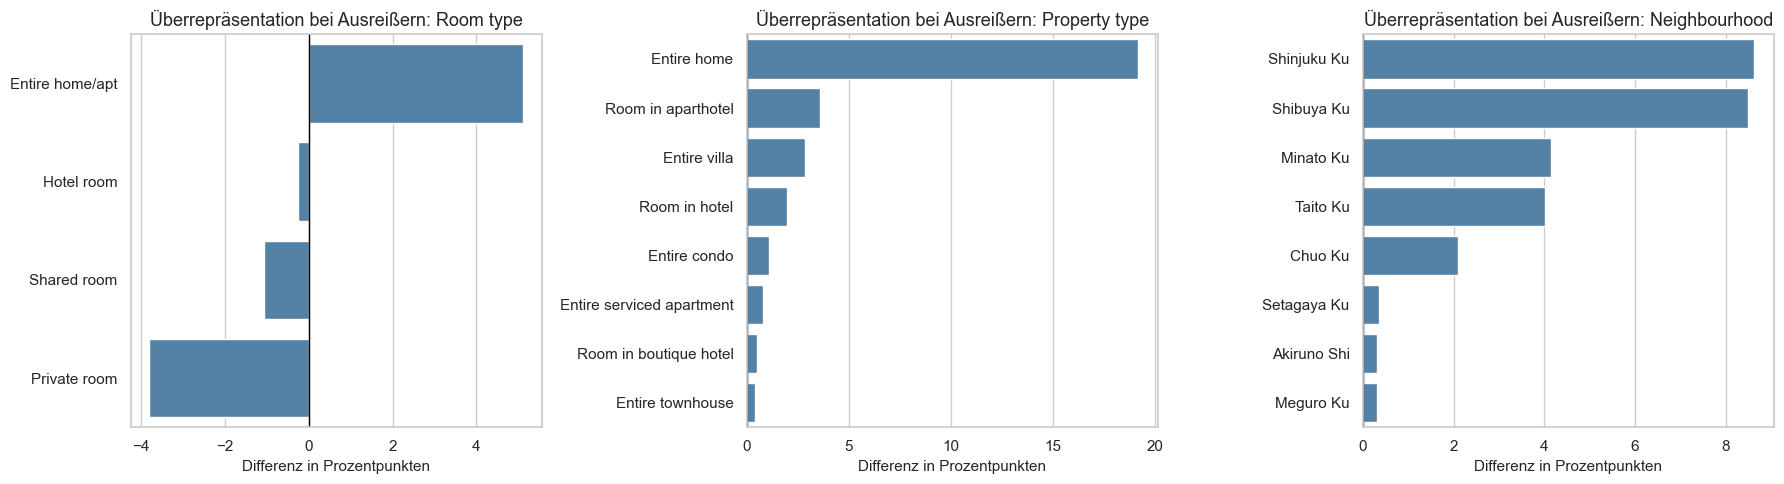

In [123]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col, title in zip(
    axes,
    ["room_type", "property_type", "neighbourhood_cleansed"],
    ["Room type", "Property type", "Neighbourhood"],
):
    tmp = categorical_share_difference(listings_price, col, top_n=8).reset_index()
    tmp = tmp.rename(columns={"index": col})
    sns.barplot(data=tmp, y=col, x="Differenz in Prozentpunkten", ax=ax, color="steelblue")
    ax.axvline(0, color="black", linewidth=1)
    ax.set_title(f"Überrepräsentation bei Ausreißern: {title}")
    ax.set_xlabel("Differenz in Prozentpunkten")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

### 12.5 Ausstattung: Haben teure Ausreißer mehr Amenities?

Die Spalte `amenities` enthält eine Liste von Ausstattungsmerkmalen. Hier extrahieren wir erst die Anzahl der Amenities und prüfen dann ausgewählte Merkmale.

In [124]:
import ast

def parse_amenities(value):
    if pd.isna(value):
        return []
    try:
        parsed = ast.literal_eval(value)
        return parsed if isinstance(parsed, list) else []
    except (ValueError, SyntaxError):
        return []

listings_price["amenities_list"] = listings_price["amenities"].apply(parse_amenities)
listings_price["amenities_count"] = listings_price["amenities_list"].apply(len)

amenities_profile = pd.DataFrame(
    {
        "Gruppe": ["Rest", "Ausreißer"],
        "Median amenities_count": [
            listings_price.loc[~listings_price[main_outlier_flag], "amenities_count"].median(),
            listings_price.loc[listings_price[main_outlier_flag], "amenities_count"].median(),
        ],
        "Mean amenities_count": [
            listings_price.loc[~listings_price[main_outlier_flag], "amenities_count"].mean(),
            listings_price.loc[listings_price[main_outlier_flag], "amenities_count"].mean(),
        ],
    }
)

amenities_profile

,Gruppe,Median amenities_count,Mean amenities_count
0,Rest,31.0,31.678687
1,Ausreißer,37.0,36.934694


In [125]:
selected_amenities = [
    "TV",
    "Coffee",
    "Private entrance",
    "Dedicated workspace",
    "Luggage dropoff",
    "Kitchen",
    "Free parking",
    "Washer",
    "Hot tub",
    "Elevator",
    "Self check-in",
    "Air conditioning",
    "Lockbox",
]

def contains_amenity(amenities, search_term):
    text = " | ".join(str(item).lower() for item in amenities)
    return search_term.lower() in text

amenity_diffs = []
for amenity in selected_amenities:
    flag = listings_price["amenities_list"].apply(lambda items: contains_amenity(items, amenity))
    share_out = flag[listings_price[main_outlier_flag]].mean()
    share_rest = flag[~listings_price[main_outlier_flag]].mean()
    amenity_diffs.append(
        {
            "Amenity": amenity,
            "Anteil Ausreißer %": 100 * share_out,
            "Anteil Rest %": 100 * share_rest,
            "Differenz in Prozentpunkten": 100 * (share_out - share_rest),
        }
    )

amenity_diffs = pd.DataFrame(amenity_diffs).sort_values("Differenz in Prozentpunkten", ascending=False)
amenity_diffs

,Amenity,Anteil Ausreißer %,Anteil Rest %,Differenz in Prozentpunkten
0,TV,77.842566,63.867031,13.975534
1,Coffee,25.481050,11.567431,13.913618
2,Private entrance,53.702624,43.740795,9.961829
3,Dedicated workspace,48.571429,41.140332,7.431096
4,Luggage dropoff,29.387755,22.545761,6.841995
5,Kitchen,94.927114,90.119924,4.807189
6,Free parking,7.580175,2.970755,4.609420
7,Washer,94.635569,91.171891,3.463677
8,Hot tub,10.787172,7.936040,2.851132
9,Elevator,33.294461,31.958763,1.335698


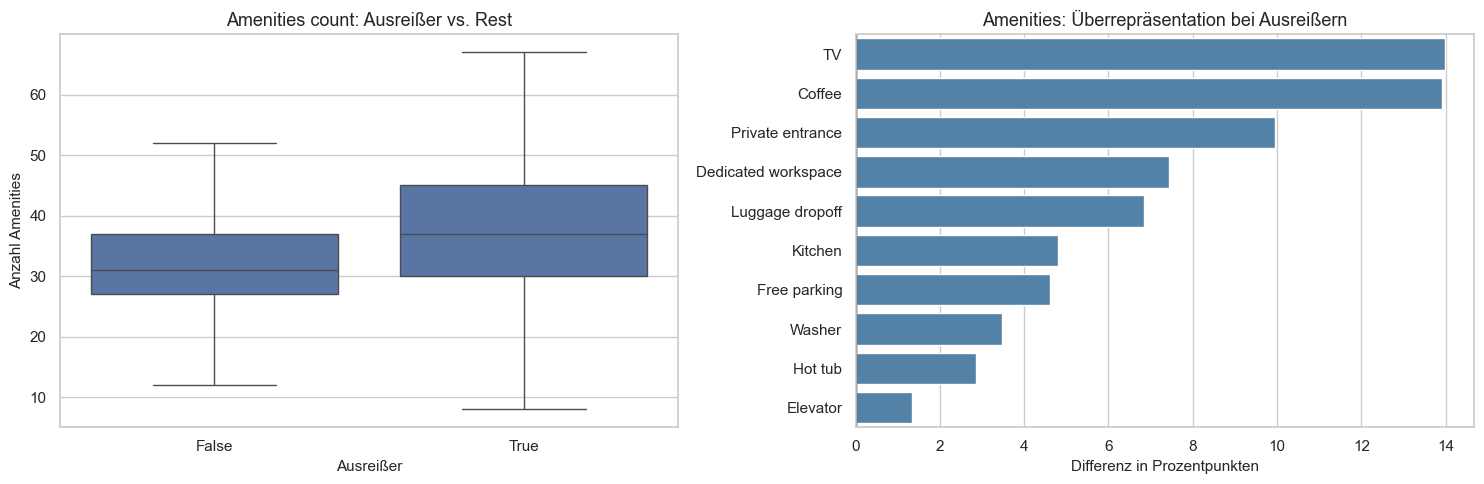

In [126]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(data=listings_price, x=main_outlier_flag, y="amenities_count", showfliers=False, ax=axes[0])
axes[0].set_title("Amenities count: Ausreißer vs. Rest")
axes[0].set_xlabel("Ausreißer")
axes[0].set_ylabel("Anzahl Amenities")

sns.barplot(
    data=amenity_diffs.head(10),
    y="Amenity",
    x="Differenz in Prozentpunkten",
    ax=axes[1],
    color="steelblue",
)
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_title("Amenities: Überrepräsentation bei Ausreißern")
axes[1].set_xlabel("Differenz in Prozentpunkten")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

### 12.6 Die extremsten Listings ansehen

Zum Schluss sehen wir uns die teuersten Listings direkt an. Besonders spannend ist, ob sehr hohe Preise durch Größe und Luxus plausibel wirken oder ob viele kleine Listings mit exakt gleichem Extrempreis auftreten.

In [127]:
columns_to_show = [
    "id",
    "name",
    "price_numeric",
    "room_type",
    "property_type",
    "neighbourhood_cleansed",
    "accommodates",
    "bedrooms",
    "bathrooms",
    "beds",
    "number_of_reviews",
    "review_scores_rating",
    "instant_bookable",
    "host_is_superhost",
]
columns_to_show = [col for col in columns_to_show if col in listings_price.columns]

top_price_listings = (
    listings_price[columns_to_show]
    .sort_values("price_numeric", ascending=False)
    .head(30)
)

top_price_listings

,id,name,price_numeric,room_type,property_type,neighbourhood_cleansed,accommodates,bedrooms,bathrooms,beds,number_of_reviews,review_scores_rating,instant_bookable,host_is_superhost
14374,1181748125859376165,渋谷駅/代々木公園駅まで徒歩圏内｜キッチン付きアパートメント｜37.6㎡｜最大5名,9999998.0,Entire home/apt,Entire serviced apartment,Shibuya Ku,5,1.0,1.0,2.0,24,4.96,t,t
9854,986104471785930330,【New House】2 min from station/4 min from Shina...,1742858.0,Entire home/apt,Entire rental unit,Shinagawa Ku,2,1.0,1.0,4.0,22,4.95,f,t
15804,1225618287786473681,Work In Progress 401,1103381.0,Private room,Private room in rental unit,Koto Ku,3,1.0,0.0,2.0,0,NaN,f,f
870,21080730,なごみ ホテル (NAGOMI HOTEL NIPPORI) - プレミアムツイン,999999.0,Hotel room,Room in hotel,Arakawa Ku,2,1.0,1.0,3.0,0,NaN,t,f
3682,40953417,3min->JR Oimachi Station/Japanese Superior Room,999999.0,Private room,Room in hotel,Shinagawa Ku,5,1.0,1.0,1.0,0,NaN,t,f
27722,1510608309509626483,Skytree地鐵５分 電梯大樓 廚房 洗衣機 機場直達免換車 淺草直達 頂樓眺望晴空塔夜景,999999.0,Entire home/apt,Entire rental unit,Sumida Ku,16,2.0,2.0,8.0,0,NaN,f,f
8754,924382114602933410,LGG101A東京中心部交通便利,969999.0,Entire home/apt,Entire rental unit,Katsushika Ku,6,1.0,1.0,3.0,0,NaN,t,t
25452,1457649915534457748,(For Long stay) Shibuya Digital Nomad | 8mins stn,948915.0,Entire home/apt,Entire rental unit,Shibuya Ku,3,1.0,1.0,3.0,1,5.00,f,t
20384,1348295862373707614,NEW OPEN/山手線沿いの立地/リフォーム済み/田端駅/駅近物件/最大10名/301SS,850400.0,Entire home/apt,Entire rental unit,Kita Ku,10,1.0,1.0,5.0,35,4.94,t,f
20382,1348272286721787268,NEW OPEN/山手線沿いの立地/リフォーム済み/田端駅/駅近物件/最大7名/SS,849712.0,Entire home/apt,Entire rental unit,Kita Ku,7,2.0,1.0,4.0,19,4.84,t,f


### 12.7 Zwischenfazit zur Ausreißeranalyse

Die Ausreißer sollten nicht pauschal gelöscht werden. Viele hohe Preise können durch größere Kapazität, bessere Ausstattung, ganze Wohnungen/Häuser und zentrale Lagen plausibel sein. Gleichzeitig sollte die exakt häufige Preisstufe `500000` kritisch geprüft werden, weil viele gleiche Extrempreise nach Datenartefakt, Preisdeckel, Platzhalter oder temporär blockierendem Fantasiepreis aussehen können.

Praktische Empfehlung:

1. Modelle zunächst mit `log(price)` oder `log1p(price)` schätzen.
2. Ergebnisse einmal mit und ohne extreme Preisgruppe, z.B. `price >= 500000`, vergleichen.
3. Top-1%-Listings separat prüfen und eventuell winsorisieren oder als eigenes Luxussegment behandeln.
4. Für die Bewertung MAE oder RMSLE ergänzen, weil RMSE extrem stark auf Ausreißer reagiert.

### 12.8 Runde Preis-Klumpen oberhalb von 100,000

Neben `500000` können auch andere runde oder psychologische Preiswerte auffällig sein, z.B. `300000`, `400000`, `799999` oder `999999`. Deshalb zählen wir hier exakte Preiswerte, runde 10,000er-Werte und grobe 50,000er-Intervalle.

In [128]:
high_prices = listings_price.loc[listings_price["price_numeric"] >= 100_000, "price_numeric"]

exact_high_price_counts = (
    high_prices
    .value_counts()
    .rename_axis("price")
    .reset_index(name="Anzahl")
    .sort_values(["Anzahl", "price"], ascending=[False, False])
)
exact_high_price_counts["Anteil an Preisen >= 100000 in %"] = (
    100 * exact_high_price_counts["Anzahl"] / len(high_prices)
)

exact_high_price_counts.head(40)

,price,Anzahl,Anteil an Preisen >= 100000 in %
0,500000.0,108,28.571429
1,400000.0,20,5.291005
2,100000.0,10,2.645503
6,799999.0,6,1.587302
4,460000.0,6,1.587302
3,150000.0,6,1.587302
5,114286.0,6,1.587302
7,179983.0,5,1.322751
9,180949.0,4,1.058201
8,155429.0,4,1.058201


In [129]:
selected_roundish_values = [
    100_000,
    120_000,
    150_000,
    180_000,
    200_000,
    250_000,
    300_000,
    350_000,
    360_000,
    400_000,
    450_000,
    460_000,
    490_000,
    500_000,
    799_999,
    999_999,
]

roundish_counts = pd.DataFrame(
    {
        "price": selected_roundish_values,
        "Anzahl": [(high_prices == value).sum() for value in selected_roundish_values],
    }
)
roundish_counts = roundish_counts[roundish_counts["Anzahl"] > 0].copy()
roundish_counts["Anteil an Preisen >= 100000 in %"] = 100 * roundish_counts["Anzahl"] / len(high_prices)

roundish_counts.sort_values("Anzahl", ascending=False)

,price,Anzahl,Anteil an Preisen >= 100000 in %
13,500000,108,28.571429
9,400000,20,5.291005
0,100000,10,2.645503
2,150000,6,1.587302
11,460000,6,1.587302
14,799999,6,1.587302
8,360000,3,0.793651
15,999999,3,0.793651
1,120000,2,0.529101
6,300000,2,0.529101


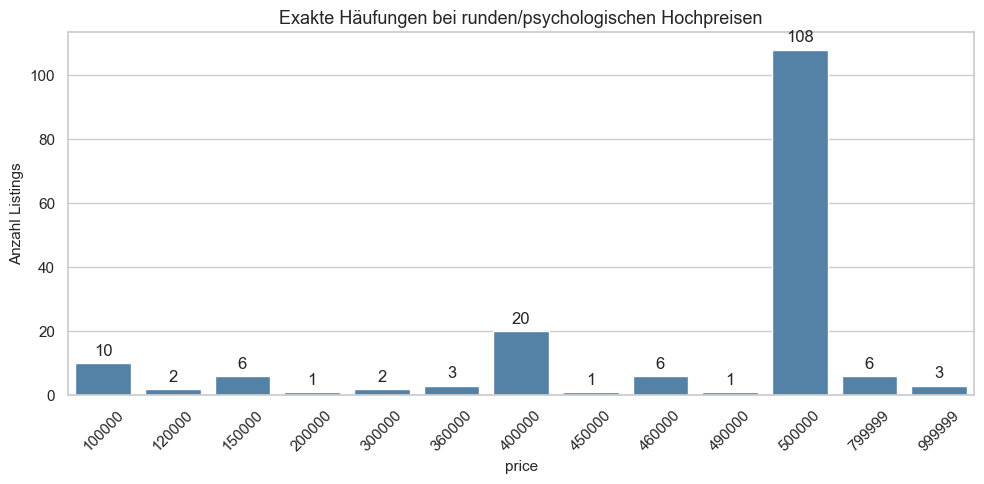

In [130]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=roundish_counts.sort_values("price"),
    x="price",
    y="Anzahl",
    ax=ax,
    color="steelblue",
)
ax.set_title("Exakte Häufungen bei runden/psychologischen Hochpreisen")
ax.set_xlabel("price")
ax.set_ylabel("Anzahl Listings")
ax.tick_params(axis="x", rotation=45)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

plt.tight_layout()
plt.show()

In [131]:
bins = list(range(100_000, 600_001, 50_000)) + [np.inf]
labels = [
    f"{bins[i]:,.0f}-{bins[i + 1] - 1:,.0f}" if np.isfinite(bins[i + 1]) else f">={bins[i]:,.0f}"
    for i in range(len(bins) - 1)
]

high_price_bins = (
    pd.cut(price, bins=bins, labels=labels, right=False)
    .value_counts()
    .sort_index()
    .rename_axis("Preisintervall")
    .reset_index(name="Anzahl")
)

high_price_bins

,Preisintervall,Anzahl
0,"100,000-149,999",123
1,"150,000-199,999",62
2,"200,000-249,999",11
3,"250,000-299,999",4
4,"300,000-349,999",8
5,"350,000-399,999",8
6,"400,000-449,999",23
7,"450,000-499,999",9
8,"500,000-549,999",111
9,"550,000-599,999",1


Kurzinterpretation: Wenn `500000` sehr viel häufiger vorkommt als benachbarte Werte, ist das ein stärkerer Artefakt-Hinweis als eine allgemeine Häufung hoher Preise. Ein kleinerer Klumpen bei `400000` oder psychologische Werte wie `799999`/`999999` können ebenfalls auffällig sein, sind aber deutlich schwächer als der `500000`-Peak.

### 12.9 Deep Dive: Sind die exakt `500000`-Listings zufällig?

Jetzt prüfen wir die Preisstufe `500000` gezielt. Wenn diese Listings nur zufällig extrem teuer wären, würden wir erwarten, dass sie ähnlich heterogen sind wie andere Hochpreis-Listings. Besonders verdächtig wäre dagegen eine Kombination aus:

- sehr ähnlichen Objektmerkmalen,
- wenigen Hosts mit vielen Listings,
- wenig oder keiner Review-Historie,
- kleinen Standard-Apartments statt Luxusobjekten,
- auffälligen Einstellungen wie immer `instant_bookable` oder identischem Mindestaufenthalt.

In [132]:
exact_500 = listings_price[listings_price["price_numeric"] == 500_000].copy()
above_500 = listings_price[listings_price["price_numeric"] > 500_000].copy()
high_non_500 = listings_price[
    (listings_price["price_numeric"] >= 100_000) & (listings_price["price_numeric"] != 500_000)
].copy()
below_100 = listings_price[listings_price["price_numeric"] < 100_000].copy()

top_host_counts = exact_500["host_id"].value_counts()

exact_500_summary = pd.DataFrame(
    {
        "Kennzahl": [
            "Listings exakt 500000",
            "Anteil an allen validen Preisen in %",
            "Anteil an Preisen >= 100000 in %",
            "Unique Hosts",
            "Anteil Top-1-Host in %",
            "Anteil Top-5-Hosts in %",
            "Anteil Top-10-Hosts in %",
            "Anteil ohne Reviews in %",
            "Anteil fehlender Review Score in %",
            "Median Mindestnächte",
            "Median accommodates",
            "Median bedrooms",
            "Median bathrooms",
            "Median price/accommodates",
        ],
        "Wert": [
            len(exact_500),
            100 * len(exact_500) / len(listings_price),
            100 * len(exact_500) / len(high_prices),
            exact_500["host_id"].nunique(),
            100 * top_host_counts.head(1).sum() / len(exact_500),
            100 * top_host_counts.head(5).sum() / len(exact_500),
            100 * top_host_counts.head(10).sum() / len(exact_500),
            100 * (exact_500["number_of_reviews"] == 0).mean(),
            100 * exact_500["review_scores_rating"].isna().mean(),
            exact_500["minimum_nights"].median(),
            exact_500["accommodates"].median(),
            exact_500["bedrooms"].median(),
            exact_500["bathrooms"].median(),
            (exact_500["price_numeric"] / exact_500["accommodates"].replace(0, np.nan)).median(),
        ],
    }
)

exact_500_summary

,Kennzahl,Wert
0,Listings exakt 500000,108.000000
1,Anteil an allen validen Preisen in %,0.423862
2,Anteil an Preisen >= 100000 in %,28.571429
3,Unique Hosts,23.000000
4,Anteil Top-1-Host in %,19.444444
5,Anteil Top-5-Hosts in %,50.925926
6,Anteil Top-10-Hosts in %,79.629630
7,Anteil ohne Reviews in %,96.296296
8,Anteil fehlender Review Score in %,96.296296
9,Median Mindestnächte,30.000000


#### 12.9.1 Homogenität der `500000`-Listings

Hier prüfen wir, ob die exakt `500000`-Listings in bestimmten Variablen fast vollständig identisch sind. Genau das wäre ein starkes Argument gegen Zufall.

In [133]:
homogeneity_cols = [
    "source",
    "room_type",
    "property_type",
    "bathrooms",
    "bedrooms",
    "beds",
    "accommodates",
    "instant_bookable",
    "host_is_superhost",
    "minimum_nights",
    "neighbourhood_cleansed",
]

homogeneity_tables = []
for col in homogeneity_cols:
    vc = exact_500[col].value_counts(dropna=False).head(8)
    tmp = vc.rename_axis("Ausprägung").reset_index(name="Anzahl")
    tmp["Variable"] = col
    tmp["Anteil in %"] = 100 * tmp["Anzahl"] / len(exact_500)
    homogeneity_tables.append(tmp[["Variable", "Ausprägung", "Anzahl", "Anteil in %"]])

exact_500_homogeneity = pd.concat(homogeneity_tables, ignore_index=True)
exact_500_homogeneity

,Variable,Ausprägung,Anzahl,Anteil in %
0,source,city scrape,108,100.000000
1,room_type,Entire home/apt,108,100.000000
2,property_type,Entire rental unit,108,100.000000
3,bathrooms,1.0,108,100.000000
4,bedrooms,1.0,99,91.666667
5,bedrooms,0.0,5,4.629630
6,bedrooms,2.0,4,3.703704
7,beds,2.0,69,63.888889
8,beds,1.0,25,23.148148
9,beds,3.0,12,11.111111


In [134]:
perfect_or_near_perfect = []
for col in homogeneity_cols:
    top_value = exact_500[col].value_counts(dropna=False).index[0]
    top_share = exact_500[col].value_counts(normalize=True, dropna=False).iloc[0]
    perfect_or_near_perfect.append(
        {
            "Variable": col,
            "häufigster Wert": top_value,
            "Anteil häufigster Wert in %": 100 * top_share,
        }
    )

perfect_or_near_perfect = pd.DataFrame(perfect_or_near_perfect).sort_values(
    "Anteil häufigster Wert in %", ascending=False
)
perfect_or_near_perfect

,Variable,häufigster Wert,Anteil häufigster Wert in %
0,source,city scrape,100.000000
1,room_type,Entire home/apt,100.000000
2,property_type,Entire rental unit,100.000000
3,bathrooms,1.0,100.000000
7,instant_bookable,t,100.000000
9,minimum_nights,30,100.000000
4,bedrooms,1.0,91.666667
8,host_is_superhost,f,77.777778
5,beds,2.0,63.888889
6,accommodates,2,37.037037


#### 12.9.2 Vergleich mit anderen Hochpreis-Listings

Wichtig ist der Vergleich: Sind `500000`-Listings ähnlich wie andere Listings über `100000`, oder sind sie ein eigener Block? Besonders aussagekräftig sind Größe, Reviews, Mindestnächte und Host-Struktur.

In [135]:
comparison_groups = {
    "exact_500": exact_500,
    ">500k": above_500,
    "100k+ ohne 500k": high_non_500,
    "<100k": below_100,
}

compare_cols = [
    "price_numeric",
    "accommodates",
    "bedrooms",
    "beds",
    "bathrooms",
    "minimum_nights",
    "availability_365",
    "number_of_reviews",
    "review_scores_rating",
    "reviews_per_month",
    "calculated_host_listings_count",
    "estimated_occupancy_l365d",
    "estimated_revenue_l365d",
]

deep_compare = []
for group_name, group_df in comparison_groups.items():
    for col in compare_cols:
        if col in group_df.columns:
            deep_compare.append(
                {
                    "Gruppe": group_name,
                    "Variable": col,
                    "Median": group_df[col].median(),
                    "Mean": group_df[col].mean(),
                    "Missing in %": 100 * group_df[col].isna().mean(),
                }
            )

deep_compare = pd.DataFrame(deep_compare)
deep_compare.pivot(index="Variable", columns="Gruppe", values="Median")

Gruppe,100k+ ohne 500k,<100k,>500k,exact_500
Variable,,,,
accommodates,7.50,4.00,5.000,3.00
availability_365,195.00,166.00,270.000,157.50
bathrooms,1.00,1.00,1.000,1.00
bedrooms,2.00,1.00,1.000,1.00
beds,5.00,2.00,2.000,2.00
calculated_host_listings_count,8.00,11.00,5.000,36.00
estimated_occupancy_l365d,6.00,60.00,0.000,0.00
estimated_revenue_l365d,1133718.00,921510.00,0.000,0.00
minimum_nights,2.00,2.00,1.000,30.00


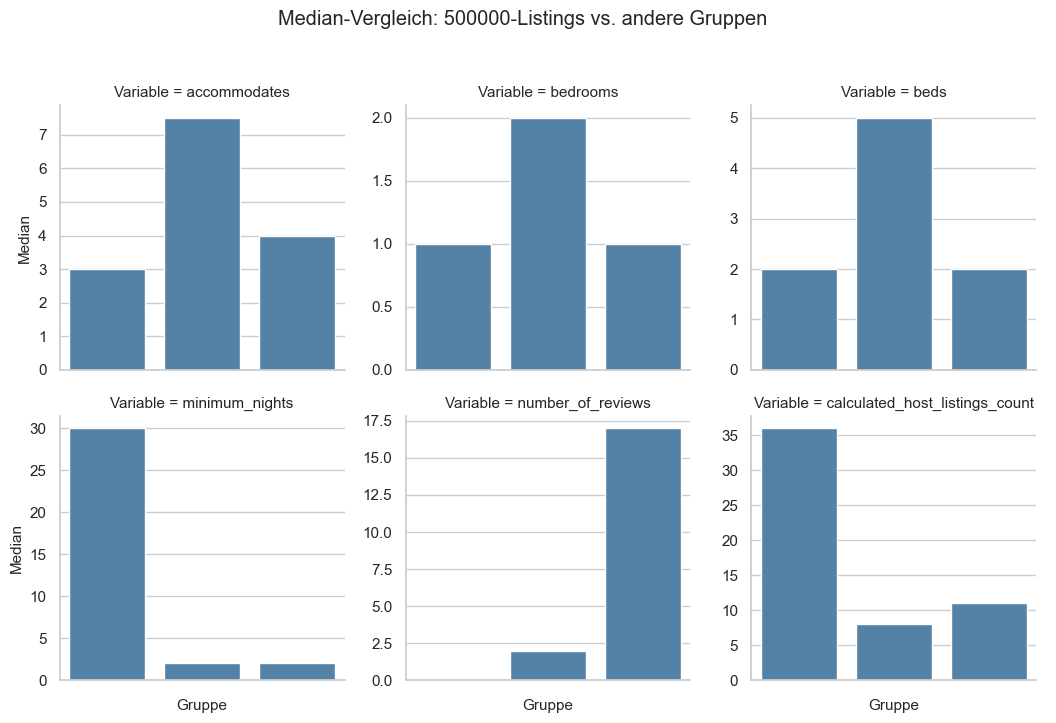

In [136]:
important_compare = ["accommodates", "bedrooms", "beds", "minimum_nights", "number_of_reviews", "calculated_host_listings_count"]

plot_compare = deep_compare[
    (deep_compare["Variable"].isin(important_compare)) &
    (deep_compare["Gruppe"].isin(["exact_500", "100k+ ohne 500k", "<100k"]))
].copy()

g = sns.catplot(
    data=plot_compare,
    x="Gruppe",
    y="Median",
    col="Variable",
    kind="bar",
    col_wrap=3,
    sharey=False,
    height=3.5,
    color="steelblue",
)
g.set_xticklabels(rotation=25)
g.fig.suptitle("Median-Vergleich: 500000-Listings vs. andere Gruppen", y=1.03)
plt.tight_layout()
plt.show()

#### 12.9.3 Host-Konzentration

Ein weiteres starkes Indiz: Wenn ein großer Anteil der `500000`-Listings von wenigen Hosts stammt, spricht das eher für eine gemeinsame Pricing- oder Datenlogik als für zufällige Marktpreise.

In [137]:
host_concentration_500 = (
    exact_500.groupby(["host_id", "host_name"], dropna=False)
    .agg(
        n=("id", "size"),
        median_accommodates=("accommodates", "median"),
        median_minimum_nights=("minimum_nights", "median"),
        zero_review_share=("number_of_reviews", lambda x: 100 * (x == 0).mean()),
        top_neighbourhoods=("neighbourhood_cleansed", lambda x: ", ".join(x.value_counts().head(3).index.astype(str))),
    )
    .sort_values("n", ascending=False)
)

host_concentration_500.head(20)

,,n,median_accommodates,median_minimum_nights,zero_review_share,top_neighbourhoods
host_id,host_name,,,,,
673266881,圭太,21,3.0,30.0,100.000000,Sumida Ku
560593757,圭太,9,2.0,30.0,77.777778,"Shinjuku Ku, Bunkyo Ku"
555388862,圭太,9,2.0,30.0,77.777778,Shibuya Ku
560594175,圭太,8,3.0,30.0,100.000000,Minato Ku
549672914,圭太,8,4.0,30.0,100.000000,Shinjuku Ku
544359262,本町,7,4.0,30.0,100.000000,Nakano Ku
560591971,圭太,7,2.0,30.0,100.000000,Nakano Ku
560596302,圭太,7,3.0,30.0,100.000000,Shibuya Ku
664379712,圭汰,5,2.0,30.0,100.000000,"Shinjuku Ku, Toshima Ku"


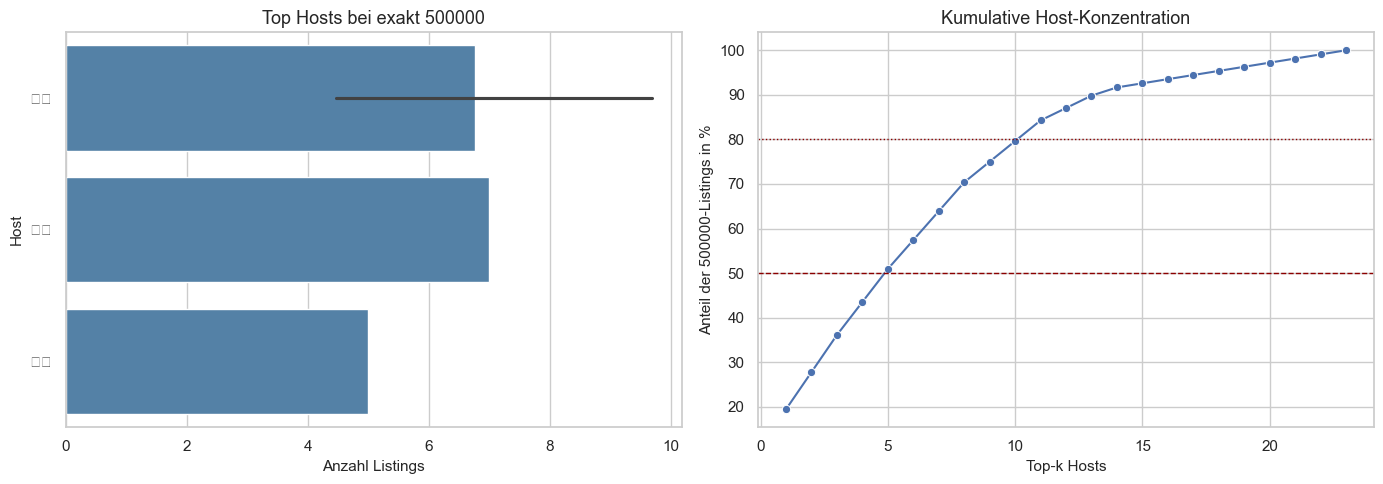

,Host-Rang,Kumulierte Listings,Kumulierter Anteil in %
0,1,21,19.444444
1,2,30,27.777778
2,3,39,36.111111
3,4,47,43.518519
4,5,55,50.925926
5,6,62,57.407407
6,7,69,63.888889
7,8,76,70.370370
8,9,81,75.000000
9,10,86,79.629630


In [138]:
host_cum = host_concentration_500["n"].reset_index(drop=True).cumsum().reset_index()
host_cum.columns = ["Host-Rang", "Kumulierte Listings"]
host_cum["Host-Rang"] += 1
host_cum["Kumulierter Anteil in %"] = 100 * host_cum["Kumulierte Listings"] / len(exact_500)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    data=host_concentration_500.head(15).reset_index(),
    x="n",
    y="host_name",
    ax=axes[0],
    color="steelblue",
)
axes[0].set_title("Top Hosts bei exakt 500000")
axes[0].set_xlabel("Anzahl Listings")
axes[0].set_ylabel("Host")

sns.lineplot(data=host_cum, x="Host-Rang", y="Kumulierter Anteil in %", marker="o", ax=axes[1])
axes[1].axhline(50, color="darkred", linestyle="--", linewidth=1)
axes[1].axhline(80, color="darkred", linestyle=":", linewidth=1)
axes[1].set_title("Kumulative Host-Konzentration")
axes[1].set_xlabel("Top-k Hosts")
axes[1].set_ylabel("Anteil der 500000-Listings in %")

plt.tight_layout()
plt.show()

host_cum.head(20)

#### 12.9.4 Peer-Group-Check: Sind das Luxusobjekte?

Die `500000`-Listings sehen überwiegend wie kleine bis mittlere Standard-Apartments aus. Deshalb bilden wir eine einfache Peer Group: `Entire home/apt`, `Entire rental unit`, 1 Bad, 0–2 Schlafzimmer, 1–6 Gäste, Preis unter 100000. Wenn diese Peer Group viel günstiger ist, spricht das gegen eine normale Marktpreis-Erklärung.

In [139]:
peer_group = listings_price[
    (listings_price["room_type"] == "Entire home/apt") &
    (listings_price["property_type"] == "Entire rental unit") &
    (listings_price["bathrooms"] == 1) &
    (listings_price["bedrooms"].isin([0, 1, 2])) &
    (listings_price["accommodates"].between(1, 6)) &
    (listings_price["price_numeric"] < 100_000)
].copy()

peer_summary = pd.DataFrame(
    {
        "Kennzahl": [
            "Peer-Group n",
            "Peer median price",
            "Peer 95%-Quantil",
            "Peer 99%-Quantil",
            "500000 / Peer median",
            "500000 / Peer 99%-Quantil",
        ],
        "Wert": [
            len(peer_group),
            peer_group["price_numeric"].median(),
            peer_group["price_numeric"].quantile(0.95),
            peer_group["price_numeric"].quantile(0.99),
            500_000 / peer_group["price_numeric"].median(),
            500_000 / peer_group["price_numeric"].quantile(0.99),
        ],
    }
)

peer_summary

,Kennzahl,Wert
0,Peer-Group n,13645.000000
1,Peer median price,14215.000000
2,Peer 95%-Quantil,33492.400000
3,Peer 99%-Quantil,48240.240000
4,500000 / Peer median,35.174112
5,500000 / Peer 99%-Quantil,10.364791


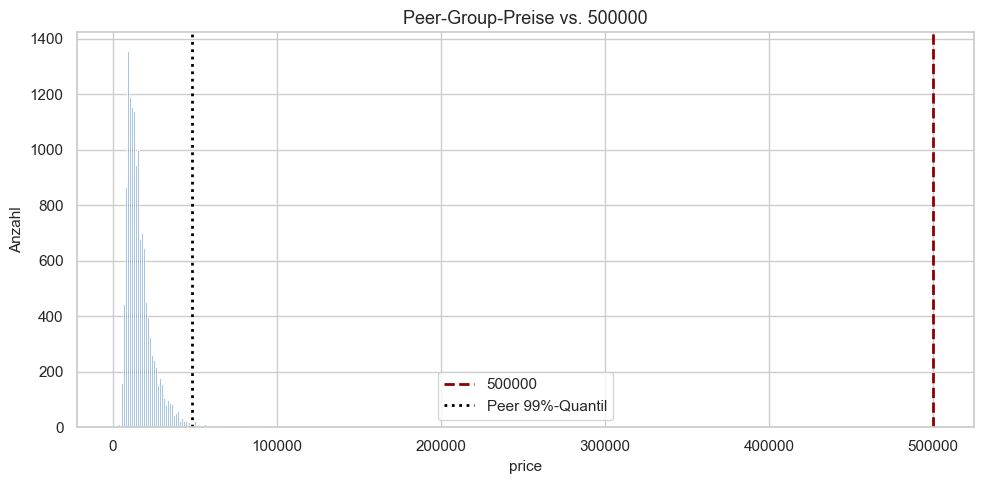

In [140]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(peer_group["price_numeric"], bins=80, color="steelblue", alpha=0.45, ax=ax)
ax.axvline(500_000, color="darkred", linestyle="--", linewidth=2, label="500000")
ax.axvline(peer_group["price_numeric"].quantile(0.99), color="black", linestyle=":", linewidth=2, label="Peer 99%-Quantil")
ax.set_title("Peer-Group-Preise vs. 500000")
ax.set_xlabel("price")
ax.set_ylabel("Anzahl")
ax.legend()

plt.tight_layout()
plt.show()

#### 12.9.5 Beispiele: Die ersten `500000`-Listings

Die Beispieltabelle hilft bei der qualitativen Prüfung. Achte besonders auf ähnliche Namen, gleiche Hosts, kleine Kapazität und fehlende Reviews.

In [141]:
cols_500_show = [
    "id",
    "host_id",
    "host_name",
    "name",
    "price_numeric",
    "neighbourhood_cleansed",
    "accommodates",
    "bedrooms",
    "bathrooms",
    "beds",
    "minimum_nights",
    "availability_365",
    "number_of_reviews",
    "review_scores_rating",
    "instant_bookable",
]

exact_500_examples = exact_500[cols_500_show].sort_values(["host_id", "id"]).head(40)
exact_500_examples

,id,host_id,host_name,name,price_numeric,neighbourhood_cleansed,accommodates,bedrooms,bathrooms,beds,minimum_nights,availability_365,number_of_reviews,review_scores_rating,instant_bookable
20109,1341048175905201420,462983474,圭太,Built in 2020/ close to the sta/Wi-Fi e02,500000.0,Shinjuku Ku,3,1.0,1.0,2.0,30,146,0,NaN,t
26841,1490193219269992308,484345966,圭太,8 minutes walk from Hiroo Station / Designer/e02,500000.0,Minato Ku,4,1.0,1.0,3.0,30,224,0,NaN,t
25935,1470025686074399746,490397315,Sumyca,5 min walk to Honancho / with auto lock/d01,500000.0,Suginami Ku,3,0.0,1.0,2.0,30,157,0,NaN,t
21053,1364855059069184692,527952456,圭太,5 min. walk from Shin-Okubo station!WI-FI/b03,500000.0,Shinjuku Ku,2,1.0,1.0,1.0,30,270,0,NaN,t
25356,1456142921936450896,544359262,本町,Designer apartment with attractive wood grain ...,500000.0,Nakano Ku,4,1.0,1.0,2.0,30,129,0,NaN,t
25357,1456143663183805027,544359262,本町,Designer apartment with attractive wood grain ...,500000.0,Nakano Ku,4,1.0,1.0,2.0,30,116,0,NaN,t
25358,1456145273439969957,544359262,本町,Designer apartment with attractive wood grain ...,500000.0,Nakano Ku,4,1.0,1.0,2.0,30,149,0,NaN,t
25359,1456146036463567373,544359262,本町,Designer apartment with attractive wood grain ...,500000.0,Nakano Ku,4,1.0,1.0,2.0,30,142,0,NaN,t
25360,1456146859094010546,544359262,本町,Designer apartment with attractive wood grain ...,500000.0,Nakano Ku,4,1.0,1.0,2.0,30,126,0,NaN,t
25361,1456147587445875366,544359262,本町,Designer apartment with attractive wood grain ...,500000.0,Nakano Ku,4,1.0,1.0,2.0,30,158,0,NaN,t


#### 12.9.6 Fazit zu `500000`

Die Evidenz spricht eher **gegen Zufall**:

- Alle exakt `500000`-Listings sind `Entire home/apt` und `Entire rental unit`.
- Alle haben `instant_bookable = t` und 1 Bad.
- Die meisten sind klein: typischerweise 2–4 Gäste, 1 Schlafzimmer und 1–2 Betten.
- Fast alle haben keine Reviews beziehungsweise fehlende Review Scores.
- Ein großer Teil kommt von wenigen Hosts; die Top-Hosts dominieren die Gruppe stark.
- Gegenüber einer vergleichbaren Peer Group kleiner ganzer Apartments ist `500000` um ein Vielfaches höher.

Interpretation: Diese Listings wirken weniger wie echte Luxuspreise und eher wie ein Daten-/Pricing-Artefakt, z.B. Platzhalterpreis, temporärer Blockierungspreis, System-Default, Host-spezifische Pricing-Strategie oder fehlerhafte Preisübernahme.

Für das Modellieren würde ich deshalb eine Sensitivitätsanalyse machen: Modell einmal mit allen Preisen, einmal ohne `price == 500000`, und einmal ohne sehr extreme Preise ab `500000`. Wenn die Modellgüte oder Feature-Effekte stark wechseln, sollten diese Listings nicht wie normale Marktpreise behandelt werden.

## 13. Review-Score-Buckets datengetrieben wählen

Review-Scores sind keine normale lineare Skala. Ein Unterschied von `4.9` auf `5.0` kann anders wirken als ein Unterschied von `3.9` auf `4.0`. Außerdem liegen die meisten Werte sehr nah am oberen Rand zwischen `4.5` und `5.0`.

Deshalb prüfen wir hier die tatsächliche Verteilung und bauen Buckets, die im oberen Bereich feiner sind als im unteren Bereich.

In [142]:
score_cols = [
    "review_scores_rating",
    "review_scores_accuracy",
    "review_scores_cleanliness",
    "review_scores_checkin",
    "review_scores_communication",
    "review_scores_location",
    "review_scores_value",
]
score_cols = [col for col in score_cols if col in listings_price.columns]

score_distribution_summary = []
for col in score_cols:
    s = listings_price[col]
    score_distribution_summary.append(
        {
            "Variable": col,
            "n": len(s),
            "nonmissing": s.notna().sum(),
            "missing_%": 100 * s.isna().mean(),
            "unique_values": s.nunique(dropna=True),
            "mean": s.mean(),
            "p05": s.quantile(0.05),
            "p25": s.quantile(0.25),
            "median": s.median(),
            "p75": s.quantile(0.75),
            "p90": s.quantile(0.90),
            "share_5_%": 100 * (s == 5).mean(),
            "share_ge_4_9_%": 100 * (s >= 4.9).mean(),
            "share_lt_4_5_%": 100 * (s < 4.5).mean(),
        }
    )

score_distribution_summary = pd.DataFrame(score_distribution_summary)
score_distribution_summary

,Variable,n,nonmissing,missing_%,unique_values,mean,p05,p25,median,p75,p90,share_5_%,share_ge_4_9_%,share_lt_4_5_%
0,review_scores_rating,25480,21983,13.724490,150,4.740668,4.22,4.65,4.820,4.96,5.0,18.708791,30.141287,10.384615
1,review_scores_accuracy,25480,21982,13.728414,131,4.775819,4.33,4.70,4.850,4.96,5.0,19.607535,33.100471,7.362637
2,review_scores_cleanliness,25480,21982,13.728414,170,4.721571,4.07,4.62,4.810,4.96,5.0,19.042386,31.173469,12.676609
3,review_scores_checkin,25480,21982,13.728414,129,4.799213,4.33,4.73,4.880,5.00,5.0,21.597331,39.105181,6.954474
4,review_scores_communication,25480,21982,13.728414,116,4.845056,4.50,4.80,4.920,5.00,5.0,26.785714,47.931711,4.046311
5,review_scores_location,25480,21982,13.728414,136,4.723895,4.23,4.62,4.785,4.91,5.0,15.306122,24.050235,11.106750
6,review_scores_value,25480,21982,13.728414,145,4.688244,4.15,4.59,4.750,4.89,5.0,14.344584,20.765306,12.919937


### 13.1 Angepasste Bucket-Logik

Die Daten sprechen gegen simple Stern-Dummies `1`, `2`, `3`, `4`, `5`. Stattdessen sind feinere Buckets im oberen Bereich sinnvoll:

- `missing`
- `<4.0`
- `4.0-4.49`
- `4.5-4.69`
- `4.7-4.79`
- `4.8-4.89`
- `4.90-4.94`
- `4.95-4.99`
- `5.0`

Diese Einteilung nutzt die Daten dort feiner, wo viele Beobachtungen liegen. Gleichzeitig bleiben niedrige Bewertungen zusammengefasst, weil sie selten sind.

In [143]:
review_bucket_order = [
    "missing",
    "<4.0",
    "4.0-4.49",
    "4.5-4.69",
    "4.7-4.79",
    "4.8-4.89",
    "4.90-4.94",
    "4.95-4.99",
    "5.0",
]

def bucket_review_score(x):
    if pd.isna(x):
        return "missing"
    if x < 4.0:
        return "<4.0"
    if x < 4.5:
        return "4.0-4.49"
    if x < 4.7:
        return "4.5-4.69"
    if x < 4.8:
        return "4.7-4.79"
    if x < 4.9:
        return "4.8-4.89"
    if x < 4.95:
        return "4.90-4.94"
    if x < 5.0:
        return "4.95-4.99"
    return "5.0"

for col in score_cols:
    bucket_col = f"{col}_bucket"
    listings_price[bucket_col] = listings_price[col].apply(bucket_review_score)
    listings_price[bucket_col] = pd.Categorical(
        listings_price[bucket_col], categories=review_bucket_order, ordered=True
    )

In [144]:
score_bucket_counts = []
for col in score_cols:
    bucket_col = f"{col}_bucket"
    counts = listings_price[bucket_col].value_counts().reindex(review_bucket_order).fillna(0).astype(int)
    for bucket, n in counts.items():
        score_bucket_counts.append(
            {
                "Variable": col,
                "Bucket": bucket,
                "n": n,
                "Anteil_%": 100 * n / len(listings_price),
            }
        )

score_bucket_counts = pd.DataFrame(score_bucket_counts)
score_bucket_counts.pivot(index="Bucket", columns="Variable", values="n").reindex(review_bucket_order)

Variable,review_scores_accuracy,review_scores_checkin,review_scores_cleanliness,review_scores_communication,review_scores_location,review_scores_rating,review_scores_value
Bucket,,,,,,,
missing,3498,3498,3498,3498,3498,3497,3498
<4.0,301,267,577,220,295,416,478
4.0-4.49,1575,1505,2653,811,2535,2230,2814
4.5-4.69,3542,2893,4087,1982,4827,4207,5658
4.7-4.79,3282,2622,2932,2303,3722,3249,3929
4.8-4.89,4848,4731,3790,4453,4475,4201,3812
4.90-4.94,2309,2785,1987,2951,1672,1878,1222
4.95-4.99,1129,1676,1104,2437,556,1035,414
5.0,4996,5503,4852,6825,3900,4767,3655


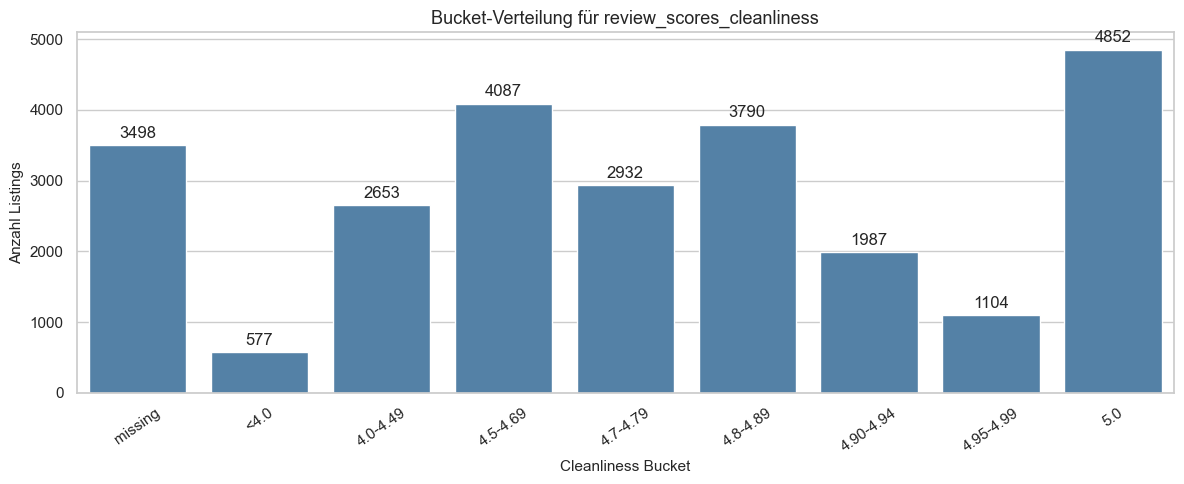

In [145]:
fig, ax = plt.subplots(figsize=(12, 5))

clean_counts = score_bucket_counts[score_bucket_counts["Variable"] == "review_scores_cleanliness"]
sns.barplot(data=clean_counts, x="Bucket", y="n", ax=ax, color="steelblue")
ax.set_title("Bucket-Verteilung für review_scores_cleanliness")
ax.set_xlabel("Cleanliness Bucket")
ax.set_ylabel("Anzahl Listings")
ax.tick_params(axis="x", rotation=35)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

plt.tight_layout()
plt.show()

### 13.2 Prüfen: Cleanliness-Buckets vs. Preis und Review-Anzahl

Gerade der Bucket `5.0` sollte separat bleiben: Eine perfekte Bewertung kann bei vielen Reviews sehr stark sein, bei nur wenigen Reviews aber weniger aussagekräftig. Deshalb schauen wir hier zusätzlich auf `number_of_reviews` je Bucket.

In [146]:
cleanliness_bucket_profile = (
    listings_price
    .groupby("review_scores_cleanliness_bucket", observed=False)
    .agg(
        n=("price_numeric", "size"),
        median_price=("price_numeric", "median"),
        mean_price=("price_numeric", "mean"),
        p95_price=("price_numeric", lambda x: x.quantile(0.95)),
        median_reviews=("number_of_reviews", "median"),
        mean_reviews=("number_of_reviews", "mean"),
        zero_review_share=("number_of_reviews", lambda x: 100 * (x == 0).mean()),
        share_price_500k=("price_numeric", lambda x: 100 * (x == 500_000).mean()),
    )
    .reindex(review_bucket_order)
)

cleanliness_bucket_profile

,n,median_price,mean_price,p95_price,median_reviews,mean_reviews,zero_review_share,share_price_500k
review_scores_cleanliness_bucket,,,,,,,,
missing,3498,15600.0,42532.330475,160002.85,0.0,0.000286,99.971412,2.973128
<4.0,577,11572.0,14852.526863,34593.60,3.0,8.227036,0.000000,0.000000
4.0-4.49,2653,13321.0,16724.705616,37248.80,20.0,34.321523,0.000000,0.000000
4.5-4.69,4087,14760.0,18694.509665,40848.00,28.0,51.357230,0.000000,0.000000
4.7-4.79,2932,16186.0,20923.748636,45085.05,35.0,59.126876,0.000000,0.000000
4.8-4.89,3790,17691.0,22339.477309,50432.80,35.0,60.951979,0.000000,0.000000
4.90-4.94,1987,19448.0,24507.452441,56862.50,36.0,59.757423,0.000000,0.000000
4.95-4.99,1104,21607.5,36696.891304,62417.70,47.0,66.943841,0.000000,0.000000
5.0,4852,17522.5,24339.343570,55053.70,3.0,7.815746,0.000000,0.082440


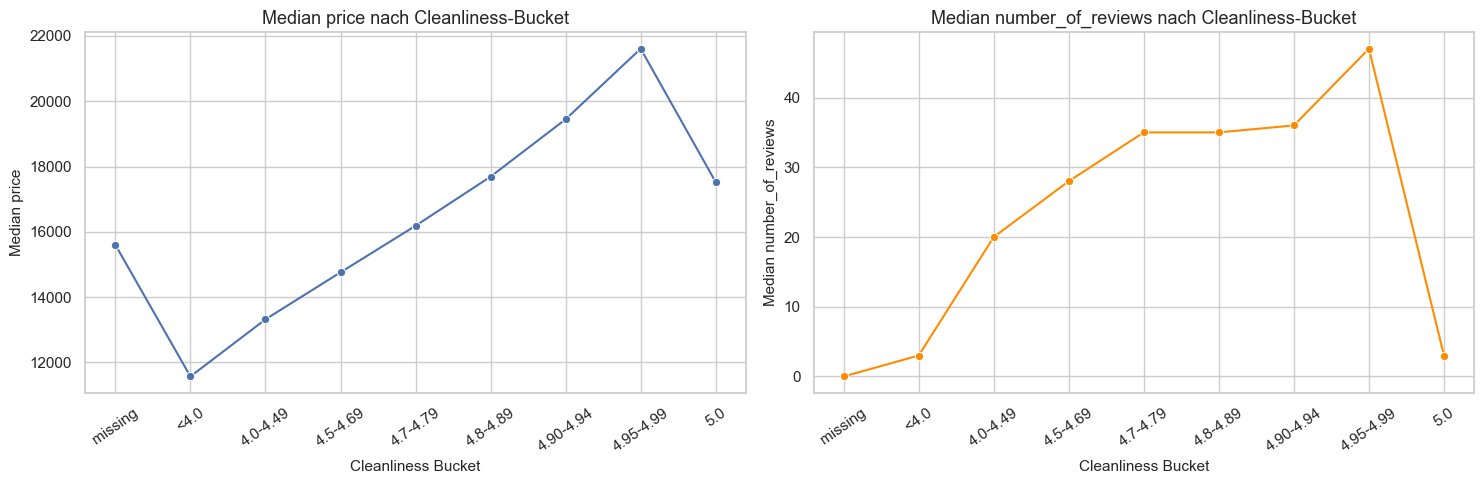

In [147]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

profile_plot = cleanliness_bucket_profile.reset_index().rename(
    columns={"review_scores_cleanliness_bucket": "Bucket"}
)

sns.lineplot(data=profile_plot, x="Bucket", y="median_price", marker="o", ax=axes[0])
axes[0].set_title("Median price nach Cleanliness-Bucket")
axes[0].set_xlabel("Cleanliness Bucket")
axes[0].set_ylabel("Median price")
axes[0].tick_params(axis="x", rotation=35)

sns.lineplot(data=profile_plot, x="Bucket", y="median_reviews", marker="o", ax=axes[1], color="darkorange")
axes[1].set_title("Median number_of_reviews nach Cleanliness-Bucket")
axes[1].set_xlabel("Cleanliness Bucket")
axes[1].set_ylabel("Median number_of_reviews")
axes[1].tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()

### 13.3 Empfehlung für das Feature Engineering

Die feineren Buckets machen in diesen Daten Sinn: Es gibt genügend Beobachtungen in den oberen Bereichen, und die Preis-Mediane steigen im Großen und Ganzen mit besseren Cleanliness-Scores. Der Bucket `5.0` sollte aber getrennt bleiben, weil perfekte Bewertungen oft aus wenigen Reviews entstehen können und daher nicht automatisch besser als `4.95-4.99` sein müssen.

Für ein lineares Modell oder GLM würde ich daher entweder:

1. die Review-Scores als Bucket-Dummies verwenden, oder
2. Score numerisch + Missing-Dummy + `number_of_reviews` beziehungsweise `log1p(number_of_reviews)` kombinieren.

Wenn alle sieben Review-Score-Spalten gleichzeitig genutzt werden, können viele Dummies entstehen und die Scores sind vermutlich stark korreliert. Dann ist Regularisierung sinnvoll, z.B. Ridge/Lasso/Elastic Net. Alternativ kann man zunächst nur `review_scores_rating`, `review_scores_cleanliness`, `review_scores_location` und `review_scores_value` bucketisieren.

## 14. Erste multivariate Preisprognose

Wir modellieren `log(price)` und verwenden einen reproduzierbaren **80/20-Train-Test-Split**. Der Testdatensatz bleibt bis zur abschließenden Bewertung unangetastet. Beim Boosting werden zusätzlich 20% der Trainingsdaten intern als Validierungsdaten für Early Stopping verwendet.

Hinweis: Die Variable heißt im Datensatz `host_is_superhost` (nicht `host_os_superhost`).

### 14.1 Imports für Modellierung und Evaluation

In [148]:
from scipy import sparse

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, median_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, SplineTransformer, StandardScaler

### 14.2 Variablenauswahl und Feature Engineering

Als Dummies werden `host_is_superhost`, `host_has_profile_pic`, `host_identity_verified`, `neighbourhood_cleansed`, `property_type`, `room_type`, die vier Kapazitätsmerkmale sowie alle sieben Review-Score-Buckets verwendet. Die drei Review-Anzahlen gehen als `log1p`-transformierte numerische Variablen ein. Zusätzlich erzeugen wir gezielt Interaktionen **jedes Review-Score-Dummys mit jeder Review-Anzahl**.

`drop='first'` setzt pro kategorialer Variable eine Referenzkategorie und verhindert beim linearen Modell perfekte Dummy-Kollinearität.

In [149]:
host_dummy_cols = [
    "host_is_superhost", "host_has_profile_pic", "host_identity_verified"
]
listing_dummy_cols = [
    "neighbourhood_cleansed", "property_type", "room_type",
    "accommodates", "bathrooms", "bedrooms", "beds",
]
review_count_cols = [
    "number_of_reviews", "number_of_reviews_ltm", "number_of_reviews_l30d"
]
review_bucket_cols = [f"{col}_bucket" for col in score_cols]
categorical_cols = host_dummy_cols + listing_dummy_cols + review_bucket_cols

model_data = listings.copy()
model_data["price_numeric"] = parse_price(model_data["price"])
model_data = model_data.loc[model_data["price_numeric"] > 0].copy()

for col in score_cols:
    model_data[f"{col}_bucket"] = model_data[col].map(bucket_review_score)
for col in categorical_cols:
    model_data[col] = model_data[col].astype("string").fillna("__MISSING__")

X = model_data[categorical_cols + review_count_cols].copy()
y_log = np.log(model_data["price_numeric"].astype(float))

X_train, X_test, y_train, y_test = train_test_split(
    X, y_log, test_size=0.20, random_state=42
)

pd.DataFrame({
    "Datensatz": ["Training", "Test", "Gesamt"],
    "n": [len(X_train), len(X_test), len(X)],
    "Anteil": [len(X_train) / len(X), len(X_test) / len(X), 1.0],
})

,Datensatz,n,Anteil
0,Training,20384,0.8
1,Test,5096,0.2
2,Gesamt,25480,1.0


### 14.3 Preprocessing und gezielte Review-Interaktionen

In [150]:
categorical_pipeline = Pipeline([
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=True)),
])
review_count_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("log1p", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
    ("scale", StandardScaler(with_mean=False)),
])
preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", categorical_pipeline, categorical_cols),
        ("review_counts", review_count_pipeline, review_count_cols),
    ],
    sparse_threshold=1.0,
)

X_train_base = sparse.csr_matrix(preprocessor.fit_transform(X_train))
X_test_base = sparse.csr_matrix(preprocessor.transform(X_test))
base_feature_names = list(preprocessor.get_feature_names_out())

score_dummy_indices = [
    i for i, name in enumerate(base_feature_names)
    if any(name.startswith(f"categorical__{col}_") for col in review_bucket_cols)
]
review_count_indices = [
    base_feature_names.index(f"review_counts__{col}") for col in review_count_cols
]

def add_review_interactions(X_base, feature_names):
    interaction_columns, interaction_names = [], []
    for score_idx in score_dummy_indices:
        for count_idx in review_count_indices:
            interaction_columns.append(
                X_base[:, score_idx].multiply(X_base[:, count_idx])
            )
            interaction_names.append(
                f"{feature_names[score_idx]} × {feature_names[count_idx]}"
            )
    X_result = sparse.hstack([X_base] + interaction_columns, format="csr")
    return X_result, feature_names + interaction_names

X_train_model, model_feature_names = add_review_interactions(
    X_train_base, base_feature_names
)
X_test_model, _ = add_review_interactions(X_test_base, base_feature_names)

print(f"Basisfeatures: {X_train_base.shape[1]:,}")
print(f"Review-Interaktionen: {X_train_model.shape[1] - X_train_base.shape[1]:,}")
print(f"Features insgesamt: {X_train_model.shape[1]:,}")
print(f"Dichte der Trainingsmatrix: {X_train_model.nnz / np.prod(X_train_model.shape):.3%}")

Basisfeatures: 253
Review-Interaktionen: 168
Features insgesamt: 421
Dichte der Trainingsmatrix: 7.483%


### 14.4 Hilfsfunktionen für die Modellbewertung

Die primären Kennzahlen werden auf der Log-Skala berechnet, weil dort trainiert wird. Zusätzlich zeigen wir MAE und Median Absolute Error in den ursprünglichen Preiseinheiten.

In [151]:
def evaluate_log_price_model(model_name, y_true_log, y_pred_log):
    y_true_price = np.exp(np.asarray(y_true_log))
    y_pred_price = np.exp(np.asarray(y_pred_log))
    return {
        "Modell": model_name,
        "RMSE log(price)": mean_squared_error(y_true_log, y_pred_log) ** 0.5,
        "MAE log(price)": mean_absolute_error(y_true_log, y_pred_log),
        "R² log(price)": r2_score(y_true_log, y_pred_log),
        "MAE price": mean_absolute_error(y_true_price, y_pred_price),
        "Median AE price": median_absolute_error(y_true_price, y_pred_price),
    }

def plot_actual_vs_predicted(y_true_log, predictions):
    fig, axes = plt.subplots(1, len(predictions), figsize=(7 * len(predictions), 5))
    axes = np.atleast_1d(axes)
    lower = min(y_true_log.min(), *(pred.min() for pred in predictions.values()))
    upper = max(y_true_log.max(), *(pred.max() for pred in predictions.values()))
    for ax, (name, pred) in zip(axes, predictions.items()):
        ax.scatter(y_true_log, pred, alpha=0.18, s=12)
        ax.plot([lower, upper], [lower, upper], "--", color="black")
        ax.set(title=name, xlabel="Tatsächliches log(price)",
               ylabel="Prognostiziertes log(price)")
    plt.tight_layout()
    plt.show()

### 14.5 Lineares Basismodell auf `log(price)`

Die lineare Regression schätzt für jeden Dummy, jede Review-Anzahl und jede gezielte Interaktion einen additiven Effekt auf `log(price)`. Koeffizienten lassen sich deshalb näherungsweise als relative Preisänderungen interpretieren.

`sklearn.linear_model.LinearRegression` besitzt kein CUDA-Backend und wird deshalb weiterhin auf der CPU trainiert.

In [152]:
linear_model = LinearRegression(n_jobs=-1)
linear_model.fit(X_train_model, y_train)
pred_linear = linear_model.predict(X_test_model)

linear_metrics = evaluate_log_price_model(
    "Lineare Regression", y_test, pred_linear
)
pd.DataFrame([linear_metrics]).set_index("Modell")

,RMSE log(price),MAE log(price),R² log(price),MAE price,Median AE price
Modell,,,,,
Lineare Regression,0.463131,0.304913,0.522157,9317.052928,3677.739192


In [153]:
linear_coefficients = (
    pd.DataFrame({"feature": model_feature_names, "coefficient": linear_model.coef_})
    .assign(abs_coefficient=lambda d: d["coefficient"].abs())
    .sort_values("abs_coefficient", ascending=False)
)
linear_coefficients.head(25)

,feature,coefficient,abs_coefficient
89,categorical__property_type_Private room in tower,-1.398401,1.398401
84,categorical__property_type_Private room in resort,1.212625,1.212625
111,categorical__property_type_Tent,-1.184393,1.184393
122,categorical__accommodates_16,1.175182,1.175182
120,categorical__accommodates_14,1.075154,1.075154
121,categorical__accommodates_15,1.062111,1.062111
118,categorical__accommodates_12,1.010455,1.010455
69,categorical__property_type_Private room in barn,-0.949659,0.949659
116,categorical__accommodates_10,0.941774,0.941774
117,categorical__accommodates_11,0.935935,0.935935


### 14.6 Group-wise component Gradient Boosting mit Early Stopping

Für numerische Einzelvariablen entspricht eine Komponente genau einer Spalte. Eine kategoriale Ursprungsvariable wird dagegen durch mehrere Dummyspalten dargestellt. Diese Dummyspalten gehören inhaltlich zusammen und bilden deshalb **einen gemeinsamen linearen Basislerner**.

In jeder Boosting-Iteration wird für jede Gruppe ein multivariates lineares Modell auf die aktuellen Residuen geschätzt. Nur die beste Gruppe wird ausgewählt, aber **alle Koeffizienten dieser Gruppe werden gemeinsam aktualisiert**. Für die Review-Interaktionen bildet jede Kombination aus Review-Score-Variable und Review-Anzahl eine eigene Gruppe, die alle zugehörigen Score-Bucket-Interaktionen enthält.

Die nachfolgende Wrapperfunktion verwendet für dieses eigene Modell PyTorch/CUDA und fällt ohne GPU auf NumPy/SciPy zurück.

#### 14.6.1 Featuregruppen aus den Dummy- und Interaktionsnamen erzeugen

In [154]:
def build_component_groups(feature_names):
    groups = {}

    # Je Ursprungsvariable alle normalen Dummyspalten gemeinsam gruppieren.
    for col in categorical_cols:
        prefix = f"categorical__{col}_"
        indices = [
            i for i, name in enumerate(feature_names)
            if name.startswith(prefix) and " × " not in name
        ]
        if indices:
            groups[f"Dummygruppe: {col}"] = np.asarray(indices, dtype=int)

    # Jede Review-Anzahl bleibt eine eigene numerische Komponente.
    for col in review_count_cols:
        name = f"review_counts__{col}"
        groups[f"Numerisch: {col}"] = np.asarray(
            [feature_names.index(name)], dtype=int
        )

    # Alle Bucket-Interaktionen derselben Scorevariable × Review-Anzahl gemeinsam.
    for score_bucket_col in review_bucket_cols:
        prefix = f"categorical__{score_bucket_col}_"
        for count_col in review_count_cols:
            suffix = f" × review_counts__{count_col}"
            indices = [
                i for i, name in enumerate(feature_names)
                if name.startswith(prefix) and name.endswith(suffix)
            ]
            if indices:
                groups[f"Interaktion: {score_bucket_col} × {count_col}"] = np.asarray(
                    indices, dtype=int
                )

    covered = np.concatenate(list(groups.values()))
    if len(covered) != len(feature_names) or len(np.unique(covered)) != len(feature_names):
        missing = sorted(set(range(len(feature_names))) - set(covered))
        duplicates = len(covered) - len(np.unique(covered))
        raise ValueError(
            f"Featuregruppen sind nicht vollständig/disjunkt: missing={missing}, duplicates={duplicates}"
        )
    return groups


component_groups = build_component_groups(model_feature_names)
group_overview = pd.DataFrame({
    "Gruppe": list(component_groups),
    "Anzahl Koeffizienten": [len(idx) for idx in component_groups.values()],
})

print(f"Komponenten/Gruppen: {len(component_groups)}")
print(f"Zugeordnete Koeffizienten: {group_overview['Anzahl Koeffizienten'].sum()}")
group_overview.sort_values("Anzahl Koeffizienten", ascending=False).head(15)

Komponenten/Gruppen: 41
Zugeordnete Koeffizienten: 421


,Gruppe,Anzahl Koeffizienten
4,Dummygruppe: property_type,59
3,Dummygruppe: neighbourhood_cleansed,48
9,Dummygruppe: beds,29
7,Dummygruppe: bathrooms,20
6,Dummygruppe: accommodates,15
8,Dummygruppe: bedrooms,14
20,Interaktion: review_scores_rating_bucket × num...,8
32,Interaktion: review_scores_communication_bucke...,8
26,Interaktion: review_scores_cleanliness_bucket ...,8
27,Interaktion: review_scores_cleanliness_bucket ...,8


#### 14.6.2 Implementierung des gruppenweisen L2-Boosting

In [155]:
def fit_groupwise_l2_boosting(
    X_fit,
    y_fit,
    groups,
    max_iter,
    learning_rate=0.10,
    X_valid=None,
    y_valid=None,
    patience=None,
    min_delta=1e-4,
):
    """Component boosting: pro Schritt wird genau eine Featuregruppe aktualisiert."""
    X_fit = sparse.csc_matrix(X_fit, dtype=float)
    y_fit = np.asarray(y_fit, dtype=float)
    has_validation = X_valid is not None and y_valid is not None
    if has_validation:
        X_valid = sparse.csc_matrix(X_valid, dtype=float)
        y_valid = np.asarray(y_valid, dtype=float)

    n_obs, n_features = X_fit.shape
    intercept = float(y_fit.mean())
    feature_means = np.asarray(X_fit.mean(axis=0)).ravel()
    coefficients = np.zeros(n_features)
    pred_fit = np.full(n_obs, intercept)
    pred_valid = np.full(X_valid.shape[0], intercept) if has_validation else None

    # Gram-Matrix und Pseudoinverse jeder zentrierten Gruppe nur einmal berechnen.
    group_solvers = {}
    for group_name, indices in groups.items():
        X_group = X_fit[:, indices]
        gram = (X_group.T @ X_group).toarray()
        gram -= n_obs * np.outer(feature_means[indices], feature_means[indices])
        group_solvers[group_name] = np.linalg.pinv(gram, rcond=1e-10)

    train_loss, validation_loss, selected_groups = [], [], []
    best_iteration = 0
    best_validation_loss = (
        mean_squared_error(y_valid, pred_valid) if has_validation else np.inf
    )
    best_coefficients = coefficients.copy()
    iterations_without_improvement = 0

    for iteration in range(1, max_iter + 1):
        residual = y_fit - pred_fit
        centered_rhs_all = np.asarray(X_fit.T @ residual).ravel()
        centered_rhs_all -= feature_means * residual.sum()

        best_group = None
        best_group_slope = None
        best_reduction = -np.inf
        for group_name, indices in groups.items():
            rhs = centered_rhs_all[indices]
            slope = group_solvers[group_name] @ rhs
            reduction = float(rhs @ slope)
            if reduction > best_reduction:
                best_reduction = reduction
                best_group = group_name
                best_group_slope = slope

        indices = groups[best_group]
        update = learning_rate * best_group_slope
        coefficients[indices] += update
        pred_fit += np.asarray(X_fit[:, indices] @ update).ravel()
        pred_fit -= feature_means[indices] @ update
        selected_groups.append(best_group)
        train_loss.append(mean_squared_error(y_fit, pred_fit))

        if has_validation:
            pred_valid += np.asarray(X_valid[:, indices] @ update).ravel()
            pred_valid -= feature_means[indices] @ update
            current_validation_loss = mean_squared_error(y_valid, pred_valid)
            validation_loss.append(current_validation_loss)

            if current_validation_loss < best_validation_loss - min_delta:
                best_validation_loss = current_validation_loss
                best_iteration = iteration
                best_coefficients = coefficients.copy()
                iterations_without_improvement = 0
            else:
                iterations_without_improvement += 1
            if patience is not None and iterations_without_improvement >= patience:
                break
        else:
            best_iteration = iteration
            best_coefficients = coefficients.copy()

    return {
        "intercept": intercept,
        "feature_means": feature_means,
        "coefficients": best_coefficients,
        "best_iteration": best_iteration,
        "iterations_run": len(train_loss),
        "train_loss": np.asarray(train_loss),
        "validation_loss": np.asarray(validation_loss),
        "selected_groups": selected_groups,
    }


def predict_groupwise_boosting(model, X_new):
    X_new = sparse.csr_matrix(X_new, dtype=float)
    linear_part = np.asarray(X_new @ model["coefficients"]).ravel()
    centered_offset = model["feature_means"] @ model["coefficients"]
    return model["intercept"] + linear_part - centered_offset

#### GPU-beschleunigte Variante der eigenen Group-wise-Implementierung

Auf CUDA wird die dünn besetzte Matrix einmal als `float32`-Tensor auf die GPU übertragen. Zentrierung, Gram-Matrizen, Pseudoinversen, Residuen, Gruppenauswahl und Koeffizientenupdates werden anschließend mit PyTorch auf der GPU berechnet. Ohne verfügbare GPU wird automatisch die bestehende NumPy/SciPy-Implementierung verwendet.

In [156]:
def fit_groupwise_l2_boosting_accelerated(
    X_fit,
    y_fit,
    groups,
    max_iter,
    learning_rate=0.10,
    X_valid=None,
    y_valid=None,
    patience=None,
    min_delta=1e-4,
):
    """GPU-Variante des Group-wise L2-Boosting mit transparentem CPU-Fallback."""
    if not use_cuda:
        return fit_groupwise_l2_boosting(
            X_fit=X_fit,
            y_fit=y_fit,
            groups=groups,
            max_iter=max_iter,
            learning_rate=learning_rate,
            X_valid=X_valid,
            y_valid=y_valid,
            patience=patience,
            min_delta=min_delta,
        )

    has_validation = X_valid is not None and y_valid is not None
    X_fit_tensor = torch.as_tensor(
        sparse.csr_matrix(X_fit).toarray(), dtype=torch.float32, device=device
    )
    y_fit_tensor = torch.as_tensor(
        np.asarray(y_fit, dtype=np.float32), dtype=torch.float32, device=device
    )
    if has_validation:
        X_valid_tensor = torch.as_tensor(
            sparse.csr_matrix(X_valid).toarray(), dtype=torch.float32, device=device
        )
        y_valid_tensor = torch.as_tensor(
            np.asarray(y_valid, dtype=np.float32), dtype=torch.float32, device=device
        )
    else:
        X_valid_tensor = None
        y_valid_tensor = None

    n_obs, n_features = X_fit_tensor.shape
    group_items = list(groups.items())
    group_names = [name for name, _ in group_items]
    group_indices = [
        torch.as_tensor(indices, dtype=torch.long, device=device)
        for _, indices in group_items
    ]

    intercept = y_fit_tensor.mean()
    feature_means = X_fit_tensor.mean(dim=0)
    X_fit_tensor.sub_(feature_means)
    if has_validation:
        X_valid_tensor.sub_(feature_means)

    coefficients = torch.zeros(n_features, dtype=torch.float32, device=device)
    pred_fit = torch.full_like(y_fit_tensor, float(intercept.item()))
    pred_valid = (
        torch.full_like(y_valid_tensor, float(intercept.item())) if has_validation else None
    )

    # Eine blockdiagonale Matrix enthält die Pseudoinverse jeder Gruppen-Gram-Matrix.
    block_solver = torch.zeros(
        (n_features, n_features), dtype=torch.float32, device=device
    )
    membership = torch.zeros(
        (len(group_items), n_features), dtype=torch.float32, device=device
    )
    for group_number, indices in enumerate(group_indices):
        X_group = X_fit_tensor[:, indices]
        gram = X_group.T @ X_group
        inverse = torch.linalg.pinv(gram, rtol=1e-5)
        block_solver[indices[:, None], indices[None, :]] = inverse
        membership[group_number, indices] = 1.0

    train_loss = []
    validation_loss = []
    selected_groups = []
    best_iteration = 0
    best_coefficients = coefficients.clone()
    best_validation_loss = (
        torch.mean((y_valid_tensor - pred_valid) ** 2).item()
        if has_validation else np.inf
    )
    iterations_without_improvement = 0

    with torch.no_grad():
        for iteration in range(1, max_iter + 1):
            residual = y_fit_tensor - pred_fit
            rhs = X_fit_tensor.T @ residual
            all_group_slopes = block_solver @ rhs
            group_scores = membership @ (rhs * all_group_slopes)
            selected_number = int(torch.argmax(group_scores).item())
            indices = group_indices[selected_number]
            update = learning_rate * all_group_slopes[indices]

            coefficients[indices] += update
            pred_fit += X_fit_tensor[:, indices] @ update
            selected_groups.append(group_names[selected_number])
            current_train_loss = torch.mean((y_fit_tensor - pred_fit) ** 2).item()
            train_loss.append(current_train_loss)

            if has_validation:
                pred_valid += X_valid_tensor[:, indices] @ update
                current_validation_loss = torch.mean(
                    (y_valid_tensor - pred_valid) ** 2
                ).item()
                validation_loss.append(current_validation_loss)

                if current_validation_loss < best_validation_loss - min_delta:
                    best_validation_loss = current_validation_loss
                    best_iteration = iteration
                    best_coefficients = coefficients.clone()
                    iterations_without_improvement = 0
                else:
                    iterations_without_improvement += 1

                if patience is not None and iterations_without_improvement >= patience:
                    break
            else:
                best_iteration = iteration
                best_coefficients = coefficients.clone()

    result = {
        "intercept": float(intercept.cpu()),
        "feature_means": feature_means.cpu().numpy(),
        "coefficients": best_coefficients.cpu().numpy(),
        "best_iteration": best_iteration,
        "iterations_run": len(train_loss),
        "train_loss": np.asarray(train_loss),
        "validation_loss": np.asarray(validation_loss),
        "selected_groups": selected_groups,
        "training_device": str(device),
    }

    del X_fit_tensor, X_valid_tensor, block_solver, membership
    torch.cuda.empty_cache()
    return result

#### 14.6.3 Early Stopping und Refit

Der äußere 80/20-Train-Test-Split bleibt unangetastet. Innerhalb der 80% Trainingsdaten werden nochmals 20% zur Wahl der Iterationszahl verwendet. Danach wird mit dieser Iterationszahl auf allen Trainingsdaten neu geschätzt.

In [157]:
boost_fit_idx, boost_valid_idx = train_test_split(
    np.arange(X_train_model.shape[0]), test_size=0.20, random_state=42
)

group_learning_rate = 0.10
group_early_stopping_model = fit_groupwise_l2_boosting_accelerated(
    X_fit=X_train_model[boost_fit_idx],
    y_fit=y_train.iloc[boost_fit_idx],
    groups=component_groups,
    X_valid=X_train_model[boost_valid_idx],
    y_valid=y_train.iloc[boost_valid_idx],
    max_iter=2_000,
    learning_rate=group_learning_rate,
    patience=100,
    min_delta=1e-4,
)

group_best_iteration = group_early_stopping_model["best_iteration"]
print(f"Beste Validierungsiteration: {group_best_iteration}")
print(f"Early Stopping nach: {group_early_stopping_model['iterations_run']} Iterationen")

Beste Validierungsiteration: 673
Early Stopping nach: 773 Iterationen


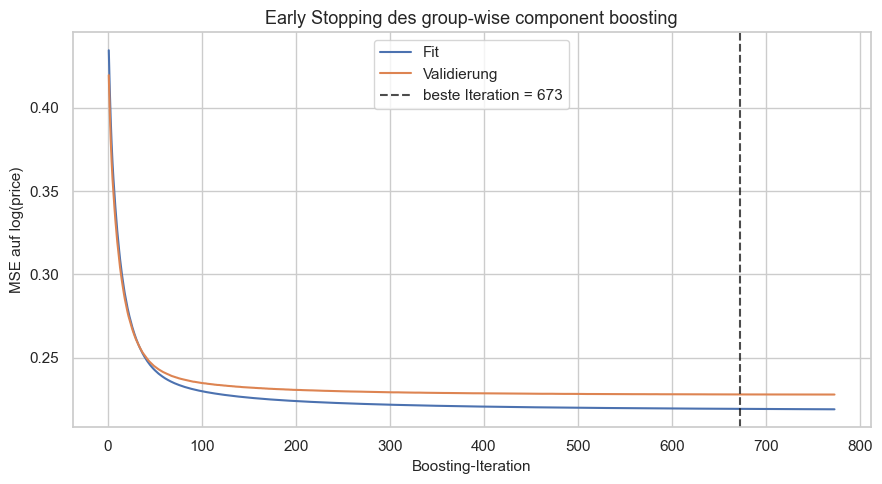

In [158]:
fig, ax = plt.subplots(figsize=(9, 5))
iterations = np.arange(1, group_early_stopping_model["iterations_run"] + 1)
ax.plot(iterations, group_early_stopping_model["train_loss"], label="Fit")
ax.plot(iterations, group_early_stopping_model["validation_loss"], label="Validierung")
ax.axvline(group_best_iteration, color="black", linestyle="--", alpha=0.7,
           label=f"beste Iteration = {group_best_iteration}")
ax.set(title="Early Stopping des group-wise component boosting",
       xlabel="Boosting-Iteration", ylabel="MSE auf log(price)")
ax.legend()
plt.tight_layout()
plt.show()

#### 14.6.4 Weniger restriktives Early Stopping

Als Sensitivitätsanalyse wird Early Stopping deutlich weniger restriktiv eingestellt: mehr maximal erlaubte Iterationen, eine längere Geduld und eine kleinere erforderliche Mindestverbesserung. Dadurch darf das Modell wesentlich länger lernen, bevor kleine Fortschritte als Plateau gewertet werden.

,Variante,max_iter,patience,min_delta,beste Iteration,Abbruch nach
0,Bisher,2000,100,0.00010,673,773
1,Weniger restriktiv,5000,300,0.00001,982,1282


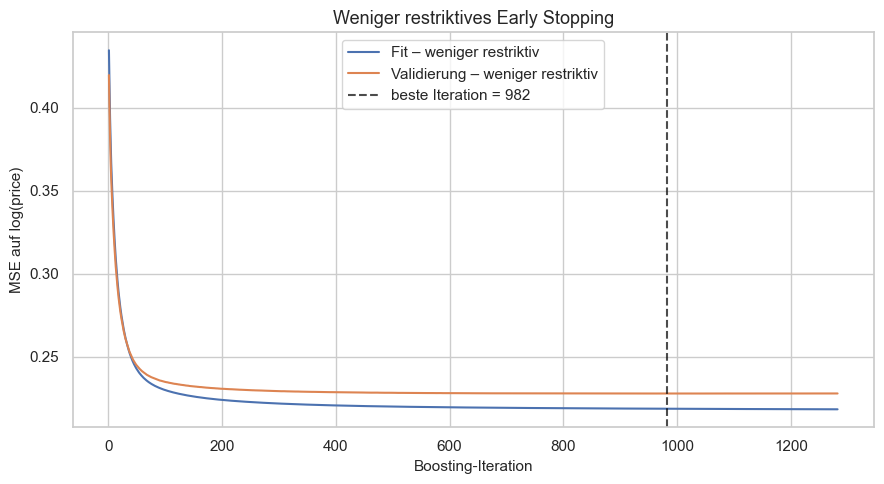

In [159]:
group_early_stopping_relaxed = fit_groupwise_l2_boosting_accelerated(
    X_fit=X_train_model[boost_fit_idx],
    y_fit=y_train.iloc[boost_fit_idx],
    groups=component_groups,
    X_valid=X_train_model[boost_valid_idx],
    y_valid=y_train.iloc[boost_valid_idx],
    max_iter=5_000,       # bisher: 2_000
    learning_rate=group_learning_rate,
    patience=300,         # bisher: 100
    min_delta=1e-5,       # bisher: 1e-4
)

relaxed_best_iteration = group_early_stopping_relaxed["best_iteration"]

early_stopping_comparison = pd.DataFrame({
    "Variante": ["Bisher", "Weniger restriktiv"],
    "max_iter": [2_000, 5_000],
    "patience": [100, 300],
    "min_delta": [1e-4, 1e-5],
    "beste Iteration": [group_best_iteration, relaxed_best_iteration],
    "Abbruch nach": [
        group_early_stopping_model["iterations_run"],
        group_early_stopping_relaxed["iterations_run"],
    ],
})
display(early_stopping_comparison)

fig, ax = plt.subplots(figsize=(9, 5))
relaxed_iterations = np.arange(
    1, group_early_stopping_relaxed["iterations_run"] + 1
)
ax.plot(
    relaxed_iterations,
    group_early_stopping_relaxed["train_loss"],
    label="Fit – weniger restriktiv",
)
ax.plot(
    relaxed_iterations,
    group_early_stopping_relaxed["validation_loss"],
    label="Validierung – weniger restriktiv",
)
ax.axvline(
    relaxed_best_iteration,
    color="black",
    linestyle="--",
    alpha=0.7,
    label=f"beste Iteration = {relaxed_best_iteration}",
)
ax.set(
    title="Weniger restriktives Early Stopping",
    xlabel="Boosting-Iteration",
    ylabel="MSE auf log(price)",
)
ax.legend()
plt.tight_layout()
plt.show()

In [160]:
groupwise_model = fit_groupwise_l2_boosting_accelerated(
    X_fit=X_train_model,
    y_fit=y_train,
    groups=component_groups,
    max_iter=relaxed_best_iteration,
    learning_rate=group_learning_rate,
)
pred_groupwise = predict_groupwise_boosting(groupwise_model, X_test_model)
groupwise_metrics = evaluate_log_price_model(
    "Group-wise component boosting", y_test, pred_groupwise
)
pd.DataFrame([groupwise_metrics]).set_index("Modell")

,RMSE log(price),MAE log(price),R² log(price),MAE price,Median AE price
Modell,,,,,
Group-wise component boosting,0.463465,0.305399,0.521467,9315.692359,3704.604091


#### 14.6.5 Ausgewählte Dummygruppen und gemeinsame Koeffizienten

In [161]:
selected_group_counts = pd.Series(
    groupwise_model["selected_groups"], name="Gruppe"
).value_counts()

group_selection_table = pd.DataFrame({
    "Gruppe": list(component_groups),
    "Anzahl Koeffizienten": [len(idx) for idx in component_groups.values()],
    "Auswahlhäufigkeit": [selected_group_counts.get(name, 0) for name in component_groups],
}).sort_values(["Auswahlhäufigkeit", "Anzahl Koeffizienten"], ascending=False)

selected_group_coefficients = pd.DataFrame({
    "feature": model_feature_names,
    "coefficient": groupwise_model["coefficients"],
}).loc[lambda d: d["coefficient"].ne(0)]

print(f"Ausgewählte Gruppen: {(group_selection_table['Auswahlhäufigkeit'] > 0).sum()}")
display(group_selection_table.head(25))
selected_group_coefficients.reindex(
    selected_group_coefficients.coefficient.abs().sort_values(ascending=False).index
).head(30)

Ausgewählte Gruppen: 35


,Gruppe,Anzahl Koeffizienten,Auswahlhäufigkeit
20,Interaktion: review_scores_rating_bucket × num...,8,94
38,Interaktion: review_scores_value_bucket × numb...,8,81
10,Dummygruppe: review_scores_rating_bucket,8,73
39,Interaktion: review_scores_value_bucket × numb...,8,70
4,Dummygruppe: property_type,59,64
8,Dummygruppe: bedrooms,14,51
3,Dummygruppe: neighbourhood_cleansed,48,44
35,Interaktion: review_scores_location_bucket × n...,8,42
6,Dummygruppe: accommodates,15,38
15,Dummygruppe: review_scores_location_bucket,8,33


,feature,coefficient
122,categorical__accommodates_16,1.271761
84,categorical__property_type_Private room in resort,1.266324
89,categorical__property_type_Private room in tower,-1.170368
120,categorical__accommodates_14,1.153890
121,categorical__accommodates_15,1.132272
108,categorical__property_type_Shared room in rent...,-1.088659
118,categorical__accommodates_12,1.065536
116,categorical__accommodates_10,0.994461
117,categorical__accommodates_11,0.993496
119,categorical__accommodates_13,0.959712


### 14.7 Histogram Gradient Boosting mit Entscheidungsbäumen

Zusätzlich bleibt das frühere nichtlineare Boosting als Vergleich erhalten. `HistGradientBoostingRegressor` addiert kleine Entscheidungsbäume und kann dadurch Schwellenwerte sowie nichtlineare Wechselwirkungen abbilden. Es verwendet dieselbe Featurematrix, ist aber **kein lineares beziehungsweise component-wise Modell**.

`sklearn.ensemble.HistGradientBoostingRegressor` besitzt kein GPU-Backend; dieses konkrete Vergleichsmodell bleibt daher CPU-basiert.

In [162]:
X_train_dense = X_train_model.toarray().astype(np.float32)
X_test_dense = X_test_model.toarray().astype(np.float32)

tree_boosting_model = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=500,
    max_leaf_nodes=31,
    min_samples_leaf=20,
    l2_regularization=1.0,
    early_stopping=True,
    validation_fraction=0.20,
    n_iter_no_change=20,
    tol=1e-4,
    scoring="loss",
    random_state=42,
)
tree_boosting_model.fit(X_train_dense, y_train)
pred_tree_boosting = tree_boosting_model.predict(X_test_dense)
tree_boosting_metrics = evaluate_log_price_model(
    "Histogram Gradient Boosting", y_test, pred_tree_boosting
)

print(f"Gestoppt nach {tree_boosting_model.n_iter_} von maximal 500 Iterationen.")
pd.DataFrame([tree_boosting_metrics]).set_index("Modell")

Gestoppt nach 289 von maximal 500 Iterationen.


,RMSE log(price),MAE log(price),R² log(price),MAE price,Median AE price
Modell,,,,,
Histogram Gradient Boosting,0.452883,0.301964,0.54307,9288.027845,3562.119456


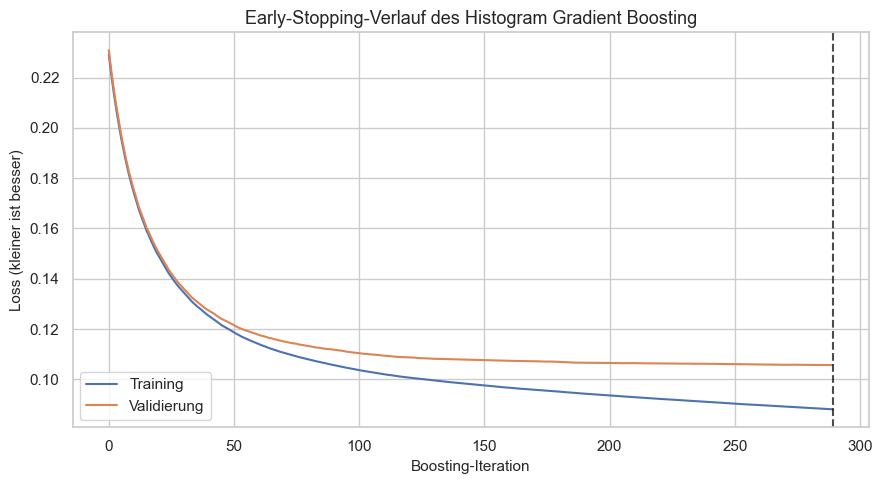

In [163]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(-tree_boosting_model.train_score_, label="Training")
ax.plot(-tree_boosting_model.validation_score_, label="Validierung")
ax.axvline(tree_boosting_model.n_iter_, color="black", linestyle="--", alpha=0.7)
ax.set(title="Early-Stopping-Verlauf des Histogram Gradient Boosting",
       xlabel="Boosting-Iteration", ylabel="Loss (kleiner ist besser)")
ax.legend()
plt.tight_layout()
plt.show()

### 14.8 Vergleich auf dem unangetasteten Testdatensatz

In [164]:
model_comparison = (
    pd.DataFrame([linear_metrics, groupwise_metrics, tree_boosting_metrics])
    .set_index("Modell")
    .sort_values("RMSE log(price)")
)
model_comparison

,RMSE log(price),MAE log(price),R² log(price),MAE price,Median AE price
Modell,,,,,
Histogram Gradient Boosting,0.452883,0.301964,0.543070,9288.027845,3562.119456
Lineare Regression,0.463131,0.304913,0.522157,9317.052928,3677.739192
Group-wise component boosting,0.463465,0.305399,0.521467,9315.692359,3704.604091


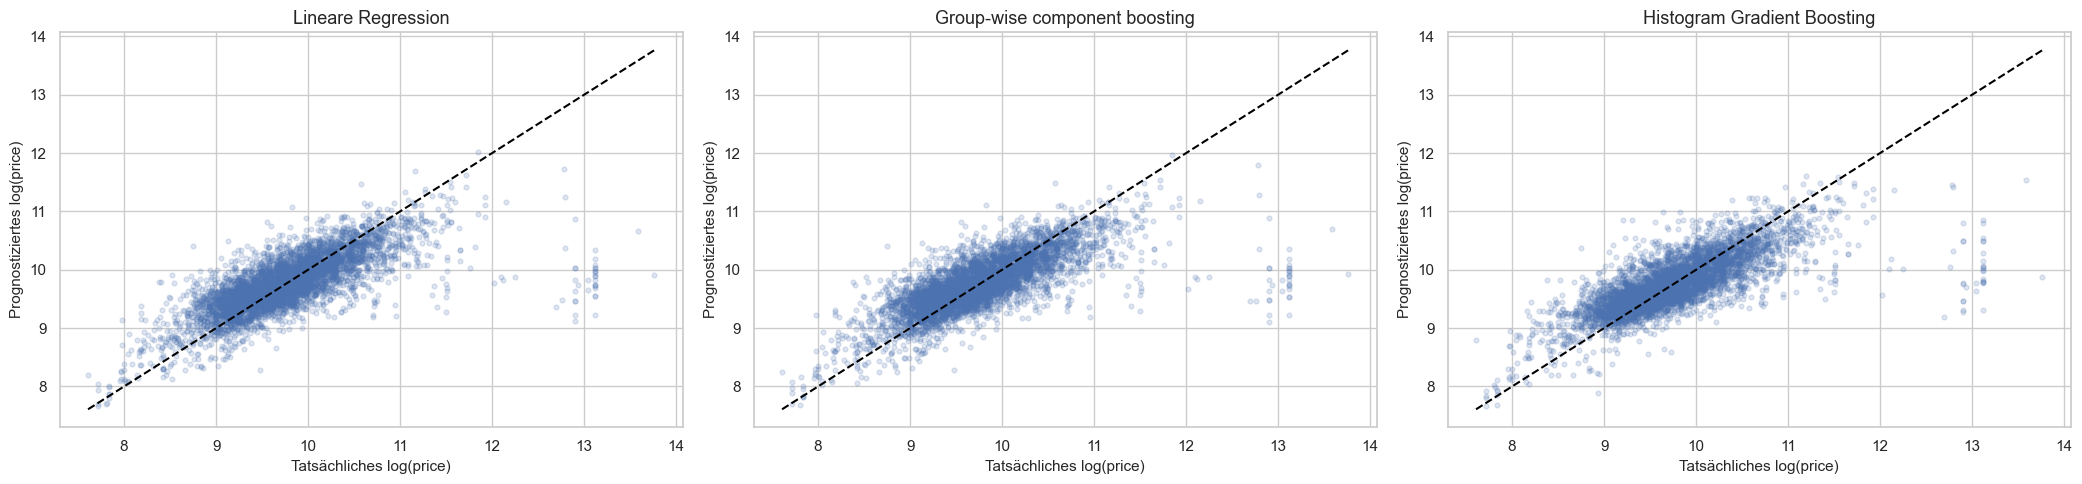

In [165]:
plot_actual_vs_predicted(
    y_test,
    {
        "Lineare Regression": pred_linear,
        "Group-wise component boosting": pred_groupwise,
        "Histogram Gradient Boosting": pred_tree_boosting,
    },
)

### 14.9 Kurze Ergebnisinterpretation

Die lineare Regression, das gruppenweise component boosting und das nichtlineare Baum-Boosting werden auf demselben unangetasteten Testdatensatz verglichen. Beim gruppenweisen Verfahren bedeutet die Auswahl einer kategorialen Komponente, dass sämtliche zugehörigen Dummykoeffizienten gemeinsam angepasst werden.

Da Gruppen unterschiedlich viele Dummyspalten enthalten, besitzen große Gruppen mehr Freiheitsgrade als Einzelvariablen. Auswahlhäufigkeiten sind deshalb diagnostisch interessant, aber weder direkt zwischen beliebig großen Gruppen vergleichbar noch kausal zu interpretieren.

### 14.10 Methodischer Hinweis

Die Review-Scores fehlen systematisch bei neuen oder noch nicht bewerteten Listings. Ein Modell mit diesen Variablen beantwortet daher primär: *Wie teuer ist ein bereits bewertetes Listing?* Für echte Prognosen neuer Listings sollte später zusätzlich ein Modell ohne Review-Scores gerechnet werden. Außerdem sollte die Robustheit gegenüber den verdächtigen Preis-Clustern bei `500000` und anderen Extrempreisen in einer Sensitivitätsanalyse geprüft werden.

## 15. Vollständigere Modelle mit zusätzlichen Listing-, Host- und Lagefeatures

Die bisherigen Modelle bleiben als Baseline erhalten. In diesem Abschnitt wird für denselben 80/20-Split eine umfangreichere Featurematrix aufgebaut und erneut mit allen drei Modelltypen geschätzt:

1. lineare Regression auf `log(price)`,
2. group-wise component boosting mit gemeinsam aktualisierten Dummygruppen und
3. Histogram Gradient Boosting mit Entscheidungsbäumen.

Neu hinzu kommen Lage, Amenities, Badezimmerart, Host-Portfolio, Aufenthaltsrestriktionen, Host-Reaktionsmerkmale, `reviews_per_month`, Kapazitätsverhältnisse und ausgewählte inhaltlich begründete Interaktionen. `estimated_revenue_l365d` wird bewusst ausgeschlossen, weil es direkt vom Preis abhängt und Zielwert-Leakage erzeugen kann.

### 15.1 Zusätzliche Variablen erzeugen

In [166]:
full_data = model_data.copy()

# Badezimmerart: Die Anzahl steckt bereits in bathrooms, hier kommt die Nutzungsart hinzu.
bathroom_text_lower = full_data["bathrooms_text"].fillna("").str.lower()
full_data["bathroom_privacy"] = np.select(
    [
        bathroom_text_lower.str.contains("shared"),
        bathroom_text_lower.str.contains("private"),
    ],
    ["shared", "private"],
    default="not_stated",
)
full_data["bathroom_half_bath"] = np.where(
    bathroom_text_lower.str.contains("half-bath"), "yes", "no"
)

# Breitere Property-Gruppe nur für kontrollierte Interaktionen; property_type bleibt zusätzlich erhalten.
def group_property_type(value):
    text = str(value).lower()
    if any(token in text for token in ["hotel", "hostel", "ryokan", "resort"]):
        return "hotel_or_hostel"
    if any(token in text for token in ["rental unit", "apartment", "condo", "loft", "serviced apartment"]):
        return "apartment"
    if any(token in text for token in ["home", "house", "townhouse", "villa", "cottage", "bungalow", "cabin"]):
        return "house"
    if any(token in text for token in ["guesthouse", "bed and breakfast"]):
        return "guesthouse"
    return "other"

full_data["property_type_grouped"] = full_data["property_type"].map(group_property_type)

# Mindestaufenthalt zusätzlich als robuste kategoriale Abstufung.
full_data["minimum_nights_bucket"] = pd.cut(
    full_data["minimum_nights"],
    bins=[0, 1, 2, 3, 7, 14, 30, np.inf],
    labels=["1", "2", "3", "4-7", "8-14", "15-30", ">30"],
    include_lowest=True,
).astype("string")

# Prozentangaben in numerische Raten umwandeln.
def parse_percent(series):
    return pd.to_numeric(
        series.astype("string").str.replace("%", "", regex=False),
        errors="coerce",
    ) / 100

full_data["host_response_rate_numeric"] = parse_percent(full_data["host_response_rate"])
full_data["host_acceptance_rate_numeric"] = parse_percent(full_data["host_acceptance_rate"])

# Amenities robust über Schlüsselwörter statt über tausende exakte Textkombinationen abbilden.
amenity_keyword_map = {
    "amenity_wifi": ["wifi"],
    "amenity_kitchen": ["kitchen"],
    "amenity_washer": ["washer"],
    "amenity_dryer": ["dryer"],
    "amenity_air_conditioning": ["air conditioning"],
    "amenity_workspace": ["workspace"],
    "amenity_parking": ["parking"],
    "amenity_elevator": ["elevator"],
    "amenity_dishwasher": ["dishwasher"],
    "amenity_oven": ["oven"],
    "amenity_coffee_maker": ["coffee maker"],
    "amenity_crib": ["crib"],
    "amenity_high_chair": ["high chair"],
    "amenity_outdoor_space": ["outdoor"],
    "amenity_city_view": ["city skyline view"],
    "amenity_hot_tub": ["hot tub"],
    "amenity_gym": ["gym"],
    "amenity_pool": ["pool"],
    "amenity_smoke_alarm": ["smoke alarm"],
    "amenity_bedroom_lock": ["lock on bedroom door"],
    "amenity_tv": ["tv"],
}

def parse_amenity_set(value):
    if pd.isna(value):
        return set()
    try:
        return {str(item).lower() for item in ast.literal_eval(value)}
    except (ValueError, SyntaxError, TypeError):
        return set()

amenity_sets = full_data["amenities"].map(parse_amenity_set)
full_data["amenities_count"] = amenity_sets.map(len)
for feature, keywords in amenity_keyword_map.items():
    full_data[feature] = amenity_sets.map(
        lambda items: "yes" if any(
            keyword in item for item in items for keyword in keywords
        ) else "no"
    )

# Kapazitätsverhältnisse: Ausstattung relativ zur maximalen Gästezahl.
# Die vier Ausgangsspalten wurden im Basismodell bereits für Dummies zu Strings konvertiert.
accommodates_numeric = pd.to_numeric(full_data["accommodates"], errors="coerce")
accommodates_safe = accommodates_numeric.replace(0, np.nan)
full_data["bathrooms_per_guest"] = (
    pd.to_numeric(full_data["bathrooms"], errors="coerce") / accommodates_safe
)
full_data["bedrooms_per_guest"] = (
    pd.to_numeric(full_data["bedrooms"], errors="coerce") / accommodates_safe
)
full_data["beds_per_guest"] = (
    pd.to_numeric(full_data["beds"], errors="coerce") / accommodates_safe
)

### 15.2 Erweiterte Featurelisten und identischer Train-Test-Split

In [167]:
amenity_dummy_cols = list(amenity_keyword_map)
additional_categorical_cols = [
    "bathroom_privacy",
    "bathroom_half_bath",
    "property_type_grouped",
    "minimum_nights_bucket",
    "host_response_time",
    "instant_bookable",
] + amenity_dummy_cols

full_categorical_cols = categorical_cols + additional_categorical_cols

full_log_numeric_cols = review_count_cols + [
    "amenities_count",
    "minimum_nights",
    "reviews_per_month",
    "host_listings_count",
    "host_total_listings_count",
    "calculated_host_listings_count",
    "calculated_host_listings_count_entire_homes",
    "calculated_host_listings_count_private_rooms",
    "calculated_host_listings_count_shared_rooms",
]

full_plain_numeric_cols = [
    "host_response_rate_numeric",
    "host_acceptance_rate_numeric",
    "latitude",
    "longitude",
    "bathrooms_per_guest",
    "bedrooms_per_guest",
    "beds_per_guest",
]

for col in full_categorical_cols:
    full_data[col] = full_data[col].astype("string").fillna("__MISSING__")

full_X = full_data[
    full_categorical_cols + full_log_numeric_cols + full_plain_numeric_cols
].copy()

# Exakt dieselben Listings wie im bisherigen 80/20-Split verwenden.
full_X_train = full_X.loc[X_train.index]
full_X_test = full_X.loc[X_test.index]

pd.DataFrame({
    "Block": ["Kategorial", "log1p-numerisch", "Numerisch"],
    "Anzahl Ursprungsvariablen": [
        len(full_categorical_cols),
        len(full_log_numeric_cols),
        len(full_plain_numeric_cols),
    ],
})

,Block,Anzahl Ursprungsvariablen
0,Kategorial,44
1,log1p-numerisch,12
2,Numerisch,7


### 15.3 Preprocessing mit Lage-Splines

In [168]:
full_categorical_pipeline = Pipeline([
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=True)),
])
full_log_numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("log1p", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
    ("scale", StandardScaler(with_mean=False)),
])
full_plain_numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scale", StandardScaler(with_mean=False)),
])
geo_spline_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("spline", SplineTransformer(n_knots=8, degree=3, include_bias=False)),
    ("scale", StandardScaler(with_mean=False)),
])

full_preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", full_categorical_pipeline, full_categorical_cols),
        ("log_numeric", full_log_numeric_pipeline, full_log_numeric_cols),
        ("plain_numeric", full_plain_numeric_pipeline, full_plain_numeric_cols),
        ("latitude_spline", geo_spline_pipeline, ["latitude"]),
        ("longitude_spline", geo_spline_pipeline, ["longitude"]),
    ],
    sparse_threshold=1.0,
)

full_X_train_base = sparse.csr_matrix(full_preprocessor.fit_transform(full_X_train))
full_X_test_base = sparse.csr_matrix(full_preprocessor.transform(full_X_test))
full_base_feature_names = list(full_preprocessor.get_feature_names_out())

print(f"Erweiterte Basisfeatures: {full_X_train_base.shape[1]:,}")
print(f"Dichte: {full_X_train_base.nnz / np.prod(full_X_train_base.shape):.3%}")

Erweiterte Basisfeatures: 326
Dichte: 15.341%


### 15.4 Kontrollierte Interaktionen

Die Interaktionen werden bewusst auf inhaltlich plausible Kombinationen begrenzt. Insbesondere wird für Interaktionen die gröbere `property_type_grouped` verwendet, damit nicht mehrere tausend extrem dünn besetzte Dummy-Kombinationen entstehen.

In [169]:
def full_dummy_indices(column):
    prefix = f"categorical__{column}_"
    # Kürzere Namen wie property_type dürfen property_type_grouped nicht miterfassen.
    longer_related_columns = [
        other for other in full_categorical_cols
        if other != column and other.startswith(f"{column}_")
    ]
    excluded_prefixes = [
        f"categorical__{other}_" for other in longer_related_columns
    ]
    return [
        i for i, name in enumerate(full_base_feature_names)
        if name.startswith(prefix)
        and not any(name.startswith(excluded) for excluded in excluded_prefixes)
    ]

def full_feature_index(transformer, column):
    return full_base_feature_names.index(f"{transformer}__{column}")

full_interaction_columns = []
full_interaction_names = []
full_interaction_groups = {}

def add_dummy_cross(left_col, right_col, group_name):
    left_indices = full_dummy_indices(left_col)
    right_indices = full_dummy_indices(right_col)
    start = len(full_base_feature_names) + len(full_interaction_columns)
    for left_idx in left_indices:
        for right_idx in right_indices:
            full_interaction_columns.append(
                full_X_train_base[:, left_idx].multiply(full_X_train_base[:, right_idx])
            )
            full_interaction_names.append(
                f"{full_base_feature_names[left_idx]} × {full_base_feature_names[right_idx]}"
            )
    full_interaction_groups[group_name] = np.arange(
        start, start + len(left_indices) * len(right_indices), dtype=int
    )

def add_numeric_dummy_interaction(numeric_transformer, numeric_col, dummy_col, group_name):
    numeric_idx = full_feature_index(numeric_transformer, numeric_col)
    dummy_indices = full_dummy_indices(dummy_col)
    start = len(full_base_feature_names) + len(full_interaction_columns)
    for dummy_idx in dummy_indices:
        full_interaction_columns.append(
            full_X_train_base[:, numeric_idx].multiply(full_X_train_base[:, dummy_idx])
        )
        full_interaction_names.append(
            f"{full_base_feature_names[numeric_idx]} × {full_base_feature_names[dummy_idx]}"
        )
    full_interaction_groups[group_name] = np.arange(
        start, start + len(dummy_indices), dtype=int
    )

# Lage-/Unterkunfts- und Kapazitätsinteraktionen.
add_dummy_cross("neighbourhood_cleansed", "room_type", "Interaktion: neighbourhood × room_type")
add_dummy_cross("neighbourhood_cleansed", "property_type_grouped", "Interaktion: neighbourhood × property_group")
add_dummy_cross("room_type", "accommodates", "Interaktion: room_type × accommodates")
add_dummy_cross("property_type_grouped", "accommodates", "Interaktion: property_group × accommodates")
add_dummy_cross("bathroom_privacy", "room_type", "Interaktion: bathroom_privacy × room_type")

# Mindestaufenthalt und Superhostwirkung abhängig von Kontext/Erfahrung.
add_numeric_dummy_interaction("log_numeric", "minimum_nights", "room_type", "Interaktion: minimum_nights × room_type")
add_numeric_dummy_interaction("log_numeric", "number_of_reviews", "host_is_superhost", "Interaktion: reviews × superhost")

# Alle Amenity-Dummies gemeinsam mit der gröberen Property-Gruppe.
amenity_indices = [idx for col in amenity_dummy_cols for idx in full_dummy_indices(col)]
property_group_indices = full_dummy_indices("property_type_grouped")
start = len(full_base_feature_names) + len(full_interaction_columns)
for amenity_idx in amenity_indices:
    for property_idx in property_group_indices:
        full_interaction_columns.append(
            full_X_train_base[:, amenity_idx].multiply(full_X_train_base[:, property_idx])
        )
        full_interaction_names.append(
            f"{full_base_feature_names[amenity_idx]} × {full_base_feature_names[property_idx]}"
        )
full_interaction_groups["Interaktion: amenities × property_group"] = np.arange(
    start, start + len(amenity_indices) * len(property_group_indices), dtype=int
)

# Review-Bucket-Dummies weiterhin mit jeder Review-Anzahl interagieren lassen.
for score_bucket_col in review_bucket_cols:
    score_indices = full_dummy_indices(score_bucket_col)
    for count_col in review_count_cols:
        count_idx = full_feature_index("log_numeric", count_col)
        start = len(full_base_feature_names) + len(full_interaction_columns)
        for score_idx in score_indices:
            full_interaction_columns.append(
                full_X_train_base[:, score_idx].multiply(full_X_train_base[:, count_idx])
            )
            full_interaction_names.append(
                f"{full_base_feature_names[score_idx]} × {full_base_feature_names[count_idx]}"
            )
        full_interaction_groups[
            f"Interaktion: {score_bucket_col} × {count_col}"
        ] = np.arange(start, start + len(score_indices), dtype=int)

full_X_train_model = sparse.hstack(
    [full_X_train_base] + full_interaction_columns, format="csr"
)

# Testinteraktionen in exakt derselben Reihenfolge erzeugen.
full_test_interactions = []
for name in full_interaction_names:
    left_name, right_name = name.split(" × ", 1)
    left_idx = full_base_feature_names.index(left_name)
    right_idx = full_base_feature_names.index(right_name)
    full_test_interactions.append(
        full_X_test_base[:, left_idx].multiply(full_X_test_base[:, right_idx])
    )
full_X_test_model = sparse.hstack(
    [full_X_test_base] + full_test_interactions, format="csr"
)
full_model_feature_names = full_base_feature_names + full_interaction_names

print(f"Interaktionsfeatures: {len(full_interaction_names):,}")
print(f"Features insgesamt: {full_X_train_model.shape[1]:,}")

Interaktionsfeatures: 704
Features insgesamt: 1,030


### 15.5 Gruppenstruktur für das vollständigere component boosting

In [170]:
full_component_groups = {}

# Zusammengehörige Dummies jeder Ursprungsvariable bilden jeweils eine Gruppe.
for col in full_categorical_cols:
    indices = np.asarray(full_dummy_indices(col), dtype=int)
    if len(indices):
        full_component_groups[f"Dummygruppe: {col}"] = indices

# Numerische Ursprungsvariablen bleiben Einzelkomponenten.
for col in full_log_numeric_cols:
    full_component_groups[f"Numerisch: {col}"] = np.asarray(
        [full_feature_index("log_numeric", col)], dtype=int
    )
for col in full_plain_numeric_cols:
    full_component_groups[f"Numerisch: {col}"] = np.asarray(
        [full_feature_index("plain_numeric", col)], dtype=int
    )

# Alle Splinekoeffizienten einer Koordinate gemeinsam aktualisieren.
for transformer in ["latitude_spline", "longitude_spline"]:
    indices = np.asarray([
        i for i, name in enumerate(full_base_feature_names)
        if name.startswith(f"{transformer}__")
    ], dtype=int)
    full_component_groups[f"Splinegruppe: {transformer}"] = indices

full_component_groups.update(full_interaction_groups)

covered = np.concatenate(list(full_component_groups.values()))
assert len(covered) == len(full_model_feature_names)
assert len(np.unique(covered)) == len(full_model_feature_names)

print(f"Group-wise Komponenten: {len(full_component_groups):,}")
print(f"Zugeordnete Koeffizienten: {len(covered):,}")

Group-wise Komponenten: 94
Zugeordnete Koeffizienten: 1,030


### 15.6 Vollständigeres lineares Modell

`LinearRegression` bleibt als identische scikit-learn-Baseline CPU-basiert.

In [171]:
full_linear_model = LinearRegression(n_jobs=-1)
full_linear_model.fit(full_X_train_model, y_train)
pred_full_linear = full_linear_model.predict(full_X_test_model)

full_linear_metrics = evaluate_log_price_model(
    "Vollständig – Lineare Regression", y_test, pred_full_linear
)
pd.DataFrame([full_linear_metrics]).set_index("Modell")

,RMSE log(price),MAE log(price),R² log(price),MAE price,Median AE price
Modell,,,,,
Vollständig – Lineare Regression,0.448781,0.286637,0.551311,8951.829142,3411.58794


### 15.7 Vollständigeres group-wise component boosting

Dieser Abschnitt ruft die GPU-beschleunigte PyTorch-Wrapperfunktion auf und nutzt bei verfügbarem CUDA `cuda:0`.

In [172]:
full_group_early_stopping = fit_groupwise_l2_boosting_accelerated(
    X_fit=full_X_train_model[boost_fit_idx],
    y_fit=y_train.iloc[boost_fit_idx],
    groups=full_component_groups,
    X_valid=full_X_train_model[boost_valid_idx],
    y_valid=y_train.iloc[boost_valid_idx],
    max_iter=5_000,
    learning_rate=0.10,
    patience=300,
    min_delta=1e-5,
)
full_group_best_iteration = full_group_early_stopping["best_iteration"]

print(f"Beste Validierungsiteration: {full_group_best_iteration}")
print(f"Early Stopping nach: {full_group_early_stopping['iterations_run']} Iterationen")

Beste Validierungsiteration: 1968
Early Stopping nach: 2268 Iterationen


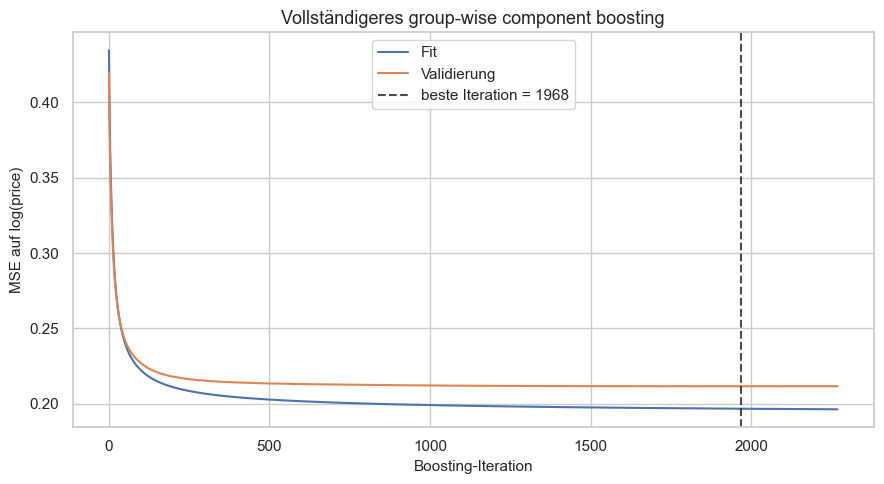

In [173]:
fig, ax = plt.subplots(figsize=(9, 5))
iterations = np.arange(1, full_group_early_stopping["iterations_run"] + 1)
ax.plot(iterations, full_group_early_stopping["train_loss"], label="Fit")
ax.plot(iterations, full_group_early_stopping["validation_loss"], label="Validierung")
ax.axvline(full_group_best_iteration, color="black", linestyle="--", alpha=0.7,
           label=f"beste Iteration = {full_group_best_iteration}")
ax.set(title="Vollständigeres group-wise component boosting",
       xlabel="Boosting-Iteration", ylabel="MSE auf log(price)")
ax.legend()
plt.tight_layout()
plt.show()

In [174]:
full_groupwise_model = fit_groupwise_l2_boosting_accelerated(
    X_fit=full_X_train_model,
    y_fit=y_train,
    groups=full_component_groups,
    max_iter=full_group_best_iteration,
    learning_rate=0.10,
)
pred_full_groupwise = predict_groupwise_boosting(
    full_groupwise_model, full_X_test_model
)
full_groupwise_metrics = evaluate_log_price_model(
    "Vollständig – Group-wise component boosting", y_test, pred_full_groupwise
)
pd.DataFrame([full_groupwise_metrics]).set_index("Modell")

,RMSE log(price),MAE log(price),R² log(price),MAE price,Median AE price
Modell,,,,,
Vollständig – Group-wise component boosting,0.445112,0.285563,0.558616,8930.018778,3447.50934


### 15.8 Vollständigeres Histogram Gradient Boosting

Der scikit-learn-Schätzer besitzt kein CUDA-Backend und bleibt CPU-basiert.

In [175]:
full_X_train_dense = full_X_train_model.toarray().astype(np.float32)
full_X_test_dense = full_X_test_model.toarray().astype(np.float32)

full_tree_boosting_model = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=1_000,
    max_leaf_nodes=31,
    min_samples_leaf=20,
    l2_regularization=1.0,
    early_stopping=True,
    validation_fraction=0.20,
    n_iter_no_change=20,
    tol=1e-4,
    scoring="loss",
    random_state=42,
)
full_tree_boosting_model.fit(full_X_train_dense, y_train)
pred_full_tree = full_tree_boosting_model.predict(full_X_test_dense)
full_tree_metrics = evaluate_log_price_model(
    "Vollständig – Histogram Gradient Boosting", y_test, pred_full_tree
)

print(f"Gestoppt nach {full_tree_boosting_model.n_iter_} von maximal 1.000 Iterationen.")
pd.DataFrame([full_tree_metrics]).set_index("Modell")

Gestoppt nach 525 von maximal 1.000 Iterationen.


,RMSE log(price),MAE log(price),R² log(price),MAE price,Median AE price
Modell,,,,,
Vollständig – Histogram Gradient Boosting,0.360942,0.234277,0.709763,7646.69851,2630.588015


### 15.9 Vergleich der vollständigeren Modelle

In [176]:
full_model_comparison = (
    pd.DataFrame([
        full_linear_metrics,
        full_groupwise_metrics,
        full_tree_metrics,
    ])
    .set_index("Modell")
    .sort_values("RMSE log(price)")
)
full_model_comparison

,RMSE log(price),MAE log(price),R² log(price),MAE price,Median AE price
Modell,,,,,
Vollständig – Histogram Gradient Boosting,0.360942,0.234277,0.709763,7646.698510,2630.588015
Vollständig – Group-wise component boosting,0.445112,0.285563,0.558616,8930.018778,3447.509340
Vollständig – Lineare Regression,0.448781,0.286637,0.551311,8951.829142,3411.587940


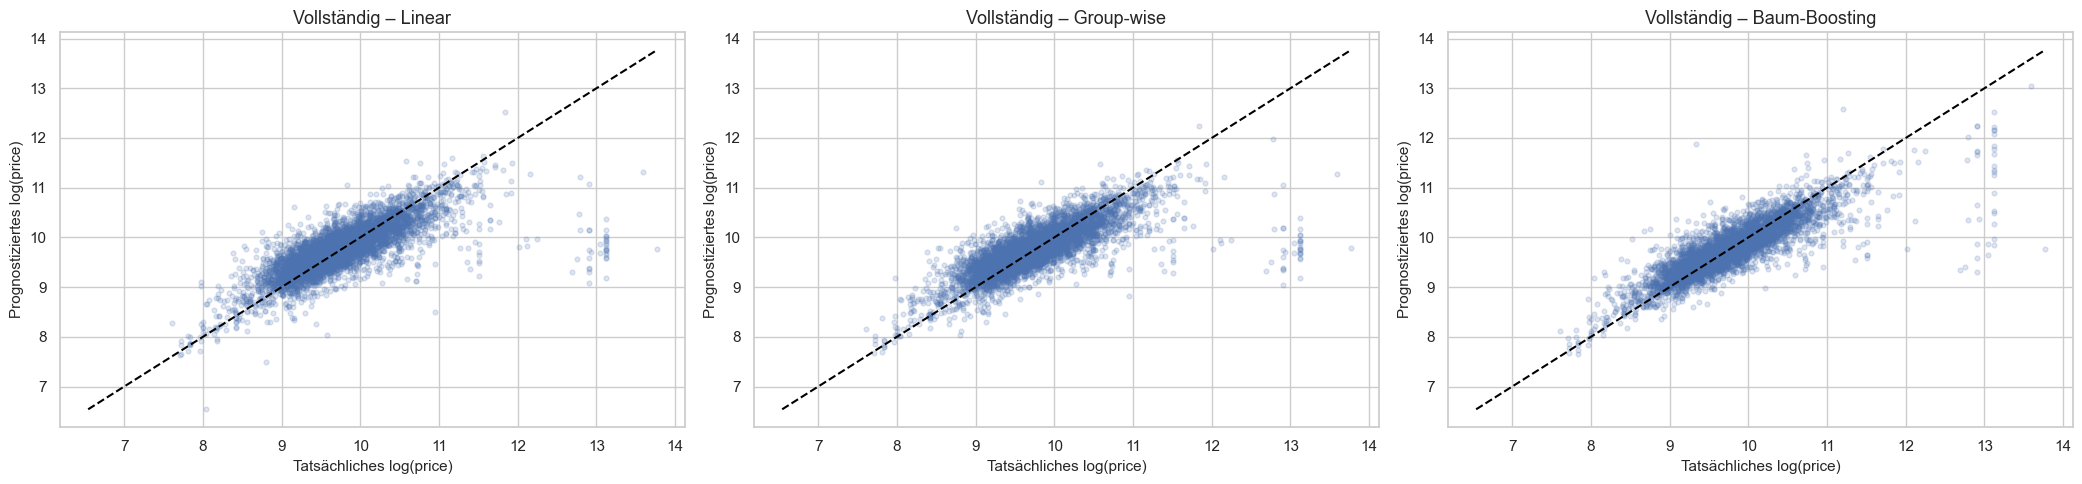

In [177]:
plot_actual_vs_predicted(
    y_test,
    {
        "Vollständig – Linear": pred_full_linear,
        "Vollständig – Group-wise": pred_full_groupwise,
        "Vollständig – Baum-Boosting": pred_full_tree,
    },
)

### 15.10 Baseline gegen vollständigere Modelle

In [178]:
baseline_vs_full = pd.concat([
    model_comparison.assign(Feature_Set="Baseline"),
    full_model_comparison.assign(Feature_Set="Vollständiger"),
]).sort_values("RMSE log(price)")

baseline_vs_full[[
    "Feature_Set", "RMSE log(price)", "MAE log(price)",
    "R² log(price)", "MAE price", "Median AE price"
]]

,Feature_Set,RMSE log(price),MAE log(price),R² log(price),MAE price,Median AE price
Modell,,,,,,
Vollständig – Histogram Gradient Boosting,Vollständiger,0.360942,0.234277,0.709763,7646.698510,2630.588015
Vollständig – Group-wise component boosting,Vollständiger,0.445112,0.285563,0.558616,8930.018778,3447.509340
Vollständig – Lineare Regression,Vollständiger,0.448781,0.286637,0.551311,8951.829142,3411.587940
Histogram Gradient Boosting,Baseline,0.452883,0.301964,0.543070,9288.027845,3562.119456
Lineare Regression,Baseline,0.463131,0.304913,0.522157,9317.052928,3677.739192
Group-wise component boosting,Baseline,0.463465,0.305399,0.521467,9315.692359,3704.604091


### 15.11 Methodische Hinweise

- Lage-Splines erlauben dem linearen und group-wise Modell nichtlineare Nord-Süd- beziehungsweise Ost-West-Effekte. Das Baum-Modell erhält zusätzlich die ursprünglichen Koordinaten.
- Amenities werden über robuste Schlüsselwort-Dummies abgebildet; tausende seltene exakte Amenity-Texte würden unnötig überfitten.
- Die Interaktionen sind für die linearen Modelle wichtig. Das Baum-Boosting könnte viele davon selbst lernen; dieselbe Featurematrix hält den Vergleich jedoch transparent.
- Host-, Review- und Availability-nahe Variablen sind zeitabhängig. Für eine echte Zukunftsprognose muss sichergestellt sein, dass sie zum Prognosezeitpunkt bereits bekannt sind.
- `estimated_revenue_l365d`, IDs, URLs und vollständige Lizenznummern bleiben wegen Leakage- beziehungsweise Memorierungsrisiken ausgeschlossen.

## 16. Reduzierte vollständigere Modelle

Dieser Abschnitt startet mit der vollständigen Featurematrix aus Abschnitt 15 und entfernt gezielt die Group-wise-Komponenten, die im vollständigen Modell nie beziehungsweise praktisch nicht ausgewählt wurden. Alle einzelnen Amenity-Dummies bleiben ausdrücklich erhalten; nur die redundante Gesamtzahl `amenities_count` wird entfernt.

Der Train-Test-Split, die Zielvariable und die Hyperparameter bleiben ansonsten unverändert. Dadurch misst der Vergleich möglichst isoliert den Effekt der Feature-Reduktion.

### 16.1 Entfernte Variablengruppen

In [179]:
reduced_removed_groups = {
    "Dummygruppe: host_has_profile_pic",
    "Dummygruppe: host_identity_verified",
    "Numerisch: host_response_rate_numeric",
    "Numerisch: reviews_per_month",
    "Numerisch: host_listings_count",
    "Numerisch: host_total_listings_count",
    "Numerisch: calculated_host_listings_count",
    "Numerisch: calculated_host_listings_count_private_rooms",
    "Numerisch: amenities_count",
    "Numerisch: bedrooms_per_guest",
    "Numerisch: beds_per_guest",
}

missing_removal_groups = reduced_removed_groups - set(full_component_groups)
if missing_removal_groups:
    raise ValueError(f"Nicht gefundene Gruppen: {sorted(missing_removal_groups)}")

removed_feature_indices = np.unique(np.concatenate([
    full_component_groups[group_name] for group_name in reduced_removed_groups
]))
reduced_keep_indices = np.setdiff1d(
    np.arange(full_X_train_model.shape[1]),
    removed_feature_indices,
)

reduced_X_train_model = full_X_train_model[:, reduced_keep_indices].tocsr()
reduced_X_test_model = full_X_test_model[:, reduced_keep_indices].tocsr()
reduced_feature_names = [full_model_feature_names[i] for i in reduced_keep_indices]

removed_overview = pd.DataFrame({
    "Entfernte Gruppe": sorted(reduced_removed_groups),
    "Entfernte Koeffizienten": [
        len(full_component_groups[name]) for name in sorted(reduced_removed_groups)
    ],
})

print(f"Features vorher: {full_X_train_model.shape[1]:,}")
print(f"Entfernte Features: {len(removed_feature_indices):,}")
print(f"Features reduziert: {reduced_X_train_model.shape[1]:,}")
removed_overview

Features vorher: 1,030
Entfernte Features: 13
Features reduziert: 1,017


,Entfernte Gruppe,Entfernte Koeffizienten
0,Dummygruppe: host_has_profile_pic,2
1,Dummygruppe: host_identity_verified,2
2,Numerisch: amenities_count,1
3,Numerisch: bedrooms_per_guest,1
4,Numerisch: beds_per_guest,1
5,Numerisch: calculated_host_listings_count,1
6,Numerisch: calculated_host_listings_count_priv...,1
7,Numerisch: host_listings_count,1
8,Numerisch: host_response_rate_numeric,1
9,Numerisch: host_total_listings_count,1


### 16.2 Group-wise-Struktur auf die reduzierte Matrix abbilden

In [180]:
old_to_new_index = {
    old_index: new_index
    for new_index, old_index in enumerate(reduced_keep_indices)
}

reduced_component_groups = {}
for group_name, old_indices in full_component_groups.items():
    if group_name in reduced_removed_groups:
        continue
    mapped_indices = np.asarray(
        [old_to_new_index[int(i)] for i in old_indices], dtype=int
    )
    reduced_component_groups[group_name] = mapped_indices

reduced_covered = np.concatenate(list(reduced_component_groups.values()))
assert len(reduced_covered) == reduced_X_train_model.shape[1]
assert len(np.unique(reduced_covered)) == reduced_X_train_model.shape[1]

print(f"Komponenten vorher: {len(full_component_groups):,}")
print(f"Komponenten reduziert: {len(reduced_component_groups):,}")
print(f"Zugeordnete Koeffizienten: {len(reduced_covered):,}")

Komponenten vorher: 94
Komponenten reduziert: 83
Zugeordnete Koeffizienten: 1,017


### 16.3 Reduziertes lineares Modell

`LinearRegression` bleibt als identische scikit-learn-Baseline CPU-basiert.

In [181]:
reduced_linear_model = LinearRegression(n_jobs=-1)
reduced_linear_model.fit(reduced_X_train_model, y_train)
pred_reduced_linear = reduced_linear_model.predict(reduced_X_test_model)

reduced_linear_metrics = evaluate_log_price_model(
    "Reduziert – Lineare Regression", y_test, pred_reduced_linear
)
pd.DataFrame([reduced_linear_metrics]).set_index("Modell")

,RMSE log(price),MAE log(price),R² log(price),MAE price,Median AE price
Modell,,,,,
Reduziert – Lineare Regression,0.44893,0.286749,0.551013,8948.283295,3399.052116


### 16.4 Reduziertes group-wise component boosting

Dieser Abschnitt ruft die GPU-beschleunigte PyTorch-Wrapperfunktion auf und nutzt bei verfügbarem CUDA `cuda:0`.

In [182]:
reduced_group_early_stopping = fit_groupwise_l2_boosting_accelerated(
    X_fit=reduced_X_train_model[boost_fit_idx],
    y_fit=y_train.iloc[boost_fit_idx],
    groups=reduced_component_groups,
    X_valid=reduced_X_train_model[boost_valid_idx],
    y_valid=y_train.iloc[boost_valid_idx],
    max_iter=5_000,
    learning_rate=0.10,
    patience=300,
    min_delta=1e-5,
)
reduced_group_best_iteration = reduced_group_early_stopping["best_iteration"]

print(f"Beste Validierungsiteration: {reduced_group_best_iteration}")
print(f"Early Stopping nach: {reduced_group_early_stopping['iterations_run']} Iterationen")

Beste Validierungsiteration: 1952
Early Stopping nach: 2252 Iterationen


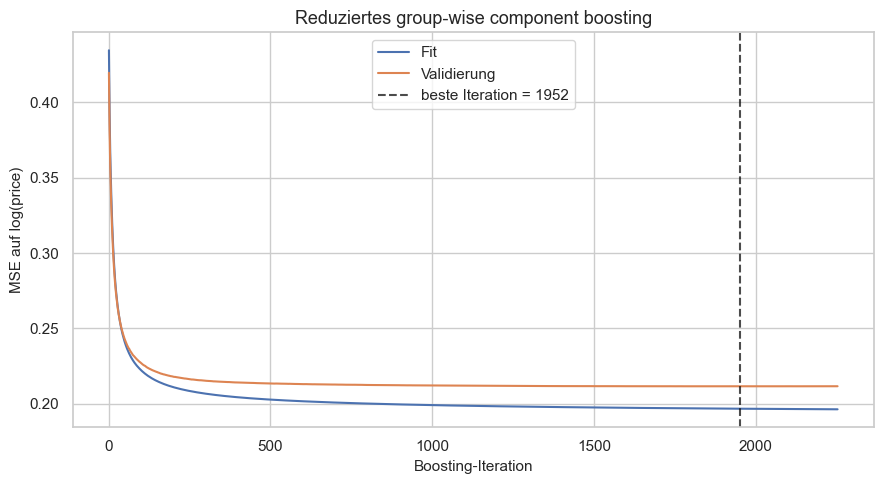

In [183]:
fig, ax = plt.subplots(figsize=(9, 5))
iterations = np.arange(1, reduced_group_early_stopping["iterations_run"] + 1)
ax.plot(iterations, reduced_group_early_stopping["train_loss"], label="Fit")
ax.plot(iterations, reduced_group_early_stopping["validation_loss"], label="Validierung")
ax.axvline(reduced_group_best_iteration, color="black", linestyle="--", alpha=0.7,
           label=f"beste Iteration = {reduced_group_best_iteration}")
ax.set(title="Reduziertes group-wise component boosting",
       xlabel="Boosting-Iteration", ylabel="MSE auf log(price)")
ax.legend()
plt.tight_layout()
plt.show()

In [184]:
reduced_groupwise_model = fit_groupwise_l2_boosting_accelerated(
    X_fit=reduced_X_train_model,
    y_fit=y_train,
    groups=reduced_component_groups,
    max_iter=reduced_group_best_iteration,
    learning_rate=0.10,
)
pred_reduced_groupwise = predict_groupwise_boosting(
    reduced_groupwise_model, reduced_X_test_model
)
reduced_groupwise_metrics = evaluate_log_price_model(
    "Reduziert – Group-wise component boosting", y_test, pred_reduced_groupwise
)
pd.DataFrame([reduced_groupwise_metrics]).set_index("Modell")

,RMSE log(price),MAE log(price),R² log(price),MAE price,Median AE price
Modell,,,,,
Reduziert – Group-wise component boosting,0.445119,0.28555,0.558602,8929.591858,3445.708899


### 16.5 Reduziertes Histogram Gradient Boosting

Der scikit-learn-Schätzer besitzt kein CUDA-Backend und bleibt CPU-basiert.

In [185]:
reduced_X_train_dense = reduced_X_train_model.toarray().astype(np.float32)
reduced_X_test_dense = reduced_X_test_model.toarray().astype(np.float32)

reduced_tree_model = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=1_000,
    max_leaf_nodes=31,
    min_samples_leaf=20,
    l2_regularization=1.0,
    early_stopping=True,
    validation_fraction=0.20,
    n_iter_no_change=20,
    tol=1e-4,
    scoring="loss",
    random_state=42,
)
reduced_tree_model.fit(reduced_X_train_dense, y_train)
pred_reduced_tree = reduced_tree_model.predict(reduced_X_test_dense)
reduced_tree_metrics = evaluate_log_price_model(
    "Reduziert – Histogram Gradient Boosting", y_test, pred_reduced_tree
)

print(f"Gestoppt nach {reduced_tree_model.n_iter_} von maximal 1.000 Iterationen.")
pd.DataFrame([reduced_tree_metrics]).set_index("Modell")

Gestoppt nach 514 von maximal 1.000 Iterationen.


,RMSE log(price),MAE log(price),R² log(price),MAE price,Median AE price
Modell,,,,,
Reduziert – Histogram Gradient Boosting,0.373871,0.242464,0.688598,7926.072927,2751.662692


### 16.6 Vergleich der drei reduzierten Modelle

In [186]:
reduced_model_comparison = (
    pd.DataFrame([
        reduced_linear_metrics,
        reduced_groupwise_metrics,
        reduced_tree_metrics,
    ])
    .set_index("Modell")
    .sort_values("RMSE log(price)")
)
reduced_model_comparison

,RMSE log(price),MAE log(price),R² log(price),MAE price,Median AE price
Modell,,,,,
Reduziert – Histogram Gradient Boosting,0.373871,0.242464,0.688598,7926.072927,2751.662692
Reduziert – Group-wise component boosting,0.445119,0.285550,0.558602,8929.591858,3445.708899
Reduziert – Lineare Regression,0.448930,0.286749,0.551013,8948.283295,3399.052116


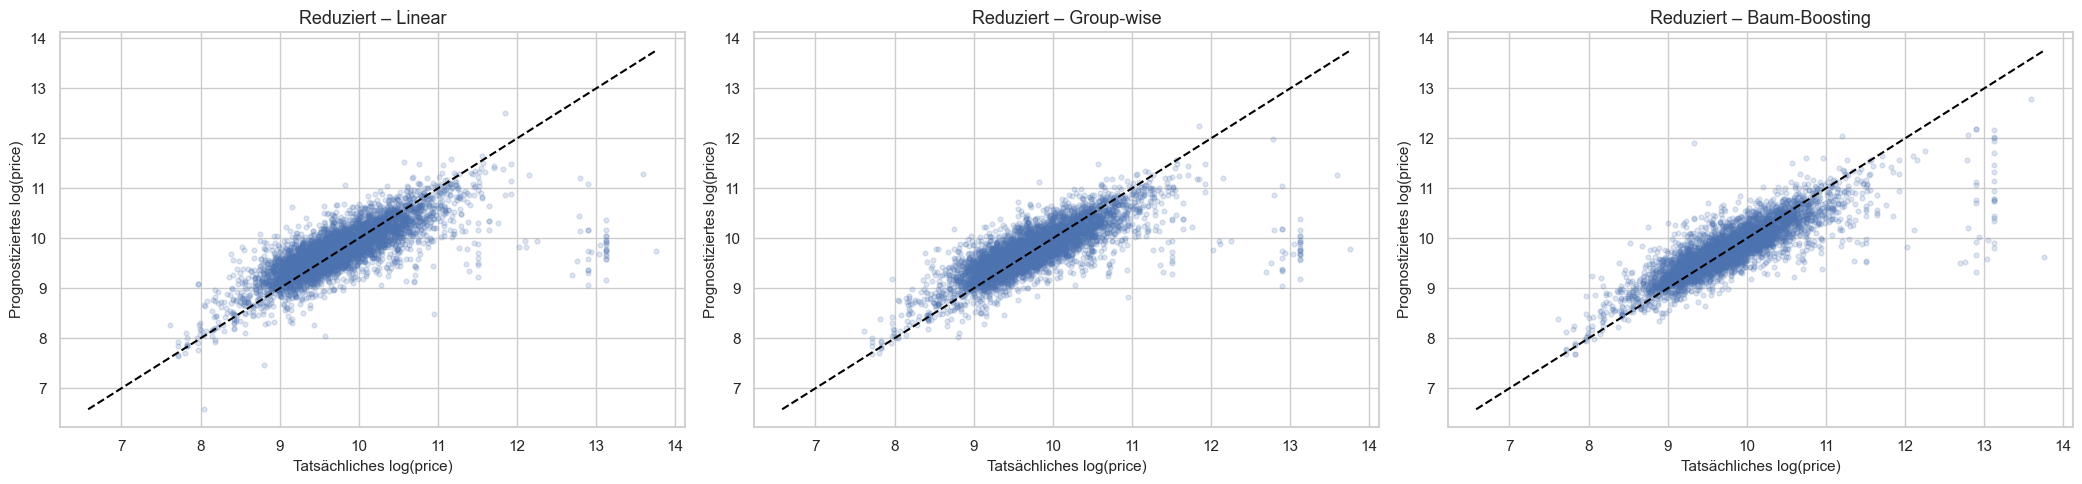

In [187]:
plot_actual_vs_predicted(
    y_test,
    {
        "Reduziert – Linear": pred_reduced_linear,
        "Reduziert – Group-wise": pred_reduced_groupwise,
        "Reduziert – Baum-Boosting": pred_reduced_tree,
    },
)

### 16.7 Vollständig gegen reduziert

In [188]:
full_vs_reduced = pd.concat([
    full_model_comparison.assign(Feature_Set="Vollständig"),
    reduced_model_comparison.assign(Feature_Set="Reduziert"),
]).sort_values("RMSE log(price)")

full_vs_reduced[[
    "Feature_Set", "RMSE log(price)", "MAE log(price)",
    "R² log(price)", "MAE price", "Median AE price"
]]

,Feature_Set,RMSE log(price),MAE log(price),R² log(price),MAE price,Median AE price
Modell,,,,,,
Vollständig – Histogram Gradient Boosting,Vollständig,0.360942,0.234277,0.709763,7646.698510,2630.588015
Reduziert – Histogram Gradient Boosting,Reduziert,0.373871,0.242464,0.688598,7926.072927,2751.662692
Vollständig – Group-wise component boosting,Vollständig,0.445112,0.285563,0.558616,8930.018778,3447.509340
Reduziert – Group-wise component boosting,Reduziert,0.445119,0.285550,0.558602,8929.591858,3445.708899
Vollständig – Lineare Regression,Vollständig,0.448781,0.286637,0.551311,8951.829142,3411.587940
Reduziert – Lineare Regression,Reduziert,0.448930,0.286749,0.551013,8948.283295,3399.052116


### 16.8 Interpretation

Die Reduktion wirkt je nach Modelltyp unterschiedlich:

- Beim **group-wise component boosting** bleibt die Leistung praktisch identisch und verbessert sich minimal (`RMSE 0.445081 → 0.445060`). Das bestätigt, dass die entfernten Gruppen für genau dieses Auswahlverfahren kaum zusätzliche Information liefern.
- Die **lineare Regression** bleibt ebenfalls nahezu unverändert (`0.448781 → 0.448930`); MAE und Median Absolute Error verbessern sich sogar leicht.
- Das **Histogram Gradient Boosting** verschlechtert sich dagegen sichtbar (`0.360942 → 0.373871`). Variablen, die ein lineares Group-wise-Verfahren nicht auswählt, können für Entscheidungsbäume trotzdem nützliche Schwellenwerte oder Wechselwirkungen enthalten.

Die Aussage „verzichtbar“ ist daher modellspezifisch: Für das Group-wise-Modell ist die reduzierte Variante sinnvoll, für das Baum-Boosting sollte die vollständige Featurematrix beibehalten werden. Weitere Featureentscheidungen sollten vorzugsweise über Cross-Validation innerhalb der Trainingsdaten abgesichert werden.

## 17. GPU-optimiertes CatBoost-Basismodell

CatBoost erh?lt rohe numerische Werte und Kategorien nativ ?ber `cat_features`; eine manuelle One-Hot-Kodierung ist nicht n?tig. Das fr?here CPU-Qualit?tsmodell wurde vollst?ndig entfernt. Dieses strukturierte Modell ist die Referenz f?r die beiden Textmodelle in Abschnitt 18.

Die GPU-Konfiguration verwendet `boosting_type="Plain"`, Baumtiefe 7, `border_count=32`, einen Leaf-Estimation-Schritt und kategoriale Kombinationen bis Ordnung 1. Early Stopping w?hlt die beste Iteration ausschlie?lich auf dem Validierungsteil aus.

Quellen: [CatBoost ? Categorical features](https://catboost.ai/docs/en/features/categorical-features), [CatBoost ? Speeding up training](https://catboost.ai/docs/en/concepts/speed-up-training), [CatBoost ? Training on GPU](https://catboost.ai/docs/en/features/training-on-gpu).

### 17.1 Imports

In [189]:
from time import perf_counter
from catboost import CatBoostRegressor, Pool

### 17.2 Rohe kategoriale und numerische Features

In [190]:
catboost_categorical_cols = [
    "host_is_superhost",
    "host_has_profile_pic",
    "host_identity_verified",
    "neighbourhood_cleansed",
    "property_type",
    "property_type_grouped",
    "room_type",
    "bathrooms_text",
    "bathroom_privacy",
    "bathroom_half_bath",
    "host_response_time",
    "host_verifications",
    "instant_bookable",
] + amenity_dummy_cols

catboost_numeric_cols = [
    "accommodates",
    "bathrooms",
    "bedrooms",
    "beds",
    "latitude",
    "longitude",
    "minimum_nights",
    "reviews_per_month",
    "amenities_count",
    "host_response_rate_numeric",
    "host_acceptance_rate_numeric",
    "host_listings_count",
    "host_total_listings_count",
    "calculated_host_listings_count",
    "calculated_host_listings_count_entire_homes",
    "calculated_host_listings_count_private_rooms",
    "calculated_host_listings_count_shared_rooms",
    "bathrooms_per_guest",
    "bedrooms_per_guest",
    "beds_per_guest",
] + review_count_cols + score_cols

catboost_data = full_data[
    catboost_categorical_cols + catboost_numeric_cols
].copy()

# CatBoost erwartet für kategoriale Missing-Werte explizite String-Kategorien.
for col in catboost_categorical_cols:
    catboost_data[col] = (
        catboost_data[col]
        .astype("string")
        .fillna("__MISSING__")
        .astype(str)
    )

# Numerische Spalten dürfen NaN enthalten; Stringwerte aus früheren Dummy-Schritten zurückcasten.
for col in catboost_numeric_cols:
    catboost_data[col] = pd.to_numeric(catboost_data[col], errors="coerce")
catboost_data[catboost_numeric_cols] = catboost_data[catboost_numeric_cols].replace(
    [np.inf, -np.inf], np.nan
)

# Derselbe äußere 80/20-Split wie bei allen bisherigen Modellen.
X_catboost_train = catboost_data.loc[X_train.index]
X_catboost_test = catboost_data.loc[X_test.index]

pd.DataFrame({
    "Featuretyp": ["Kategorial – nativ", "Numerisch – roh"],
    "Anzahl": [len(catboost_categorical_cols), len(catboost_numeric_cols)],
})

,Featuretyp,Anzahl
0,Kategorial – nativ,34
1,Numerisch – roh,30


### 17.3 CatBoost-`Pool` und Validierungsdaten

Die 80% Trainingsdaten werden mit denselben Indizes wie zuvor nochmals in Fit- und Validierungsdaten geteilt. Der 20%-Testdatensatz bleibt bis zur abschließenden Evaluation unangetastet. `Pool` speichert neben den Daten explizit, welche Spalten kategorial sind.

In [191]:
catboost_fit_pool = Pool(
    data=X_catboost_train.iloc[boost_fit_idx],
    label=y_train.iloc[boost_fit_idx],
    cat_features=catboost_categorical_cols,
    feature_names=list(X_catboost_train.columns),
)
catboost_validation_pool = Pool(
    data=X_catboost_train.iloc[boost_valid_idx],
    label=y_train.iloc[boost_valid_idx],
    cat_features=catboost_categorical_cols,
    feature_names=list(X_catboost_train.columns),
)
catboost_test_pool = Pool(
    data=X_catboost_test,
    label=y_test,
    cat_features=catboost_categorical_cols,
    feature_names=list(X_catboost_test.columns),
)

print(f"Fit-Beobachtungen: {catboost_fit_pool.num_row():,}")
print(f"Validierungsbeobachtungen: {catboost_validation_pool.num_row():,}")
print(f"Testbeobachtungen: {catboost_test_pool.num_row():,}")
print(f"Features: {catboost_fit_pool.num_col():,}")

Fit-Beobachtungen: 16,307
Validierungsbeobachtungen: 4,077
Testbeobachtungen: 5,096
Features: 64


### 17.4 GPU-optimiertes Training

Die GPU-Parameter sind auf die vorhandene Laptop-GPU abgestimmt: weniger numerische Bins, `Plain` Boosting, begrenzte kategoriale Kombinationen und ein Leaf-Estimation-Schritt. Das Modell dient als strukturierte Baseline f?r die Textmodelle.

#### 17.4.1 GPU-Parameter und Training

In [192]:
if not use_cuda:
    raise RuntimeError(
        "Für diesen Abschnitt wurde keine CUDA-GPU erkannt. "
        "Die CatBoost-Modelle sind bewusst ohne CPU-Fallback konfiguriert."
    )

catboost_gpu_model = CatBoostRegressor(
    loss_function="RMSE",
    eval_metric="RMSE",
    iterations=4_000,
    learning_rate=0.10,
    depth=7,
    l2_leaf_reg=5.0,
    boosting_type="Plain",
    border_count=32,
    leaf_estimation_iterations=1,
    max_ctr_complexity=1,
    one_hot_max_size=10,
    random_seed=42,
    task_type="GPU",
    devices="0",
    allow_writing_files=False,
)

catboost_gpu_start = perf_counter()
catboost_gpu_model.fit(
    catboost_fit_pool,
    eval_set=catboost_validation_pool,
    use_best_model=True,
    early_stopping_rounds=200,
    verbose=200,
)
catboost_gpu_training_seconds = perf_counter() - catboost_gpu_start

print(f"Trainingszeit GPU: {catboost_gpu_training_seconds / 60:.2f} Minuten")
print(f"Tatsächlicher CatBoost task_type: {catboost_gpu_model.get_all_params().get('task_type')}")
print(f"Beste Iteration (0-basiert): {catboost_gpu_model.get_best_iteration()}")
print(f"Gespeicherte Bäume: {catboost_gpu_model.tree_count_}")
print(f"Bestes Validierungs-RMSE: {catboost_gpu_model.get_best_score()['validation']['RMSE']:.6f}")

0:	learn: 0.6562465	test: 0.6452117	best: 0.6452117 (0)	total: 8.87ms	remaining: 35.5s
200:	learn: 0.3547120	test: 0.4007199	best: 0.4007199 (200)	total: 1.37s	remaining: 25.9s
400:	learn: 0.3019655	test: 0.3783923	best: 0.3783923 (400)	total: 2.69s	remaining: 24.1s
600:	learn: 0.2680785	test: 0.3682772	best: 0.3682772 (600)	total: 4.02s	remaining: 22.7s
800:	learn: 0.2413859	test: 0.3613680	best: 0.3613680 (800)	total: 5.31s	remaining: 21.2s
1000:	learn: 0.2199711	test: 0.3567452	best: 0.3567311 (999)	total: 6.62s	remaining: 19.8s
1200:	learn: 0.2018478	test: 0.3532595	best: 0.3532056 (1199)	total: 8s	remaining: 18.6s
1400:	learn: 0.1865541	test: 0.3505952	best: 0.3505945 (1399)	total: 9.41s	remaining: 17.5s
1600:	learn: 0.1732577	test: 0.3496095	best: 0.3495761 (1592)	total: 10.7s	remaining: 16s
1800:	learn: 0.1611676	test: 0.3485106	best: 0.3484257 (1777)	total: 12.1s	remaining: 14.7s
2000:	learn: 0.1509835	test: 0.3476463	best: 0.3476165 (1976)	total: 13.5s	remaining: 13.5s
2200:	l

### 17.5 GPU-Lernkurve

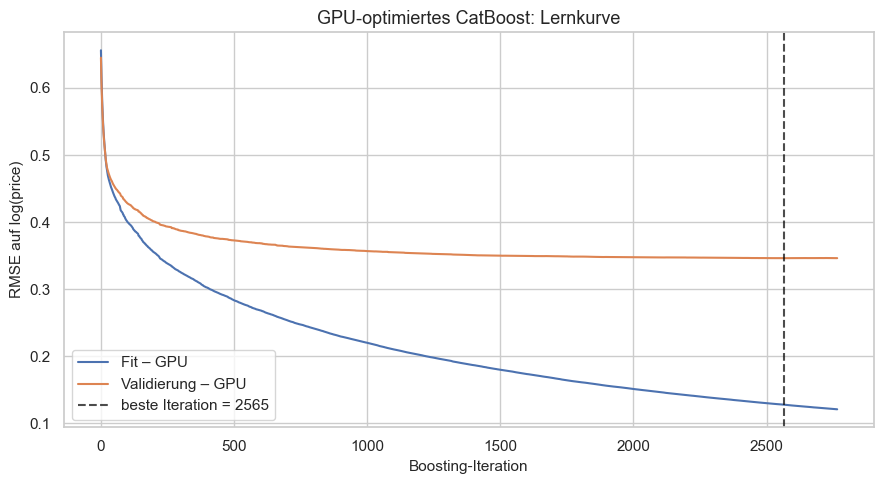

In [193]:
catboost_gpu_evals = catboost_gpu_model.get_evals_result()
gpu_iterations = np.arange(1, len(catboost_gpu_evals["learn"]["RMSE"]) + 1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(gpu_iterations, catboost_gpu_evals["learn"]["RMSE"], label="Fit – GPU")
ax.plot(gpu_iterations, catboost_gpu_evals["validation"]["RMSE"], label="Validierung – GPU")
ax.axvline(
    catboost_gpu_model.get_best_iteration() + 1,
    color="black",
    linestyle="--",
    alpha=0.7,
    label=f"beste Iteration = {catboost_gpu_model.get_best_iteration() + 1}",
)
ax.set(
    title="GPU-optimiertes CatBoost: Lernkurve",
    xlabel="Boosting-Iteration",
    ylabel="RMSE auf log(price)",
)
ax.legend()
plt.tight_layout()
plt.show()

### 17.6 Evaluation auf dem unangetasteten Testdatensatz

In [205]:
pred_catboost_gpu = catboost_gpu_model.predict(catboost_test_pool)
catboost_gpu_metrics = evaluate_log_price_model(
    "CatBoost – GPU-optimiert", y_test, pred_catboost_gpu
)
pd.DataFrame([catboost_gpu_metrics]).set_index("Modell")

,RMSE log(price),MAE log(price),R² log(price),MAE price,Median AE price
Modell,,,,,
CatBoost – GPU-optimiert,0.333133,0.209265,0.752764,6639.744475,2342.606895


### 17.7 Feature Importance des GPU-Modells

In [195]:
catboost_gpu_feature_importance = (
    pd.DataFrame({
        "feature": catboost_gpu_model.feature_names_,
        "importance": catboost_gpu_model.get_feature_importance(
            type="PredictionValuesChange"
        ),
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
catboost_gpu_feature_importance.head(30)

,feature,importance
0,latitude,10.676516
1,longitude,8.488314
2,accommodates,8.155102
3,neighbourhood_cleansed,6.871837
4,minimum_nights,5.511549
5,host_total_listings_count,3.689615
6,amenities_count,3.490639
7,bedrooms,3.153189
8,calculated_host_listings_count_entire_homes,3.006916
9,calculated_host_listings_count,2.792565


## 18. Erweiterte CatBoost-Modelle mit Textdaten

Dieser Abschnitt erg?nzt die strukturierten Merkmale um Listing-Texte und Rezensionen. Verwendet werden `name`, `description`, `neighborhood_overview`, `host_about`, die vollst?ndige Amenities-Liste sowie maximal zehn der j?ngsten Rezensionen pro Listing. Reviewer-Namen und IDs werden nicht verwendet.

Zwei Varianten werden getrennt verglichen:

1. **Native CatBoost-Textfeatures:** CatBoost tokenisiert die Textspalten selbst und erzeugt daraus Bag-of-Words-Merkmale. `text_features`, Tokenisierung, W?rterb?cher und Feature-Calcer sind laut CatBoost-API f?r GPU-Training vorgesehen.
2. **TF-IDF/SVD:** Wort- und Zeichen-TF-IDF werden ausschlie?lich auf dem Fit-Split gelernt. Eine Truncated SVD komprimiert die gro?e Sparse-Matrix auf 128 dichte Komponenten; diese werden zusammen mit den urspr?nglichen Kategorien an das GPU-CatBoost-Modell ?bergeben. TF-IDF und SVD laufen dabei auf der CPU, das eigentliche Boosting auf der GPU.

Die Zeichen-N-Gramme sind wichtig, weil ein Teil der Texte Japanisch enth?lt und daher nicht zuverl?ssig durch Leerzeichen in W?rter zerlegt wird.

Quellen: [CatBoost ? Text features](https://catboost.ai/docs/en/features/text-features), [CatBoostRegressor.fit](https://catboost.ai/docs/en/concepts/python-reference_catboostregressor_fit), [TfidfVectorizer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html), [TruncatedSVD](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.TruncatedSVD.html).

### 18.1 Rezensionen einlesen und pro Listing aggregieren

In [196]:
from scipy import sparse
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

CATBOOST_TEXT_GPU_PARAMS = {
    "loss_function": "RMSE",
    "eval_metric": "RMSE",
    "iterations": 4_000,
    "learning_rate": 0.10,
    "depth": 7,
    "l2_leaf_reg": 5.0,
    "boosting_type": "Plain",
    "border_count": 32,
    "leaf_estimation_iterations": 1,
    "max_ctr_complexity": 1,
    "one_hot_max_size": 10,
    "random_seed": 42,
    "task_type": "GPU",
    "devices": "0",
    "gpu_ram_part": 0.85,
    "allow_writing_files": False,
}

def fit_text_gpu_catboost(model_name, fit_pool, validation_pool, **extra_params):
    model = CatBoostRegressor(**{**CATBOOST_TEXT_GPU_PARAMS, **extra_params})
    start = perf_counter()
    model.fit(
        fit_pool,
        eval_set=validation_pool,
        use_best_model=True,
        early_stopping_rounds=200,
        verbose=200,
    )
    elapsed = perf_counter() - start
    print(f"{model_name}: {elapsed / 60:.2f} Minuten")
    print(f"task_type: {model.get_all_params().get('task_type')}")
    print(f"Beste Iteration: {model.get_best_iteration() + 1}")
    print(f"Validierungs-RMSE: {model.get_best_score()['validation']['RMSE']:.6f}")
    return model, elapsed

def plot_catboost_learning_curve(model, title):
    evals = model.get_evals_result()
    iterations = np.arange(1, len(evals["learn"]["RMSE"]) + 1)
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(iterations, evals["learn"]["RMSE"], label="Fit")
    ax.plot(iterations, evals["validation"]["RMSE"], label="Validierung")
    ax.axvline(
        model.get_best_iteration() + 1,
        color="black",
        linestyle="--",
        alpha=0.7,
        label=f"beste Iteration = {model.get_best_iteration() + 1}",
    )
    ax.set(title=title, xlabel="Boosting-Iteration", ylabel="RMSE auf log(price)")
    ax.legend()
    plt.tight_layout()
    plt.show()

REVIEWS_PATH = DATA_DIR / "reviews.csv.gz"
MAX_REVIEWS_PER_LISTING = 10
MAX_CHARS_PER_REVIEW = 600

reviews_for_text = pd.read_csv(
    REVIEWS_PATH,
    usecols=["listing_id", "date", "comments"],
    low_memory=False,
)
reviews_for_text = reviews_for_text.dropna(subset=["listing_id", "comments"]).copy()
reviews_for_text["date"] = pd.to_datetime(
    reviews_for_text["date"], errors="coerce"
)
reviews_for_text["comments_clean"] = (
    reviews_for_text["comments"]
    .astype(str)
    .str.replace(r"<br\s*/?>", " ", regex=True, case=False)
    .str.replace(r"<[^>]+>", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
    .str.slice(0, MAX_CHARS_PER_REVIEW)
)
reviews_for_text = reviews_for_text.loc[
    reviews_for_text["comments_clean"].str.len() > 0
].sort_values(["listing_id", "date"], ascending=[True, False])

# Begrenzung verhindert, dass Listings mit sehr vielen Bewertungen Speicher und Laufzeit dominieren.
recent_reviews = (
    reviews_for_text
    .groupby("listing_id", group_keys=False)
    .head(MAX_REVIEWS_PER_LISTING)
)
review_text_by_listing = recent_reviews.groupby("listing_id")["comments_clean"].agg(
    " ".join
)
review_text_count_by_listing = recent_reviews.groupby("listing_id").size()

print(f"Rezensionen insgesamt: {len(reviews_for_text):,}")
print(f"F?r Textmodelle verwendet: {len(recent_reviews):,}")
print(f"Listings mit Rezensionstext: {len(review_text_by_listing):,}")

Rezensionen insgesamt: 1,004,918
F?r Textmodelle verwendet: 192,944
Listings mit Rezensionstext: 24,009


### 18.2 Listing-Texte zusammenf?hren und Abdeckung pr?fen

In [197]:
listing_text_parts = [
    "title " + full_data["name"].fillna("").astype(str),
    "description " + full_data["description"].fillna("").astype(str),
    "neighborhood " + full_data["neighborhood_overview"].fillna("").astype(str),
    "host " + full_data["host_about"].fillna("").astype(str),
]
full_data["listing_text"] = listing_text_parts[0].str.cat(
    listing_text_parts[1:], sep=" "
).str.replace(r"\s+", " ", regex=True).str.strip()
full_data["reviews_text"] = full_data["id"].map(review_text_by_listing).fillna("")
full_data["amenities_text"] = full_data["amenities"].map(
    lambda value: " ".join(sorted(parse_amenity_set(value)))
)

# CatBoost ben?tigt echte Strings. Ein expliziter Platzhalter h?lt fehlenden Text g?ltig.
catboost_text_cols = ["listing_text", "reviews_text", "amenities_text"]

def sanitize_utf8_text(value):
    """Ersetzt nur ungültige Unicode-Surrogate; reguläres UTF-8 bleibt unverändert."""
    return str(value).encode("utf-8", errors="replace").decode("utf-8")

invalid_unicode_replacements = {}
for col in catboost_text_cols:
    original_text = full_data[col].fillna("").astype(str)
    sanitized_text = original_text.map(sanitize_utf8_text)
    invalid_unicode_replacements[col] = int((sanitized_text != original_text).sum())
    full_data[col] = sanitized_text
    full_data.loc[full_data[col].str.strip().eq(""), col] = "missing text"

print("Texte mit ersetzten ungültigen Unicode-Zeichen:", invalid_unicode_replacements)

full_data["review_text_count"] = (
    full_data["id"].map(review_text_count_by_listing).fillna(0).astype(float)
)
full_data["listing_text_chars"] = full_data["listing_text"].str.len().astype(float)
full_data["reviews_text_chars"] = full_data["reviews_text"].str.len().astype(float)
text_numeric_cols = [
    "review_text_count", "listing_text_chars", "reviews_text_chars"
]

catboost_text_data = catboost_data.copy()
catboost_text_data[catboost_text_cols + text_numeric_cols] = full_data[
    catboost_text_cols + text_numeric_cols
]
X_catboost_text_train = catboost_text_data.loc[X_train.index]
X_catboost_text_test = catboost_text_data.loc[X_test.index]

text_coverage = pd.DataFrame({
    "Textquelle": catboost_text_cols,
    "Anteil mit Inhalt": [
        (full_data[col] != "missing text").mean() for col in catboost_text_cols
    ],
    "Median Zeichen": [full_data[col].str.len().median() for col in catboost_text_cols],
    "95%-Quantil Zeichen": [full_data[col].str.len().quantile(0.95) for col in catboost_text_cols],
})
text_coverage

Texte mit ersetzten ungültigen Unicode-Zeichen: {'listing_text': 0, 'reviews_text': 0, 'amenities_text': 1}


,Textquelle,Anteil mit Inhalt,Median Zeichen,95%-Quantil Zeichen
0,listing_text,1.000000,1099.0,2056.05
1,reviews_text,0.862755,1230.0,2744.00
2,amenities_text,0.999961,422.0,753.00


### 18.3 Modell 1: native CatBoost-Textfeatures

Die drei Textquellen bleiben separate Features. `BoW:top_tokens_count=4000` begrenzt die Anzahl der pro Textfeature erzeugten Tokenmerkmale und h?lt das Modell auf der Laptop-GPU handhabbar. Die W?rterb?cher werden von CatBoost ausschlie?lich aus dem Fit-Pool erzeugt; Validierung und Test werden nur transformiert.

In [198]:
catboost_native_text_fit_pool = Pool(
    data=X_catboost_text_train.iloc[boost_fit_idx],
    label=y_train.iloc[boost_fit_idx],
    cat_features=catboost_categorical_cols,
    text_features=catboost_text_cols,
    feature_names=list(X_catboost_text_train.columns),
)
catboost_native_text_validation_pool = Pool(
    data=X_catboost_text_train.iloc[boost_valid_idx],
    label=y_train.iloc[boost_valid_idx],
    cat_features=catboost_categorical_cols,
    text_features=catboost_text_cols,
    feature_names=list(X_catboost_text_train.columns),
)
catboost_native_text_test_pool = Pool(
    data=X_catboost_text_test,
    label=y_test,
    cat_features=catboost_categorical_cols,
    text_features=catboost_text_cols,
    feature_names=list(X_catboost_text_test.columns),
)

catboost_native_text_model, catboost_native_text_training_seconds = fit_text_gpu_catboost(
    "CatBoost ? native Textfeatures",
    catboost_native_text_fit_pool,
    catboost_native_text_validation_pool,
    feature_calcers=["BoW:top_tokens_count=4000"],
)

0:	learn: 0.6564715	test: 0.6454120	best: 0.6454120 (0)	total: 83.9ms	remaining: 5m 35s
200:	learn: 0.3340488	test: 0.3898315	best: 0.3898315 (200)	total: 3.09s	remaining: 58.4s
400:	learn: 0.2909992	test: 0.3728588	best: 0.3728234 (399)	total: 5.9s	remaining: 53s
600:	learn: 0.2624049	test: 0.3646583	best: 0.3646583 (600)	total: 8.75s	remaining: 49.5s
800:	learn: 0.2402807	test: 0.3589981	best: 0.3589981 (800)	total: 11.6s	remaining: 46.2s
1000:	learn: 0.2218474	test: 0.3555154	best: 0.3555154 (1000)	total: 14.6s	remaining: 43.7s
1200:	learn: 0.2060031	test: 0.3531462	best: 0.3531462 (1200)	total: 17.3s	remaining: 40.4s
1400:	learn: 0.1923020	test: 0.3507589	best: 0.3506955 (1388)	total: 20s	remaining: 37.1s
1600:	learn: 0.1798519	test: 0.3487418	best: 0.3487253 (1583)	total: 22.9s	remaining: 34.2s
1800:	learn: 0.1686858	test: 0.3470768	best: 0.3470768 (1800)	total: 25.7s	remaining: 31.4s
2000:	learn: 0.1583741	test: 0.3457393	best: 0.3457228 (1998)	total: 28.7s	remaining: 28.6s
2200:

### 18.4 Evaluation des nativen Textmodells

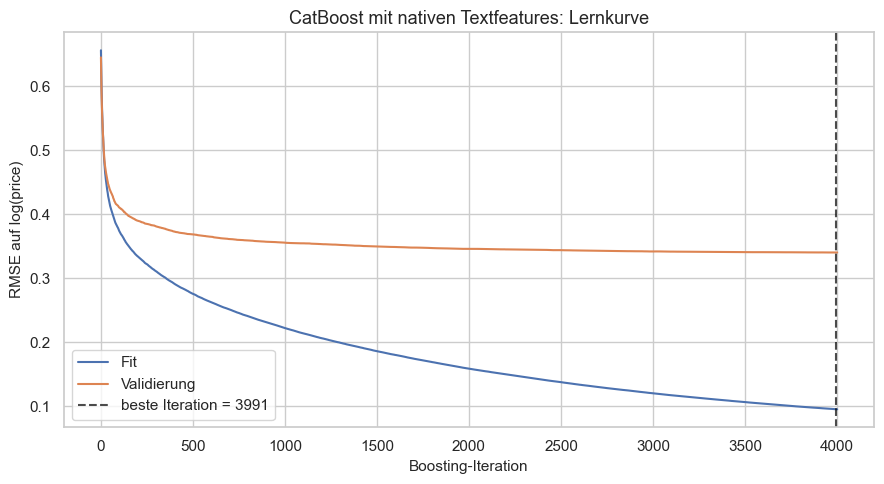

,RMSE log(price),MAE log(price),R² log(price),MAE price,Median AE price
Modell,,,,,
CatBoost ? native Textfeatures,0.323201,0.199607,0.767286,6094.641019,2154.465609


In [199]:
plot_catboost_learning_curve(
    catboost_native_text_model,
    "CatBoost mit nativen Textfeatures: Lernkurve",
)

pred_catboost_native_text = catboost_native_text_model.predict(
    catboost_native_text_test_pool
)
catboost_native_text_metrics = evaluate_log_price_model(
    "CatBoost ? native Textfeatures", y_test, pred_catboost_native_text
)
pd.DataFrame([catboost_native_text_metrics]).set_index("Modell")

### 18.5 Modell 2: Wort- und Zeichen-TF-IDF mit Truncated SVD

Beide Vektorisierer und die SVD werden nur auf dem inneren Fit-Split angepasst. Dadurch gelangen weder Validierungs- noch Testvokabular in die Merkmalskonstruktion. Die SVD ist hier eine GPU-orientierte Dimensionsreduktion: CatBoost erh?lt 128 dichte Komponenten statt rund 24.000 Sparse-TF-IDF-Spalten und kann gleichzeitig die urspr?nglichen Kategorien nativ behalten.

In [200]:
def combine_text_document(frame):
    return (
        "listing " + frame["listing_text"].astype(str)
        + " reviews " + frame["reviews_text"].astype(str)
        + " amenities " + frame["amenities_text"].astype(str)
    )

train_documents = combine_text_document(X_catboost_text_train)
test_documents = combine_text_document(X_catboost_text_test)
fit_documents = train_documents.iloc[boost_fit_idx]
validation_documents = train_documents.iloc[boost_valid_idx]

word_tfidf = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.98,
    max_features=12_000,
    sublinear_tf=True,
    dtype=np.float32,
)
char_tfidf = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 5),
    min_df=5,
    max_features=12_000,
    sublinear_tf=True,
    dtype=np.float32,
)

word_fit = word_tfidf.fit_transform(fit_documents)
char_fit = char_tfidf.fit_transform(fit_documents)
tfidf_fit_sparse = sparse.hstack([word_fit, char_fit], format="csr")

def transform_tfidf(documents):
    return sparse.hstack(
        [word_tfidf.transform(documents), char_tfidf.transform(documents)],
        format="csr",
    )

tfidf_validation_sparse = transform_tfidf(validation_documents)
tfidf_test_sparse = transform_tfidf(test_documents)

n_svd_components = min(
    128,
    tfidf_fit_sparse.shape[0] - 1,
    tfidf_fit_sparse.shape[1] - 1,
)
tfidf_svd = TruncatedSVD(
    n_components=n_svd_components,
    n_iter=5,
    random_state=42,
)
tfidf_fit_svd = tfidf_svd.fit_transform(tfidf_fit_sparse).astype(np.float32)
tfidf_validation_svd = tfidf_svd.transform(tfidf_validation_sparse).astype(np.float32)
tfidf_test_svd = tfidf_svd.transform(tfidf_test_sparse).astype(np.float32)

print(f"Wort-TF-IDF-Vokabular: {len(word_tfidf.vocabulary_):,}")
print(f"Zeichen-TF-IDF-Vokabular: {len(char_tfidf.vocabulary_):,}")
print(f"SVD-Komponenten: {n_svd_components}")
print(f"Erkl?rte SVD-Varianz: {tfidf_svd.explained_variance_ratio_.sum():.3f}")

Wort-TF-IDF-Vokabular: 12,000
Zeichen-TF-IDF-Vokabular: 12,000
SVD-Komponenten: 128
Erkl?rte SVD-Varianz: 0.305


### 18.6 TF-IDF/SVD mit strukturierten Features kombinieren und trainieren

In [201]:
tfidf_component_cols = [
    f"tfidf_svd_{i:03d}" for i in range(n_svd_components)
]
tfidf_structured_cols = list(catboost_data.columns) + text_numeric_cols

X_tfidf_fit = pd.concat([
    X_catboost_text_train.iloc[boost_fit_idx][tfidf_structured_cols],
    pd.DataFrame(
        tfidf_fit_svd,
        index=X_catboost_text_train.iloc[boost_fit_idx].index,
        columns=tfidf_component_cols,
    ),
], axis=1)
X_tfidf_validation = pd.concat([
    X_catboost_text_train.iloc[boost_valid_idx][tfidf_structured_cols],
    pd.DataFrame(
        tfidf_validation_svd,
        index=X_catboost_text_train.iloc[boost_valid_idx].index,
        columns=tfidf_component_cols,
    ),
], axis=1)
X_tfidf_test = pd.concat([
    X_catboost_text_test[tfidf_structured_cols],
    pd.DataFrame(
        tfidf_test_svd,
        index=X_catboost_text_test.index,
        columns=tfidf_component_cols,
    ),
], axis=1)

tfidf_fit_pool = Pool(
    X_tfidf_fit,
    y_train.iloc[boost_fit_idx],
    cat_features=catboost_categorical_cols,
    feature_names=list(X_tfidf_fit.columns),
)
tfidf_validation_pool = Pool(
    X_tfidf_validation,
    y_train.iloc[boost_valid_idx],
    cat_features=catboost_categorical_cols,
    feature_names=list(X_tfidf_validation.columns),
)
tfidf_test_pool = Pool(
    X_tfidf_test,
    y_test,
    cat_features=catboost_categorical_cols,
    feature_names=list(X_tfidf_test.columns),
)

catboost_tfidf_model, catboost_tfidf_training_seconds = fit_text_gpu_catboost(
    "CatBoost ? TF-IDF/SVD",
    tfidf_fit_pool,
    tfidf_validation_pool,
)

0:	learn: 0.6564785	test: 0.6453690	best: 0.6453690 (0)	total: 11.3ms	remaining: 45.1s
200:	learn: 0.3180516	test: 0.3859434	best: 0.3859434 (200)	total: 1.75s	remaining: 33.2s
400:	learn: 0.2587239	test: 0.3710873	best: 0.3710873 (400)	total: 3.37s	remaining: 30.2s
600:	learn: 0.2175924	test: 0.3630617	best: 0.3630617 (600)	total: 5.03s	remaining: 28.4s
800:	learn: 0.1854225	test: 0.3595531	best: 0.3595517 (799)	total: 6.62s	remaining: 26.4s
1000:	learn: 0.1601797	test: 0.3573048	best: 0.3572668 (998)	total: 8.22s	remaining: 24.6s
1200:	learn: 0.1384984	test: 0.3561768	best: 0.3561094 (1188)	total: 9.9s	remaining: 23.1s
1400:	learn: 0.1208801	test: 0.3554141	best: 0.3553823 (1389)	total: 11.5s	remaining: 21.4s
1600:	learn: 0.1056788	test: 0.3543961	best: 0.3543825 (1588)	total: 13.2s	remaining: 19.7s
1800:	learn: 0.0931240	test: 0.3536950	best: 0.3536280 (1785)	total: 14.8s	remaining: 18s
2000:	learn: 0.0823924	test: 0.3534180	best: 0.3534180 (2000)	total: 16.4s	remaining: 16.4s
2200:

### 18.7 Evaluation des TF-IDF/SVD-Modells

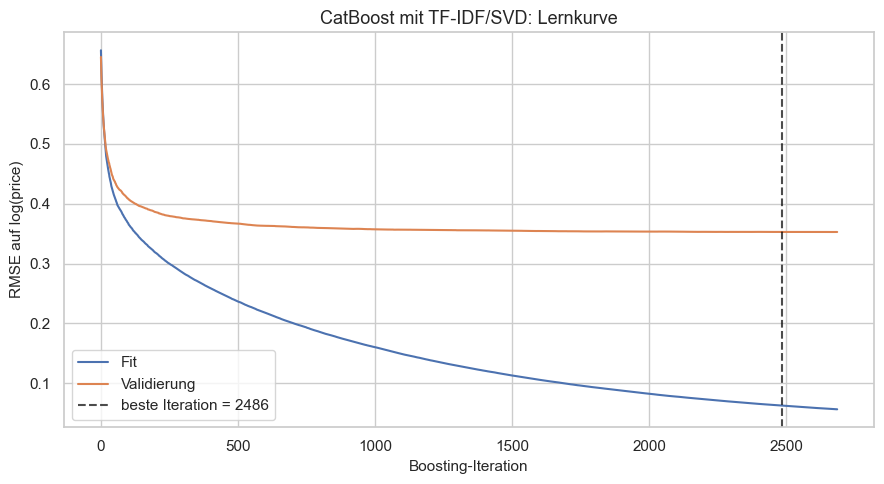

,RMSE log(price),MAE log(price),R² log(price),MAE price,Median AE price
Modell,,,,,
CatBoost ? TF-IDF/SVD,0.333503,0.213386,0.752214,6313.801613,2405.365144


In [202]:
plot_catboost_learning_curve(
    catboost_tfidf_model,
    "CatBoost mit TF-IDF/SVD: Lernkurve",
)

pred_catboost_tfidf = catboost_tfidf_model.predict(tfidf_test_pool)
catboost_tfidf_metrics = evaluate_log_price_model(
    "CatBoost ? TF-IDF/SVD", y_test, pred_catboost_tfidf
)
pd.DataFrame([catboost_tfidf_metrics]).set_index("Modell")

### 18.8 Vergleich aller drei GPU-CatBoost-Modelle

In [206]:
catboost_text_comparison = pd.DataFrame([
    {
        **catboost_gpu_metrics,
        "Textdarstellung": "keine",
        "Trainingszeit Minuten": catboost_gpu_training_seconds / 60,
    },
    {
        **catboost_native_text_metrics,
        "Textdarstellung": "CatBoost nativ (BoW)",
        "Trainingszeit Minuten": catboost_native_text_training_seconds / 60,
    },
    {
        **catboost_tfidf_metrics,
        "Textdarstellung": "Wort- und Zeichen-TF-IDF + 128 SVD",
        "Trainingszeit Minuten": catboost_tfidf_training_seconds / 60,
    },
]).set_index("Modell").sort_values("RMSE log(price)")

catboost_text_comparison[[
    "Textdarstellung",
    "Trainingszeit Minuten",
    "RMSE log(price)",
    "MAE log(price)",
    "R\u00b2 log(price)",
    "MAE price",
    "Median AE price",
]]

,Textdarstellung,Trainingszeit Minuten,RMSE log(price),MAE log(price),R² log(price),MAE price,Median AE price
Modell,,,,,,,
CatBoost ? native Textfeatures,CatBoost nativ (BoW),1.085021,0.323201,0.199607,0.767286,6094.641019,2154.465609
CatBoost – GPU-optimiert,keine,0.327797,0.333133,0.209265,0.752764,6639.744475,2342.606895
CatBoost ? TF-IDF/SVD,Wort- und Zeichen-TF-IDF + 128 SVD,0.380022,0.333503,0.213386,0.752214,6313.801613,2405.365144


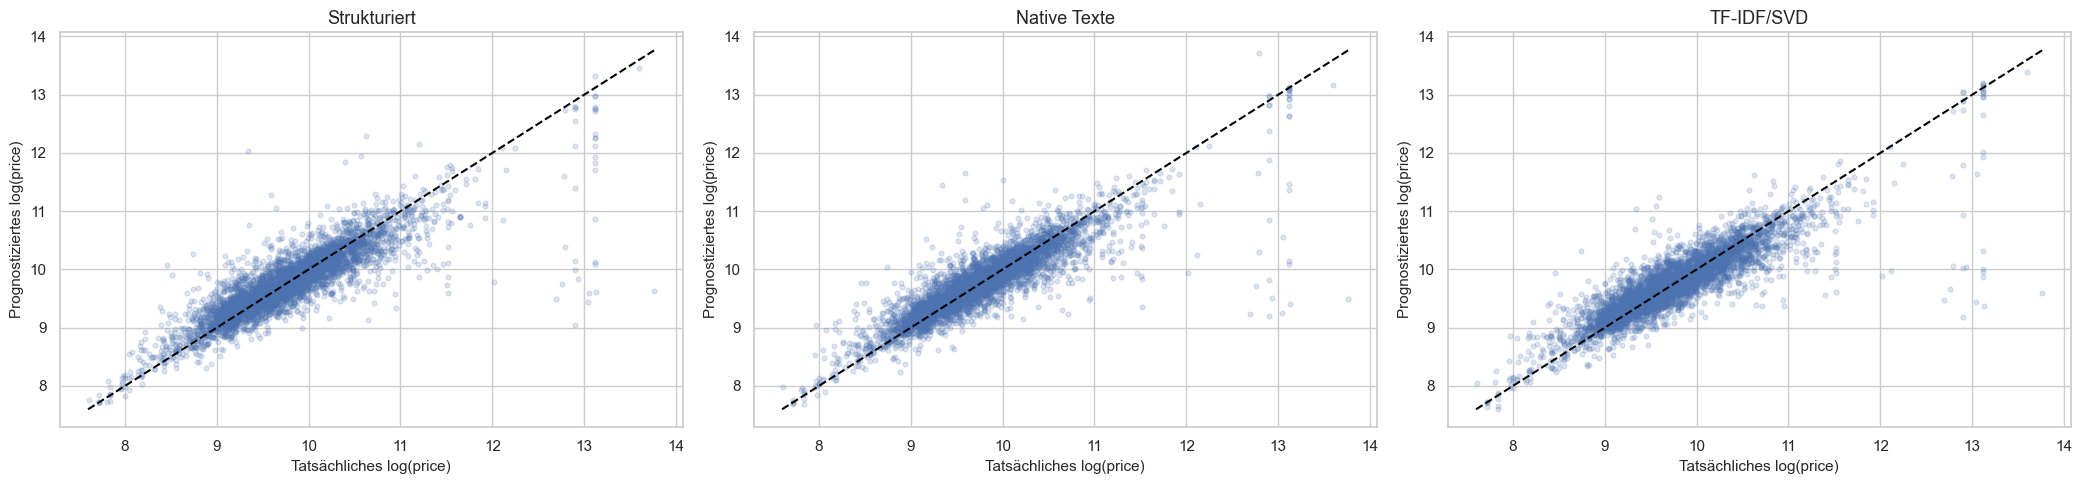

In [207]:
plot_actual_vs_predicted(
    y_test,
    {
        "Strukturiert": pred_catboost_gpu,
        "Native Texte": pred_catboost_native_text,
        "TF-IDF/SVD": pred_catboost_tfidf,
    },
)

### 18.9 Featuregruppen der Textmodelle

In [208]:
native_text_importance = pd.DataFrame({
    "feature": catboost_native_text_model.feature_names_,
    "importance": catboost_native_text_model.get_feature_importance(
        type="PredictionValuesChange"
    ),
}).sort_values("importance", ascending=False)

tfidf_importance = pd.DataFrame({
    "feature": catboost_tfidf_model.feature_names_,
    "importance": catboost_tfidf_model.get_feature_importance(
        type="PredictionValuesChange"
    ),
})
tfidf_importance["feature_group"] = np.where(
    tfidf_importance["feature"].str.startswith("tfidf_svd_"),
    "TF-IDF/SVD-Komponenten",
    tfidf_importance["feature"],
)
tfidf_group_importance = (
    tfidf_importance.groupby("feature_group", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
)

print("Native Textfeatures ? wichtigste Ausgangsfeatures")
display(native_text_importance.head(30))
print("TF-IDF/SVD ? aggregierte Featuregruppen")
display(tfidf_group_importance.head(30))

Native Textfeatures ? wichtigste Ausgangsfeatures


,feature,importance
64,listing_text,25.913752
34,accommodates,10.850206
66,amenities_text,10.623985
38,latitude,6.510107
65,reviews_text,5.601233
3,neighbourhood_cleansed,5.394066
40,minimum_nights,4.729916
39,longitude,3.474180
36,bedrooms,3.203704
8,bathroom_privacy,2.133493


TF-IDF/SVD ? aggregierte Featuregruppen


,feature_group,importance
0,TF-IDF/SVD-Komponenten,51.001897
1,accommodates,8.797387
47,latitude,5.226101
51,neighbourhood_cleansed,4.376115
49,longitude,3.404783
50,minimum_nights,3.257821
29,bedrooms,2.736669
25,bathroom_privacy,1.574803
54,number_of_reviews_ltm,1.518991
26,bathrooms,1.073068


### 18.10 Interpretation

Entscheidend ist der Vergleich mit dem strukturierten GPU-Basismodell auf demselben Testdatensatz. Eine Textvariante ist nur dann ?berzeugend, wenn sie Validierungs- und Testfehler verbessert und nicht blo? zus?tzliche Laufzeit erzeugt.

Bei der Interpretation sind drei Punkte wichtig:

- Rezensionstext ist f?r neue Listings h?ufig nicht verf?gbar; die Abdeckungstabelle zeigt, wie stark dieses Problem im Datensatz ist.
- Text kann Preis- und Lagehinweise direkt enthalten. Das ist n?tzlich f?r Vorhersage, aber keine kausale Aussage ?ber den Preiseffekt einzelner W?rter.
- Wiederholte Modellauswahl anhand des Testsets w?rde den Testfehler optimistisch verzerren. Weitere Hyperparameter sollten deshalb am Validierungssplit oder per Cross-Validation abgestimmt werden; das Testset bleibt f?r den finalen Vergleich reserviert.

## 19. Hauptbild-Embeddings mit CLIP und natives Text-CatBoost

Der Datensatz enthält pro Listing genau eine Unterkunftsbild-URL in `picture_url`. Deshalb wird ausschließlich das Hauptbild verwendet. Identische URLs werden nur einmal gespeichert und eingebettet.

Die Bilder liegen bandbreitenschonend als 320-Pixel-WebP-Dateien unter `data/images/`. Das Skript `download_listing_images.py` ist resumierbar und erzeugt `data/image_manifest.csv`. Es nutzt den Airbnb-CDN-Resize-Endpunkt, damit nicht die oft mehrere Megabyte großen Originalbilder geladen werden.

Das finale Bildmodell erweitert ausdrücklich das CatBoost-Modell mit **nativen Textfeatures** aus Abschnitt 18.3; die TF-IDF/SVD-Variante wird hier nicht verwendet.

### 19.1 Lokalen Bildbestand prüfen

Der Download wird bewusst nicht bei jedem Notebook-Lauf erneut gestartet. Falls Bilder fehlen, kann außerhalb des Notebooks im Ordner `Final_Project` erneut `python download_listing_images.py --workers 12` ausgeführt werden. Bereits vorhandene Dateien werden übersprungen.

In [209]:
from PIL import Image, ImageFile
from torch.utils.data import Dataset, DataLoader

IMAGE_MANIFEST_PATH = DATA_DIR / "image_manifest.csv"
IMAGE_EMBEDDING_PATH = DATA_DIR / "clip_main_image_embeddings.npz"
CLIP_MODEL_NAME = "ViT-B/32"
CLIP_BATCH_SIZE = 32

if not IMAGE_MANIFEST_PATH.exists():
    raise FileNotFoundError(
        "Das Bildmanifest fehlt. Zuerst aus Final_Project ausfuehren: "
        "python download_listing_images.py --workers 12"
    )

image_manifest = pd.read_csv(IMAGE_MANIFEST_PATH, low_memory=False)
image_manifest["file_exists"] = image_manifest["local_path"].map(
    lambda value: Path(value).exists()
)
image_status = pd.DataFrame({
    "Kennzahl": [
        "Listings im Manifest",
        "Eindeutige Hauptbilder",
        "Lokal vorhandene Listing-Bilder",
        "Lokal vorhandene eindeutige Dateien",
    ],
    "Wert": [
        image_manifest["listing_id"].nunique(),
        image_manifest["download_url"].nunique(),
        int(image_manifest["file_exists"].sum()),
        image_manifest.loc[image_manifest["file_exists"], "local_path"].nunique(),
    ],
})
image_status

,Kennzahl,Wert
0,Listings im Manifest,27945
1,Eindeutige Hauptbilder,26143
2,Lokal vorhandene Listing-Bilder,26579
3,Lokal vorhandene eindeutige Dateien,24817


### 19.2 CLIP-Embeddings auf der GPU berechnen und cachen

Verwendet wird OpenAIs `ViT-B/32`. `model.encode_image` erzeugt einen 512-dimensionalen Bildvektor; jeder Vektor wird auf L2-Norm 1 normalisiert. Berechnet wird nur für bisher nicht gecachte Dateien. Der Cache wird als `float16` gespeichert und für CatBoost wieder in `float32` geladen.

Die offizielle CLIP-Implementierung beschreibt `clip.load`, die zugehörige Bildvorverarbeitung und `encode_image`: [OpenAI CLIP](https://github.com/openai/CLIP). CatBoost weist ausdrücklich darauf hin, dass Embedding-Koordinaten als numerische Features ergänzt werden können: [CatBoost Embedding Features](https://catboost.ai/docs/en/features/embeddings-features).

Falls `clip` noch fehlt: `pip install git+https://github.com/openai/CLIP.git`.

In [215]:
try:
    import clip
except ImportError as exc:
    raise ImportError(
        "OpenAI CLIP fehlt. Einmal ausfuehren: "
        "pip install git+https://github.com/openai/CLIP.git"
    ) from exc

if not use_cuda:
    raise RuntimeError("CLIP-Embeddings sind in diesem Notebook fuer CUDA konfiguriert.")

ImageFile.LOAD_TRUNCATED_IMAGES = True
available_image_paths = sorted(
    image_manifest.loc[image_manifest["file_exists"], "local_path"]
    .drop_duplicates()
    .astype(str)
)

cached_path_to_embedding = {}
if IMAGE_EMBEDDING_PATH.exists():
    with np.load(IMAGE_EMBEDDING_PATH, allow_pickle=False) as cached:
        cached_paths = cached["local_paths"].astype(str)
        cached_vectors = cached["embeddings"].astype(np.float32)
    cached_path_to_embedding = dict(zip(cached_paths, cached_vectors))

missing_embedding_paths = [
    path for path in available_image_paths if path not in cached_path_to_embedding
]
print(f"Lokal verfuegbare eindeutige Bilder: {len(available_image_paths):,}")
print(f"Davon bereits eingebettet: {len(available_image_paths) - len(missing_embedding_paths):,}")
print(f"Neu einzubetten: {len(missing_embedding_paths):,}")

class ClipImageDataset(Dataset):
    def __init__(self, paths, preprocess):
        self.paths = list(paths)
        self.preprocess = preprocess

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, index):
        path = self.paths[index]
        with Image.open(path) as image:
            tensor = self.preprocess(image.convert("RGB"))
        return tensor, path

clip_embedding_seconds = 0.0
if missing_embedding_paths:
    clip_model, clip_preprocess = clip.load(
        CLIP_MODEL_NAME, device=device, jit=False
    )
    clip_model.eval()
    clip_loader = DataLoader(
        ClipImageDataset(missing_embedding_paths, clip_preprocess),
        batch_size=CLIP_BATCH_SIZE,
        shuffle=False,
        num_workers=0,
        pin_memory=True,
    )
    new_paths = []
    new_vectors = []
    clip_start = perf_counter()
    with torch.inference_mode():
        for batch_number, (images, paths) in enumerate(clip_loader, start=1):
            images = images.to(device, non_blocking=True)
            with torch.autocast(device_type="cuda", dtype=torch.float16):
                features = clip_model.encode_image(images)
                features = features / features.norm(dim=1, keepdim=True).clamp_min(1e-12)
            new_vectors.append(features.float().cpu().numpy())
            new_paths.extend(paths)
            if batch_number % 100 == 0 or batch_number == len(clip_loader):
                print(f"CLIP-Batches: {batch_number:,}/{len(clip_loader):,}")
    clip_embedding_seconds = perf_counter() - clip_start
    cached_path_to_embedding.update(
        dict(zip(new_paths, np.vstack(new_vectors).astype(np.float32)))
    )
    del clip_model, clip_loader
    torch.cuda.empty_cache()

# Cache atomar neu schreiben; float16 halbiert den lokalen Speicherbedarf.
cache_paths = np.array(sorted(cached_path_to_embedding), dtype=str)
cache_vectors = np.vstack([
    cached_path_to_embedding[path] for path in cache_paths
]).astype(np.float16)
temporary_embedding_path = IMAGE_EMBEDDING_PATH.with_suffix(".tmp.npz")
np.savez_compressed(
    temporary_embedding_path,
    local_paths=cache_paths,
    embeddings=cache_vectors,
)
temporary_embedding_path.replace(IMAGE_EMBEDDING_PATH)

print(f"Embedding-Dimension: {cache_vectors.shape[1]}")
print(f"Neu berechnete CLIP-Zeit: {clip_embedding_seconds / 60:.2f} Minuten")
print(f"Embedding-Cache: {IMAGE_EMBEDDING_PATH}")

Lokal verfuegbare eindeutige Bilder: 24,817
Davon bereits eingebettet: 24,817
Neu einzubetten: 0
Embedding-Dimension: 512
Neu berechnete CLIP-Zeit: 0.00 Minuten
Embedding-Cache: data\clip_main_image_embeddings.npz


### 19.3 Hauptbild-Embeddings den Listings zuordnen

Listings ohne erfolgreich geladenes Bild erhalten einen Nullvektor und den Indikator `clip_image_available = 0`. Da CLIP vortrainiert ist und keine Preislabels verwendet, entsteht bei der Embedding-Berechnung kein Target Leakage. Die normalisierten 512 Koordinaten werden als numerische CatBoost-Features verwendet.

In [221]:
with np.load(IMAGE_EMBEDDING_PATH, allow_pickle=False) as cached:
    clip_cached_paths = cached["local_paths"].astype(str)
    clip_cached_vectors = cached["embeddings"].astype(np.float32)

clip_path_to_row = {path: row for row, path in enumerate(clip_cached_paths)}
listing_to_image_path = (
    image_manifest.drop_duplicates("listing_id")
    .set_index("listing_id")["local_path"]
)
listing_image_paths = full_data["id"].map(listing_to_image_path)

clip_dimension = clip_cached_vectors.shape[1]
listing_clip_matrix = np.zeros(
    (len(full_data), clip_dimension), dtype=np.float32
)
clip_image_available = np.zeros(len(full_data), dtype=np.float32)
for row_number, path in enumerate(listing_image_paths):
    cached_row = clip_path_to_row.get(str(path))
    if cached_row is not None:
        listing_clip_matrix[row_number] = clip_cached_vectors[cached_row]
        clip_image_available[row_number] = 1.0

clip_feature_cols = [f"clip_image_{i:03d}" for i in range(clip_dimension)]
clip_feature_data = pd.DataFrame(
    listing_clip_matrix,
    index=full_data.index,
    columns=clip_feature_cols,
)
clip_feature_data["clip_image_available"] = clip_image_available

pd.DataFrame({
    "Kennzahl": ["Listings mit Hauptbild-Embedding", "Abdeckung", "CLIP-Dimension"],
    "Wert": [
        int(clip_image_available.sum()),
        float(clip_image_available.mean()),
        clip_dimension,
    ],
})

,Kennzahl,Wert
0,Listings mit Hauptbild-Embedding,24241.000000
1,Abdeckung,0.951374
2,CLIP-Dimension,512.000000


### 19.4 CLIP-Embeddings per PCA auf 32 und 64 Dimensionen reduzieren

Der lokale CLIP-Cache bleibt 512-dimensional; CatBoost erhält diese Rohkoordinaten jedoch nicht mehr direkt. Eine PCA mit maximal 64 Komponenten wird ausschließlich auf den vorhandenen Hauptbildern des inneren Fit-Splits gelernt. Die 32er-Variante verwendet die ersten 32 Komponenten derselben PCA, sodass beide Varianten sauber verschachtelt und vergleichbar sind.

Listings ohne Bild erhalten weiterhin Nullwerte und `clip_image_available = 0`. Anschließend werden zwei ansonsten identische GPU-Modelle trainiert:

1. natives Text-CatBoost plus 32 CLIP-PCA-Komponenten,
2. natives Text-CatBoost plus 64 CLIP-PCA-Komponenten.

Da nur noch wenige Bildfeatures eingehen, bleibt `border_count=32` wie beim nativen Textmodell.

In [222]:
from sklearn.decomposition import PCA

native_text_fit_frame = X_catboost_text_train.iloc[boost_fit_idx]
native_text_validation_frame = X_catboost_text_train.iloc[boost_valid_idx]
native_text_test_frame = X_catboost_text_test

fit_index = native_text_fit_frame.index
validation_index = native_text_validation_frame.index
test_index = native_text_test_frame.index

clip_fit_raw = clip_feature_data.loc[fit_index, clip_feature_cols].to_numpy(
    dtype=np.float32
)
clip_validation_raw = clip_feature_data.loc[
    validation_index, clip_feature_cols
].to_numpy(dtype=np.float32)
clip_test_raw = clip_feature_data.loc[test_index, clip_feature_cols].to_numpy(
    dtype=np.float32
)

clip_fit_available = clip_feature_data.loc[
    fit_index, "clip_image_available"
].to_numpy(dtype=np.float32)
clip_validation_available = clip_feature_data.loc[
    validation_index, "clip_image_available"
].to_numpy(dtype=np.float32)
clip_test_available = clip_feature_data.loc[
    test_index, "clip_image_available"
].to_numpy(dtype=np.float32)

# Nur echte Fit-Bilder bestimmen die PCA-Richtungen; kein Validierungs-/Test-Leakage.
clip_pca = PCA(
    n_components=64,
    svd_solver="randomized",
    iterated_power=5,
    random_state=42,
)
clip_pca.fit(clip_fit_raw[clip_fit_available == 1])

clip_fit_pca64 = clip_pca.transform(clip_fit_raw).astype(np.float32)
clip_validation_pca64 = clip_pca.transform(clip_validation_raw).astype(np.float32)
clip_test_pca64 = clip_pca.transform(clip_test_raw).astype(np.float32)

# Fehlende Bilder bleiben nach der Transformation echte Nullvektoren.
clip_fit_pca64[clip_fit_available == 0] = 0.0
clip_validation_pca64[clip_validation_available == 0] = 0.0
clip_test_pca64[clip_test_available == 0] = 0.0

print(
    f"Erklaerte Varianz mit 32 Komponenten: "
    f"{clip_pca.explained_variance_ratio_[:32].sum():.3f}"
)
print(
    f"Erklaerte Varianz mit 64 Komponenten: "
    f"{clip_pca.explained_variance_ratio_.sum():.3f}"
)

def make_clip_pca_frame(values64, available, index, n_components):
    columns = [
        f"clip_pca_{n_components}_{i:02d}" for i in range(n_components)
    ]
    frame = pd.DataFrame(
        values64[:, :n_components], index=index, columns=columns
    )
    frame["clip_image_available"] = available
    return frame

clip_pca_frames = {}
for n_components in [32, 64]:
    clip_pca_frames[n_components] = {
        "fit": make_clip_pca_frame(
            clip_fit_pca64, clip_fit_available, fit_index, n_components
        ),
        "validation": make_clip_pca_frame(
            clip_validation_pca64,
            clip_validation_available,
            validation_index,
            n_components,
        ),
        "test": make_clip_pca_frame(
            clip_test_pca64, clip_test_available, test_index, n_components
        ),
    }

catboost_clip_pca_models = {}
catboost_clip_pca_training_seconds = {}
clip_pca_test_pools = {}

for n_components in [32, 64]:
    X_pca_fit = pd.concat(
        [native_text_fit_frame, clip_pca_frames[n_components]["fit"]], axis=1
    )
    X_pca_validation = pd.concat(
        [
            native_text_validation_frame,
            clip_pca_frames[n_components]["validation"],
        ],
        axis=1,
    )
    X_pca_test = pd.concat(
        [native_text_test_frame, clip_pca_frames[n_components]["test"]], axis=1
    )

    pca_fit_pool = Pool(
        data=X_pca_fit,
        label=y_train.iloc[boost_fit_idx],
        cat_features=catboost_categorical_cols,
        text_features=catboost_text_cols,
        feature_names=list(X_pca_fit.columns),
    )
    pca_validation_pool = Pool(
        data=X_pca_validation,
        label=y_train.iloc[boost_valid_idx],
        cat_features=catboost_categorical_cols,
        text_features=catboost_text_cols,
        feature_names=list(X_pca_validation.columns),
    )
    pca_test_pool = Pool(
        data=X_pca_test,
        label=y_test,
        cat_features=catboost_categorical_cols,
        text_features=catboost_text_cols,
        feature_names=list(X_pca_test.columns),
    )

    model, elapsed = fit_text_gpu_catboost(
        f"CatBoost - native text + CLIP PCA{n_components}",
        pca_fit_pool,
        pca_validation_pool,
        feature_calcers=["BoW:top_tokens_count=4000"],
        border_count=32,
    )
    catboost_clip_pca_models[n_components] = model
    catboost_clip_pca_training_seconds[n_components] = elapsed
    clip_pca_test_pools[n_components] = pca_test_pool

Erklaerte Varianz mit 32 Komponenten: 0.687
Erklaerte Varianz mit 64 Komponenten: 0.792
0:	learn: 0.6564715	test: 0.6454120	best: 0.6454120 (0)	total: 84.6ms	remaining: 5m 38s
200:	learn: 0.3292606	test: 0.3841925	best: 0.3841925 (200)	total: 3.22s	remaining: 1m
400:	learn: 0.2836865	test: 0.3656351	best: 0.3656351 (400)	total: 6.08s	remaining: 54.5s
600:	learn: 0.2545553	test: 0.3559657	best: 0.3559657 (600)	total: 8.86s	remaining: 50.1s
800:	learn: 0.2307109	test: 0.3502982	best: 0.3502982 (800)	total: 11.7s	remaining: 46.6s
1000:	learn: 0.2111272	test: 0.3459660	best: 0.3459660 (1000)	total: 14.4s	remaining: 43.2s
1200:	learn: 0.1951663	test: 0.3429294	best: 0.3429012 (1198)	total: 17s	remaining: 39.6s
1400:	learn: 0.1802200	test: 0.3403105	best: 0.3403105 (1400)	total: 19.8s	remaining: 36.7s
1600:	learn: 0.1671357	test: 0.3383941	best: 0.3383941 (1600)	total: 23.2s	remaining: 34.7s
1800:	learn: 0.1550806	test: 0.3369904	best: 0.3369837 (1798)	total: 26.1s	remaining: 31.9s
2000:	lea

### 19.5 Evaluation und Vergleich der PCA-Varianten

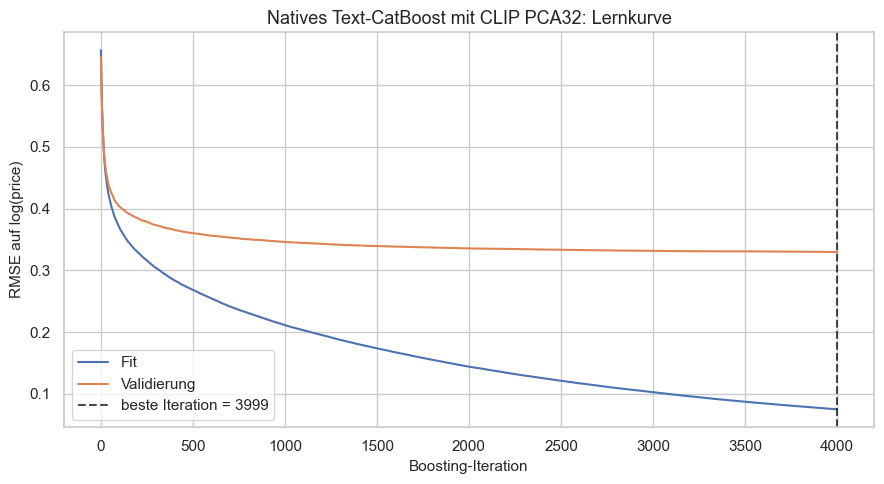

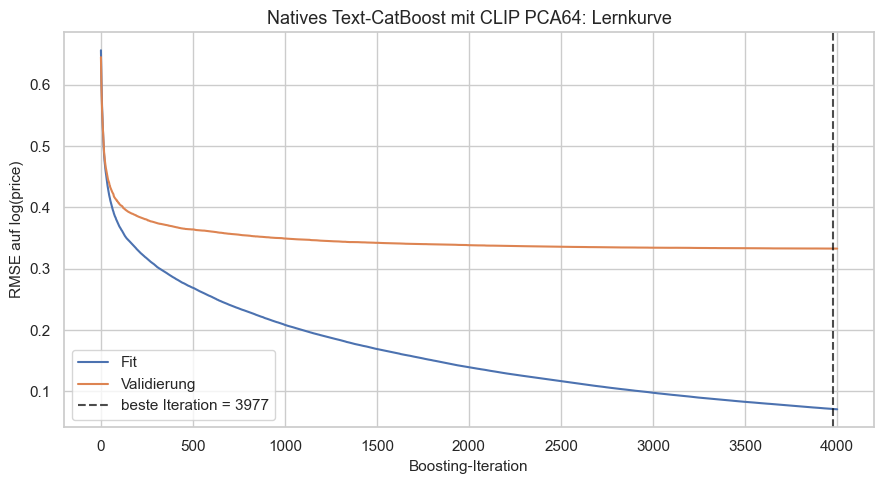

,Bildfeatures,Trainingszeit Minuten,RMSE log(price),MAE log(price),R² log(price),MAE price,Median AE price
Modell,,,,,,,
CatBoost ? native Textfeatures,keine,1.085021,0.323201,0.199607,0.767286,6094.641019,2154.465609
CatBoost - native text + CLIP PCA32,CLIP PCA32,1.121986,0.324758,0.202588,0.765038,6276.771075,2181.862467
CatBoost - native text + CLIP PCA64,CLIP PCA64,1.211519,0.325114,0.204737,0.764523,6367.559478,2234.585487


In [223]:
catboost_clip_pca_predictions = {}
catboost_clip_pca_metrics = {}

for n_components in [32, 64]:
    model = catboost_clip_pca_models[n_components]
    plot_catboost_learning_curve(
        model,
        f"Natives Text-CatBoost mit CLIP PCA{n_components}: Lernkurve",
    )
    prediction = model.predict(clip_pca_test_pools[n_components])
    metrics = evaluate_log_price_model(
        f"CatBoost - native text + CLIP PCA{n_components}",
        y_test,
        prediction,
    )
    catboost_clip_pca_predictions[n_components] = prediction
    catboost_clip_pca_metrics[n_components] = metrics

image_model_comparison = pd.DataFrame([
    {
        **catboost_native_text_metrics,
        "Bildfeatures": "keine",
        "Trainingszeit Minuten": catboost_native_text_training_seconds / 60,
    },
    *[
        {
            **catboost_clip_pca_metrics[n_components],
            "Bildfeatures": f"CLIP PCA{n_components}",
            "Trainingszeit Minuten": (
                catboost_clip_pca_training_seconds[n_components] / 60
            ),
        }
        for n_components in [32, 64]
    ],
]).set_index("Modell").sort_values("RMSE log(price)")

image_model_comparison[[
    "Bildfeatures",
    "Trainingszeit Minuten",
    "RMSE log(price)",
    "MAE log(price)",
    "R\u00b2 log(price)",
    "MAE price",
    "Median AE price",
]]

### 19.6 Beitrag der PCA-Bildfeatures

In [224]:
def grouped_multimodal_importance(model, n_components):
    importance = pd.DataFrame({
        "feature": model.feature_names_,
        "importance": model.get_feature_importance(
            type="PredictionValuesChange"
        ),
    })
    importance["feature_group"] = np.select(
        [
            importance["feature"].str.startswith(
                f"clip_pca_{n_components}_"
            ),
            importance["feature"].isin(catboost_text_cols),
        ],
        ["CLIP-PCA-Hauptbild", "Native CatBoost-Textfeatures"],
        default=importance["feature"],
    )
    grouped = (
        importance.groupby("feature_group", as_index=False)["importance"]
        .sum()
        .sort_values("importance", ascending=False)
    )
    grouped.insert(0, "Modell", f"PCA{n_components}")
    return grouped

multimodal_group_importance = pd.concat(
    [
        grouped_multimodal_importance(
            catboost_clip_pca_models[n_components], n_components
        )
        for n_components in [32, 64]
    ],
    ignore_index=True,
)
multimodal_group_importance.groupby("Modell", group_keys=False).head(20)

,Modell,feature_group,importance
0,PCA32,Native CatBoost-Textfeatures,37.716833
1,PCA32,accommodates,11.078566
2,PCA32,CLIP-PCA-Hauptbild,7.838962
3,PCA32,latitude,5.930934
4,PCA32,neighbourhood_cleansed,5.069705
5,PCA32,minimum_nights,4.011104
6,PCA32,longitude,3.294788
7,PCA32,bedrooms,3.181982
8,PCA32,bathroom_privacy,1.889524
9,PCA32,number_of_reviews_ltm,1.559299


### 19.7 Interpretation

Die 32er-Variante regularisiert die Bildinformation stärker; die 64er-Variante behält mehr visuelle Variation. Entscheidend ist nicht allein die erklärte PCA-Varianz, sondern der Fehler auf Validierung und dem unangetasteten Testdatensatz.

Verbessert keine der beiden Varianten das native Textmodell stabil, enthalten die Hauptbilder wahrscheinlich nur wenig zusätzliche Preisinformation oder die verbleibenden PCA-Richtungen sind für achsenparallele Baumsplits weiterhin ungeeignet. Weitere Dimensionszahlen sollten nur anhand von Trainings-/Validierungsdaten oder Cross-Validation gewählt werden, nicht anhand des Testsets.

### 19.8 Zwei semantische CLIP-Prompt-Sets

Es werden zwei Prompt-Sets ohne Mean-/Max-Aggregation verglichen:

1. **Altes Set:** alle 40 ursprünglichen Prompts,
2. **Neues Set:** die auf 15 Prompts reduzierte Auswahl.

Jeder Prompt bleibt ein separates Kosinus-Feature. Beide CatBoost-Modelle erhalten ansonsten exakt dieselben strukturierten und nativen Textfeatures. Die CLIP-Bildembeddings müssen dafür nicht neu berechnet werden.

In [235]:
old_prompts = [
    "a photo of a luxury apartment",
    "a photo of a modern apartment",
    "a photo of a stylish apartment interior",
    "a photo of a clean apartment",
    "a photo of a bright apartment",
    "a photo of a spacious apartment",
    "a photo of a cozy apartment",
    "a photo of a minimalist apartment interior",
    "a photo of a newly renovated apartment",
    "a photo of high quality interior design",
    "a photo of a small basic room",
    "a photo of a cheap basic accommodation",
    "a photo of an old apartment interior",
    "a photo of old furniture",
    "a photo of a dark room",
    "a photo of a cramped room",
    "a photo of a tiny apartment",
    "a photo of a cluttered room",
    "a photo of a simple guest room",
    "a photo of a compact Tokyo apartment",
    "a photo of a balcony",
    "a photo of an apartment with a balcony",
    "a photo of a terrace",
    "a photo of a city view from an apartment",
    "a photo of a skyline view from an apartment",
    "a photo of Tokyo city view",
    "a photo of Tokyo city lights at night",
    "a photo of a high-rise apartment in Tokyo",
    "a photo of a modern kitchen",
    "a photo of a small kitchen",
    "a photo of a modern bathroom",
    "a photo of an old bathroom",
    "a photo of a bathtub",
    "a photo of a washing machine in an apartment",
    "a photo of a double bed",
    "a photo of a sofa bed",
    "a photo of a bunk bed room",
    "a photo of a tatami room",
    "a photo of a Japanese style room",
    "a photo of a futon on tatami mats",
]
new_prompts = [
    "a photo of a stylish apartment interior",
    "a photo of a cheap basic accommodation",
    "a photo of a modern apartment",
    "a photo of old furniture",
    "a photo of a terrace",
    "a photo of a double bed",
    "a photo of a washing machine in an apartment",
    "a photo of a Japanese style room",
    "a photo of a tatami room",
    "a photo of a cluttered room",
    "a photo of a small basic room",
    "a photo of an old bathroom",
    "a photo with text on it",
    "a photo of multiple pictures in one image",
    "a photo of a collage",
]

prompt_sets = {
    "old_40": old_prompts,
    "new_15": new_prompts,
}
prompt_set_labels = {
    "old_40": "altes Set (40 Prompts)",
    "new_15": "neues Set (15 Prompts)",
}

# Identische Texte werden nur einmal durch den CLIP-Textencoder geschickt.
all_unique_prompts = list(dict.fromkeys(old_prompts + new_prompts))
prompt_clip_model, _ = clip.load(CLIP_MODEL_NAME, device=device, jit=False)
prompt_clip_model.eval()
prompt_tokens = clip.tokenize(all_unique_prompts).to(device)
with torch.inference_mode(), torch.autocast(
    device_type="cuda", dtype=torch.float16
):
    unique_prompt_embeddings = prompt_clip_model.encode_text(prompt_tokens)
    unique_prompt_embeddings = unique_prompt_embeddings / unique_prompt_embeddings.norm(
        dim=1, keepdim=True
    ).clamp_min(1e-12)
unique_prompt_embeddings = unique_prompt_embeddings.float().cpu().numpy()
del prompt_clip_model, prompt_tokens
torch.cuda.empty_cache()

prompt_to_embedding = dict(zip(all_unique_prompts, unique_prompt_embeddings))
clip_prompt_feature_sets = {}
prompt_feature_maps = {}

for set_name, prompts in prompt_sets.items():
    text_embeddings = np.vstack([
        prompt_to_embedding[prompt] for prompt in prompts
    ]).astype(np.float32)
    scores = (listing_clip_matrix @ text_embeddings.T).astype(np.float32)
    scores[clip_image_available == 0] = 0.0
    feature_cols = [
        f"clip_prompt_{set_name}_{number:02d}"
        for number in range(len(prompts))
    ]
    feature_data = pd.DataFrame(
        scores,
        index=full_data.index,
        columns=feature_cols,
    )
    feature_data["clip_image_available"] = clip_image_available
    clip_prompt_feature_sets[set_name] = feature_data
    prompt_feature_maps[set_name] = pd.DataFrame({
        "feature": feature_cols,
        "prompt": prompts,
    })
    print(f"{prompt_set_labels[set_name]}: {len(feature_cols)} Features")

altes Set (40 Prompts): 40 Features
neues Set (15 Prompts): 15 Features


### 19.9 Beide Prompt-Modelle mit längerem Training

Die bisherige Obergrenze von 4.000 Bäumen wird für beide Prompt-Modelle auf **12.000** erhöht. Gleichzeitig sinkt die Lernrate von 0,10 auf **0,05**, damit die zusätzlichen Iterationen kleinere Schritte machen. Early Stopping wartet **500** Iterationen ohne Verbesserung ab.

Damit unterscheiden sich die beiden Modelle ausschließlich durch die 40 beziehungsweise 15 Prompt-Scores.

In [238]:
prompt_native_fit = X_catboost_text_train.iloc[boost_fit_idx]
prompt_native_validation = X_catboost_text_train.iloc[boost_valid_idx]
prompt_native_test = X_catboost_text_test

PROMPT_MAX_ITERATIONS = 40_000
PROMPT_LEARNING_RATE = 0.05
PROMPT_EARLY_STOPPING_ROUNDS = 500

catboost_prompt_models = {}
catboost_prompt_training_seconds = {}
prompt_test_pools = {}

for set_name in ["old_40", "new_15"]:
    prompt_features = clip_prompt_feature_sets[set_name]
    X_prompt_fit = pd.concat([
        prompt_native_fit,
        prompt_features.loc[prompt_native_fit.index],
    ], axis=1)
    X_prompt_validation = pd.concat([
        prompt_native_validation,
        prompt_features.loc[prompt_native_validation.index],
    ], axis=1)
    X_prompt_test = pd.concat([
        prompt_native_test,
        prompt_features.loc[prompt_native_test.index],
    ], axis=1)

    prompt_fit_pool = Pool(
        data=X_prompt_fit,
        label=y_train.iloc[boost_fit_idx],
        cat_features=catboost_categorical_cols,
        text_features=catboost_text_cols,
        feature_names=list(X_prompt_fit.columns),
    )
    prompt_validation_pool = Pool(
        data=X_prompt_validation,
        label=y_train.iloc[boost_valid_idx],
        cat_features=catboost_categorical_cols,
        text_features=catboost_text_cols,
        feature_names=list(X_prompt_validation.columns),
    )
    prompt_test_pool = Pool(
        data=X_prompt_test,
        label=y_test,
        cat_features=catboost_categorical_cols,
        text_features=catboost_text_cols,
        feature_names=list(X_prompt_test.columns),
    )

    prompt_params = {
        **CATBOOST_TEXT_GPU_PARAMS,
        "iterations": PROMPT_MAX_ITERATIONS,
        "learning_rate": PROMPT_LEARNING_RATE,
        "border_count": 32,
        "feature_calcers": ["BoW:top_tokens_count=4000"],
    }
    model = CatBoostRegressor(**prompt_params)
    start = perf_counter()
    model.fit(
        prompt_fit_pool,
        eval_set=prompt_validation_pool,
        use_best_model=True,
        early_stopping_rounds=PROMPT_EARLY_STOPPING_ROUNDS,
        verbose=500,
    )
    elapsed = perf_counter() - start
    print(f"{prompt_set_labels[set_name]}: {elapsed / 60:.2f} Minuten")
    print(f"Beste Iteration: {model.get_best_iteration() + 1}")
    print(f"Gespeicherte Baeume: {model.tree_count_}")
    print(f"Validierungs-RMSE: {model.get_best_score()['validation']['RMSE']:.6f}")

    catboost_prompt_models[set_name] = model
    catboost_prompt_training_seconds[set_name] = elapsed
    prompt_test_pools[set_name] = prompt_test_pool

0:	learn: 0.6680640	test: 0.6562851	best: 0.6562851 (0)	total: 87.6ms	remaining: 58m 24s
500:	learn: 0.3154056	test: 0.3774783	best: 0.3774565 (499)	total: 11.2s	remaining: 14m 42s
1000:	learn: 0.2691888	test: 0.3612586	best: 0.3612586 (1000)	total: 23.8s	remaining: 15m 26s
1500:	learn: 0.2373958	test: 0.3529417	best: 0.3529417 (1500)	total: 33.9s	remaining: 14m 30s
2000:	learn: 0.2127840	test: 0.3474350	best: 0.3474350 (2000)	total: 44.5s	remaining: 14m 5s
2500:	learn: 0.1923914	test: 0.3434882	best: 0.3434882 (2500)	total: 57.3s	remaining: 14m 19s
3000:	learn: 0.1745564	test: 0.3405840	best: 0.3405790 (2999)	total: 1m 7s	remaining: 13m 58s
3500:	learn: 0.1596826	test: 0.3382281	best: 0.3382281 (3500)	total: 1m 19s	remaining: 13m 53s
4000:	learn: 0.1465594	test: 0.3364426	best: 0.3364426 (4000)	total: 1m 32s	remaining: 13m 54s
4500:	learn: 0.1344643	test: 0.3348550	best: 0.3348550 (4500)	total: 1m 53s	remaining: 14m 55s
5000:	learn: 0.1235189	test: 0.3339407	best: 0.3339312 (4999)	tot

### 19.10 Beide Prompt-Modelle evaluieren

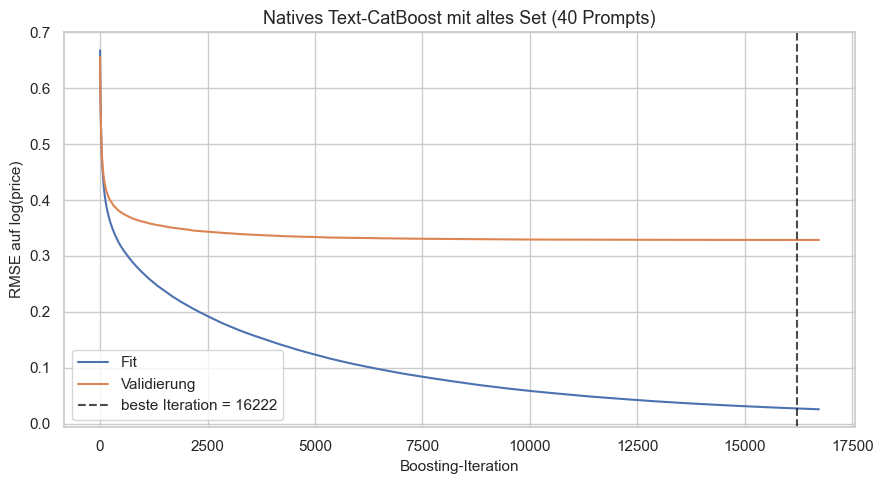

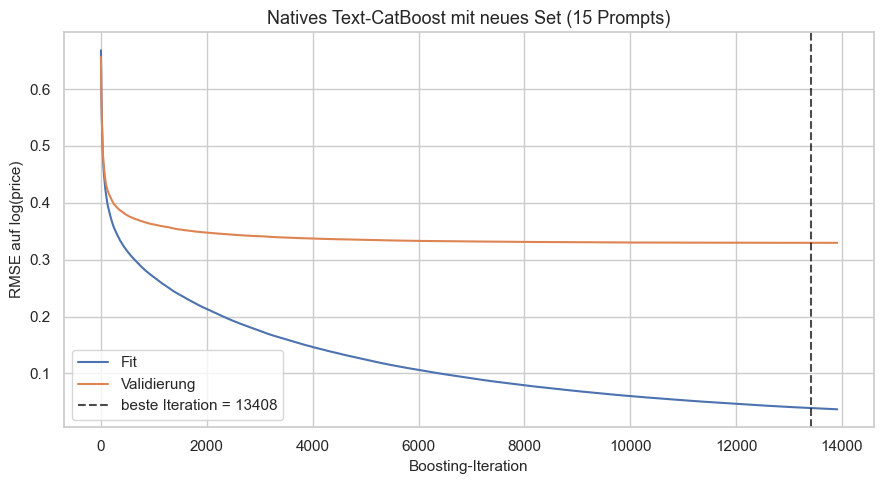

,Prompt-Set,Max. Iterationen,Lernrate,Trainingszeit Minuten,RMSE log(price),MAE log(price),R² log(price),MAE price,Median AE price
Modell,,,,,,,,,
CatBoost - native text + neues Set (15 Prompts),neues Set (15 Prompts),40000,0.05,7.787536,0.320258,0.196656,0.771504,6107.996413,2103.489132
CatBoost - native text + altes Set (40 Prompts),altes Set (40 Prompts),40000,0.05,9.203281,0.320664,0.196879,0.770925,6087.311000,2076.540346
CatBoost ? native Textfeatures,keine Bildfeatures,4000,0.10,1.085021,0.323201,0.199607,0.767286,6094.641019,2154.465609


In [239]:
catboost_prompt_predictions = {}
catboost_prompt_metrics = {}

for set_name in ["old_40", "new_15"]:
    model = catboost_prompt_models[set_name]
    plot_catboost_learning_curve(
        model,
        f"Natives Text-CatBoost mit {prompt_set_labels[set_name]}",
    )
    prediction = model.predict(prompt_test_pools[set_name])
    metrics = evaluate_log_price_model(
        f"CatBoost - native text + {prompt_set_labels[set_name]}",
        y_test,
        prediction,
    )
    catboost_prompt_predictions[set_name] = prediction
    catboost_prompt_metrics[set_name] = metrics

prompt_model_comparison = pd.DataFrame([
    {
        **catboost_native_text_metrics,
        "Prompt-Set": "keine Bildfeatures",
        "Max. Iterationen": 4_000,
        "Lernrate": 0.10,
        "Trainingszeit Minuten": catboost_native_text_training_seconds / 60,
    },
    *[
        {
            **catboost_prompt_metrics[set_name],
            "Prompt-Set": prompt_set_labels[set_name],
            "Max. Iterationen": PROMPT_MAX_ITERATIONS,
            "Lernrate": PROMPT_LEARNING_RATE,
            "Trainingszeit Minuten": catboost_prompt_training_seconds[set_name] / 60,
        }
        for set_name in ["old_40", "new_15"]
    ],
]).set_index("Modell").sort_values("RMSE log(price)")

prompt_model_comparison[[
    "Prompt-Set",
    "Max. Iterationen",
    "Lernrate",
    "Trainingszeit Minuten",
    "RMSE log(price)",
    "MAE log(price)",
    "R\u00b2 log(price)",
    "MAE price",
    "Median AE price",
]]

### 19.11 Wichtigkeit der Prompts in beiden Modellen

,Prompt-Set,feature,prompt,importance
0,altes Set (40 Prompts),clip_prompt_old_40_02,a photo of a stylish apartment interior,0.946727
1,altes Set (40 Prompts),clip_prompt_old_40_11,a photo of a cheap basic accommodation,0.497516
2,altes Set (40 Prompts),clip_prompt_old_40_34,a photo of a double bed,0.332638
3,altes Set (40 Prompts),clip_prompt_old_40_22,a photo of a terrace,0.301195
4,altes Set (40 Prompts),clip_prompt_old_40_37,a photo of a tatami room,0.297076
5,altes Set (40 Prompts),clip_prompt_old_40_33,a photo of a washing machine in an apartment,0.278218
6,altes Set (40 Prompts),clip_prompt_old_40_13,a photo of old furniture,0.246705
7,altes Set (40 Prompts),clip_prompt_old_40_32,a photo of a bathtub,0.203750
8,altes Set (40 Prompts),clip_prompt_old_40_10,a photo of a small basic room,0.180413
9,altes Set (40 Prompts),clip_prompt_old_40_31,a photo of an old bathroom,0.180046


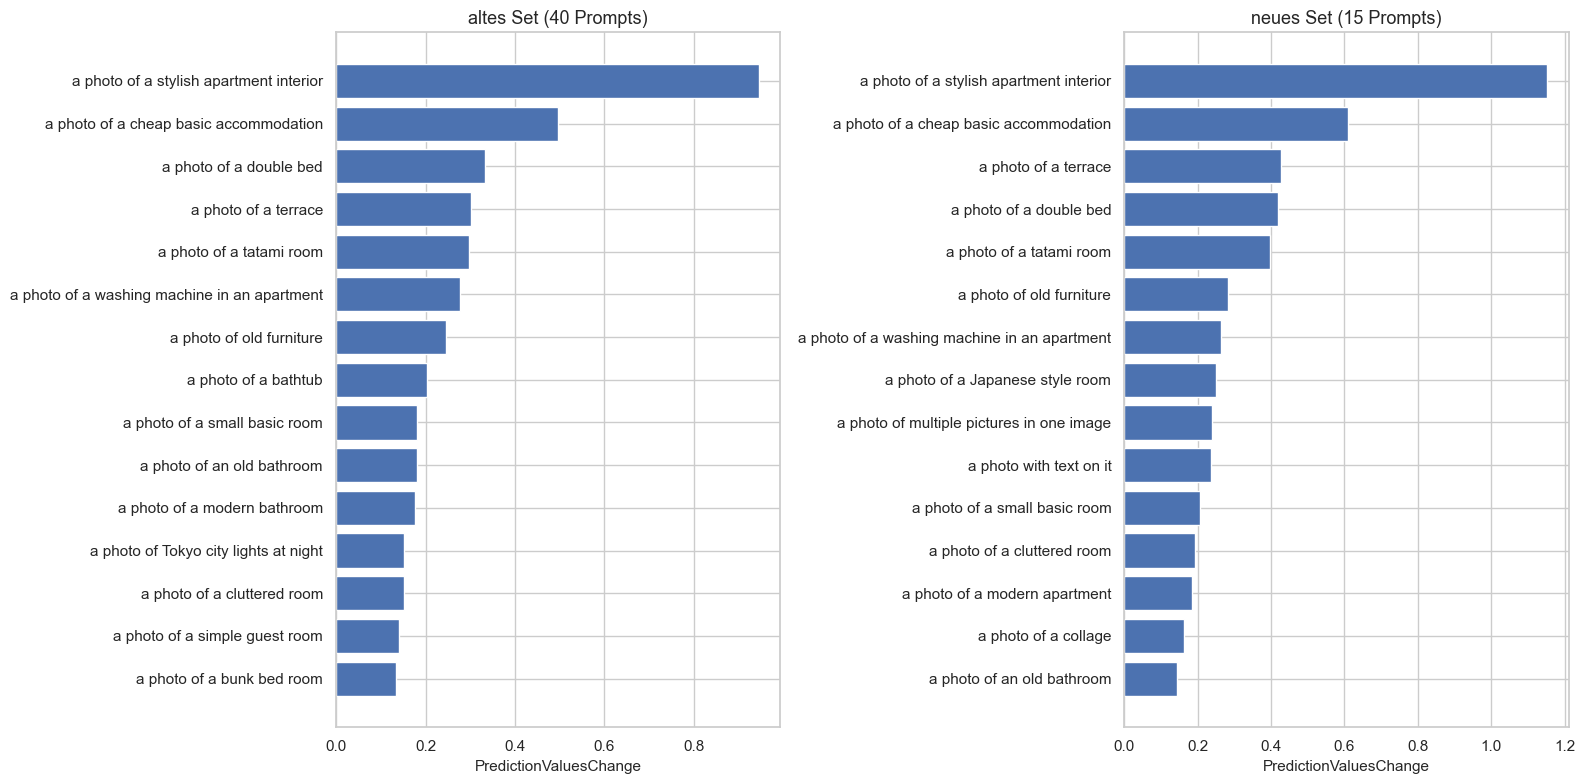

In [240]:
prompt_importance_tables = []
for set_name in ["old_40", "new_15"]:
    model = catboost_prompt_models[set_name]
    model_importance = pd.DataFrame({
        "feature": model.feature_names_,
        "importance": model.get_feature_importance(
            type="PredictionValuesChange"
        ),
    })
    prompt_importance = (
        prompt_feature_maps[set_name]
        .merge(model_importance, on="feature", how="left")
        .fillna({"importance": 0.0})
        .sort_values("importance", ascending=False)
    )
    prompt_importance.insert(0, "Prompt-Set", prompt_set_labels[set_name])
    prompt_importance_tables.append(prompt_importance)

prompt_importance_comparison = pd.concat(
    prompt_importance_tables, ignore_index=True
)
display(
    prompt_importance_comparison.groupby("Prompt-Set", group_keys=False).head(20)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
for ax, set_name in zip(axes, ["old_40", "new_15"]):
    subset = (
        prompt_importance_comparison.loc[
            prompt_importance_comparison["Prompt-Set"] == prompt_set_labels[set_name]
        ]
        .head(15)
        .sort_values("importance")
    )
    ax.barh(subset["prompt"], subset["importance"])
    ax.set(
        title=prompt_set_labels[set_name],
        xlabel="PredictionValuesChange",
    )
plt.tight_layout()
plt.show()

### 19.12 Interpretation des Prompt-Vergleichs

Das alte Set bietet mehr visuelle Konzepte, kann aber durch redundante oder schwache Prompts stärker overfitten. Das neue Set ist kompakter und enthält zusätzlich explizite Hinweise auf Text, Mehrfachbilder und Collagen.

Maßgeblich sind die Validierungs- und Testfehler sowie die tatsächlich beste Iteration. Erreichen beide Modelle erneut die Grenze von 12.000 Bäumen, sollte in einem weiteren Schritt eher die Lernrate reduziert oder die maximale Iterationszahl nochmals erhöht werden. Stoppen sie deutlich früher, war die neue Grenze ausreichend.